# Notebook 02 — Análises Exploratórias e Cruzamento CESOP × TSE

**Objetivo:** explorar visualmente as bases tratadas no notebook 01 e iniciar o cruzamento entre a percepção declarada (CESOP) e o comportamento eleitoral observado (TSE 2022).

**Bases consumidas:**
- `cesop_clean.parquet` — 2.000 respondentes com perguntas recodificadas
- `tse_clean.parquet` — linhas-detalhe (município × perfil) com taxas
- `tse_uf.parquet` — agregado por UF
- `tse_perfil.parquet` — agregado por perfil demográfico nacional

**Estrutura:**
1. Setup
2. Perfil sociodemográfico CESOP
3. Lembrança do voto em 2022
4. Prioridades políticas
5. Combate às fake news
6. Vontade de participar da política local
7. Panorama eleitoral TSE 2022
8. **Cruzamento CESOP × TSE**
8. Síntese e discussão


## 0. Setup


In [1]:
# Imports e configuração estética.
# A configuração centralizada do seaborn/matplotlib evita repetir parâmetros nos gráficos.
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Paletas reutilizadas ao longo do notebook (consistência visual).
# Paleta com uma cor DISTINTA por região.
PALETA_REGIAO = {
    "Norte": "#1b9e77",
    "Nordeste": "#d95f02",
    "Centro-Oeste": "#7570b3",
    "Sudeste": "#e7298a",
    "Sul": "#66a61e",
}
CORES_VONTADE = ["#1a6ea8", "#6baed6", "#e0e0e0"]  # muita, alguma, nenhuma
COR_PRINCIPAL = "#3b5998"
COR_SECUNDARIA = "#e8a09a"


In [2]:
# Detecção de ambiente (Colab x local) e leitura das bases tratadas no notebook 01.
# Por quê: garante que o notebook rode "100% no Colab" — no Colab montamos o Drive;
# localmente usamos a raiz do repositório a partir da pasta notebooks/.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/Projeto_EDA_Democracia")
else:
    PROJECT_ROOT = Path("..").resolve()

PATH_PROCESSED = PROJECT_ROOT / "data" / "processed"
PATH_FIGURAS = PROJECT_ROOT / "reports" / "imagens"
PATH_FIGURAS.mkdir(parents=True, exist_ok=True)

# As quatro bases foram preparadas e salvas em Parquet pelo notebook 01.
df_cesop = pd.read_parquet(PATH_PROCESSED / "cesop_clean.parquet")
df_tse = pd.read_parquet(PATH_PROCESSED / "tse_clean.parquet")
df_tse_uf = pd.read_parquet(PATH_PROCESSED / "tse_uf.parquet")
df_tse_perfil = pd.read_parquet(PATH_PROCESSED / "tse_perfil.parquet")

print(f"Ambiente Colab? {IN_COLAB}")
print(f"CESOP       : {df_cesop.shape}")
print(f"TSE detalhe : {df_tse.shape}")
print(f"TSE por UF  : {df_tse_uf.shape}")
print(f"TSE perfil  : {df_tse_perfil.shape}")

Ambiente Colab? False
CESOP       : (2000, 30)
TSE detalhe : (8785738, 13)
TSE por UF  : (28, 7)
TSE perfil  : (498, 9)


## 1. Perfil sociodemográfico — CESOP

Quem é a amostra de 2.000 respondentes? Os painéis a seguir apresentam, em percentual, a composição da amostra em três dimensões: demográfica, territorial e socioeconômica.

**Perfil demográfico**

A primeira etapa da análise apresenta a composição demográfica da amostra, considerando sexo, faixa etária, escolaridade e raça/cor dos respondentes.

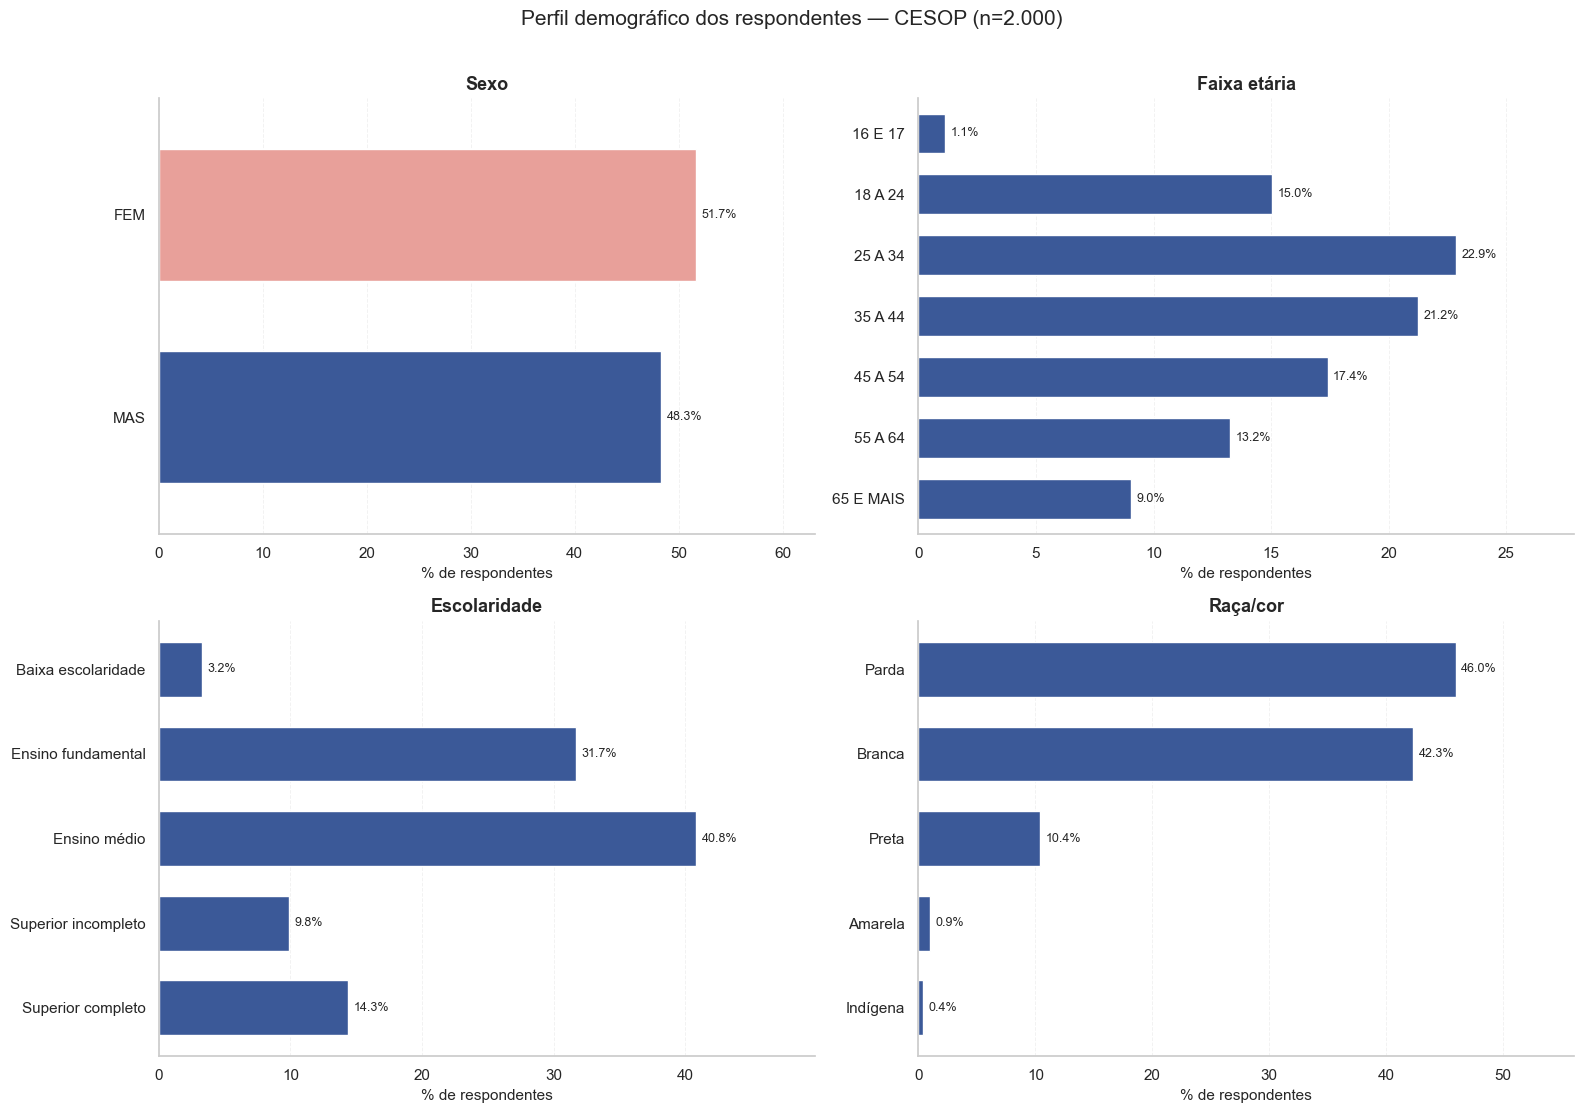

In [3]:
# Helper reutilizado pelas três figuras do perfil sociodemográfico.
# ordered_index define a ordem de cima para baixo; color_map permite cor por categoria.
def _barh_pct(series, ax, color, title, ordered_index=None, color_map=None, xlim=None):
    """Plota barras horizontais em % com rótulos e estilo limpo."""
    pct = series.value_counts(normalize=True) * 100
    if ordered_index is not None:
        pct = pct.reindex(ordered_index).dropna()
        invert = True   # primeira categoria no topo
    else:
        pct = pct.sort_values()
        invert = False  # maior frequência no topo

    cores = [color_map.get(str(c), color) for c in pct.index] if color_map else color

    pct.plot.barh(ax=ax, color=cores, width=0.65, edgecolor="white")
    if invert:
        ax.invert_yaxis()

    ax.set_title(title)
    ax.set_xlabel("% de respondentes")
    ax.set_ylabel("")
    ax.set_xlim(xlim if xlim else (0, min(100, pct.max() * 1.22)))
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", alpha=0.25, linestyle="--", linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=4, fontsize=9)

    
# Ordens semânticas explícitas para cada variável.
ORDEM_FX_ID = ["16 E 17", "18 A 24", "25 A 34", "35 A 44", "45 A 54", "55 A 64", "65 E MAIS"]

ORDEM_ESCOL=['Baixa escolaridade', 'Ensino fundamental', 'Ensino médio', 'Superior incompleto', 'Superior completo' ]

ORDEM_RENDA=['Sem rendimento', 'Até 1 SM', '1 a 5 SM', 'Acima de 5 SM', 'Acima de 20 SM']

# Rosa para feminino, azul para masculino.
CORES_SEXO = {
    "MAS": COR_PRINCIPAL,
    "FEM": COR_SECUNDARIA,
}


# ── Figura 1: Perfil demográfico ──────────────────────────────────────────────
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 11))
fig1.suptitle("Perfil demográfico dos respondentes — CESOP (n=2.000)", fontsize=15, y=1.01)

_barh_pct(df_cesop["SEXO"], axes1[0, 0], COR_PRINCIPAL, "Sexo", color_map=CORES_SEXO)

_barh_pct(df_cesop["FX_ID"], axes1[0, 1], COR_PRINCIPAL, "Faixa etária",
          ordered_index=ORDEM_FX_ID)

_barh_pct(df_cesop["ESCOL_GRUPO"], axes1[1, 0], COR_PRINCIPAL, "Escolaridade",
          ordered_index=ORDEM_ESCOL)

_barh_pct(df_cesop["RACA"], axes1[1, 1], COR_PRINCIPAL, "Raça/cor")

# _barh_pct(df_cesop["RENDA_PESSOAL"], axes1[2, 0], COR_PRINCIPAL, "Renda Pessoal (Salários Mínimos)",
#           ordered_index=ORDEM_RENDA)

# _barh_pct(df_cesop["RENDA_FAMILIAR"], axes1[2, 1], COR_PRINCIPAL, "Renda Familiar (Salários Mínimos)",
#           ordered_index=ORDEM_RENDA)

plt.tight_layout()
plt.savefig(PATH_FIGURAS / "01a_perfil_demografico.png", dpi=120, bbox_inches="tight")
plt.show()

**Perfil territorial**

Em seguida, observa-se a distribuição regional dos entrevistados.

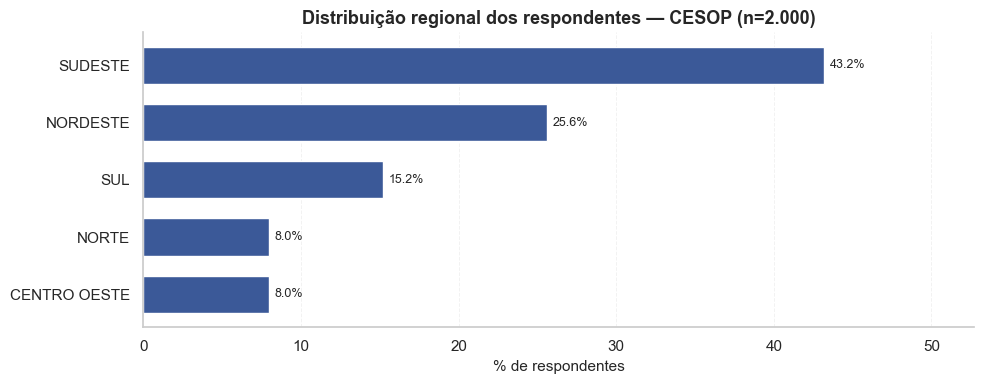

In [4]:
# ── Figura 2: Distribuição regional ───────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 4))

_barh_pct(df_cesop["REGIAO"], ax2, COR_PRINCIPAL,
          "Distribuição regional dos respondentes — CESOP (n=2.000)")

plt.tight_layout()
plt.savefig(PATH_FIGURAS / "01b_perfil_territorial.png", dpi=120, bbox_inches="tight")
plt.show()

**Perfil socioeconômico**

Por fim, as variáveis de renda pessoal e familiar permitem caracterizar a condição econômica individual e domiciliar dos respondentes.

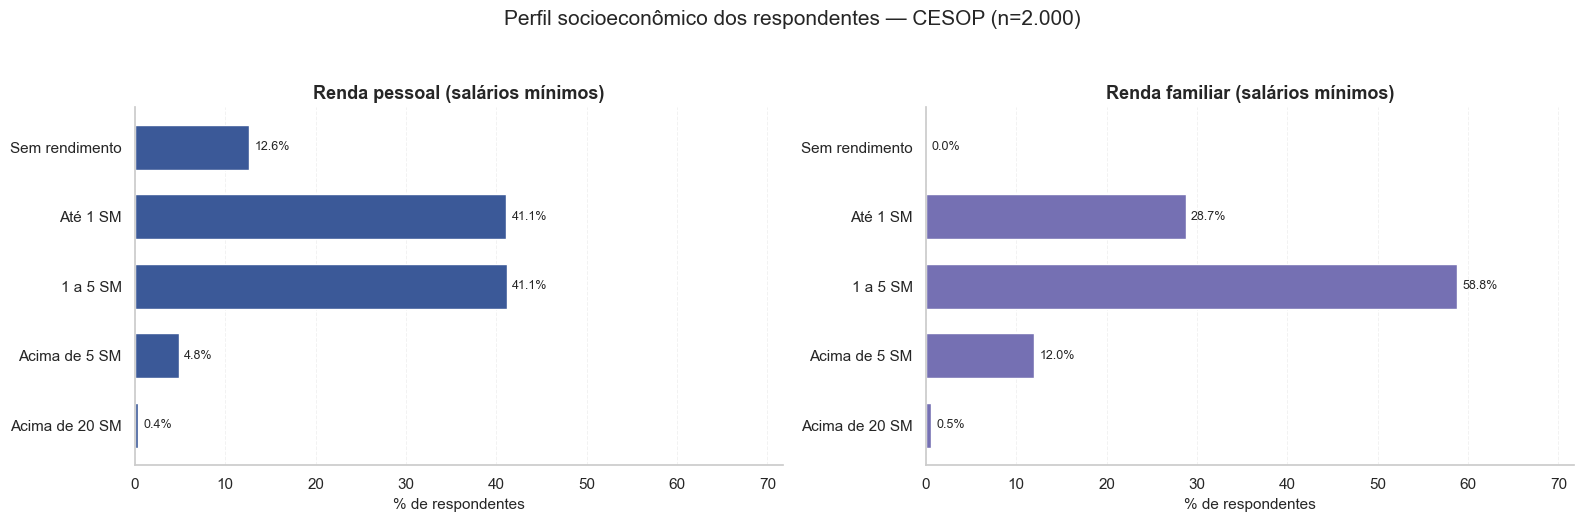

In [5]:
# ── Figura 3: Perfil socioeconômico ───────────────────────────────────────────
# Escala X compartilhada entre renda pessoal e familiar para comparação justa.
max_x_renda = max(
    (df_cesop["RENDA_PESSOAL"].value_counts(normalize=True) * 100).max(),
    (df_cesop["RENDA_FAMILIAR"].value_counts(normalize=True) * 100).max(),
)
xlim_renda = (0, min(100, max_x_renda * 1.22))

fig3, axes3 = plt.subplots(1, 2, figsize=(16, 5))
fig3.suptitle("Perfil socioeconômico dos respondentes — CESOP (n=2.000)", fontsize=15, y=1.04)

_barh_pct(df_cesop["RENDA_PESSOAL"], axes3[0], COR_PRINCIPAL,
          "Renda pessoal (salários mínimos)", ordered_index=ORDEM_RENDA, xlim=xlim_renda)
_barh_pct(df_cesop["RENDA_FAMILIAR"], axes3[1], "#7570b3",
          "Renda familiar (salários mínimos)", ordered_index=ORDEM_RENDA, xlim=xlim_renda)

plt.tight_layout()
plt.savefig(PATH_FIGURAS / "01c_perfil_socioeconomico.png", dpi=120, bbox_inches="tight")
plt.show()

**O que o perfil revela.** A amostra (n=2.000) é equilibrada por sexo (51,7% F, 48,3% M) e concentra-se nos adultos de **25–44 anos** (44,1% somando as duas faixas); em raça/cor, predominam pardos (46,0%) e brancos (42,3%). Em **escolaridade**, o ensino médio domina (40,8%) e há **poucos respondentes de baixa escolaridade (3,2%)**. Esse último ponto é decisivo: como mostra a seção 7.2, a amostra **sub-representa os menos escolarizados** frente ao eleitorado real — algo a ter em mente ao ler todos os indicadores de engajamento a seguir.

## 2. Lembrança do voto em 2022

Comparamos quanto os respondentes se lembram do voto para os três cargos perguntados (deputado estadual, federal e senador), e como a lembrança varia por escolaridade e idade.


### Visão geral por cargo

Começamos comparando a lembrança de voto entre os **três cargos** (deputado estadual, deputado federal e senador). Em seguida, detalhamos cada cargo por recortes sociodemográficos (escolaridade, idade, sexo, raça/cor, renda e região), sempre com barras empilhadas 100% — o que permite comparar a *composição* das respostas entre grupos de tamanhos diferentes.

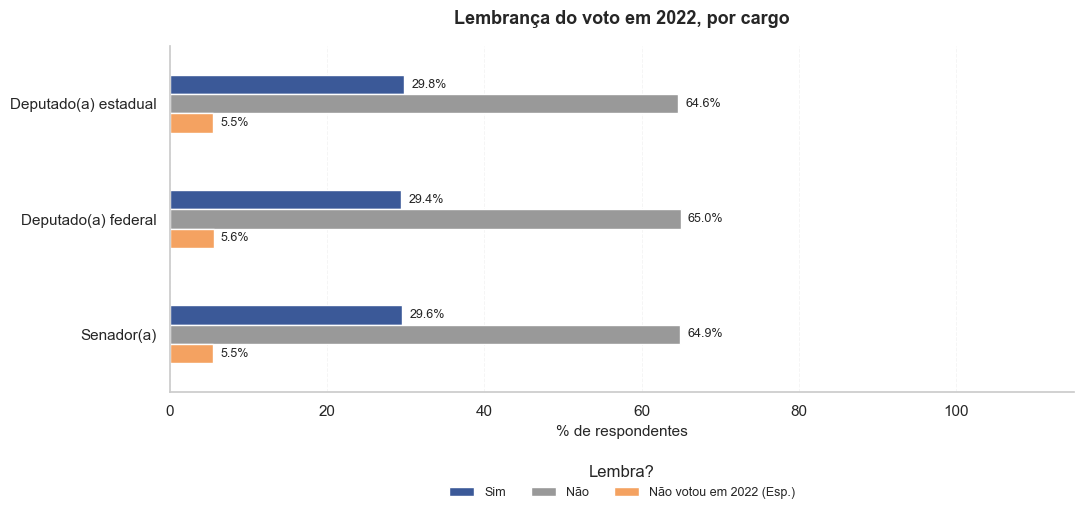

In [6]:
# === Constantes e helpers compartilhados pelos três gráficos de lembrança de voto ===

COR_SIM       = COR_PRINCIPAL   # azul
COR_NAO       = "#999999"        # cinza médio
COR_NAO_VOTOU = "#f4a261"        # laranja suave

PALETA_LEMBRANCA   = {"Sim": COR_SIM, "Não": COR_NAO, "Não votou": COR_NAO_VOTOU}
CORES_TEXTO_LEMB   = {"Sim": "white", "Não": "white", "Não votou": "#333333"}
ORDEM_LEMBRANCA    = ["Sim", "Não", "Não votou"]

ORDEM_CARGOS_LEMB = ["Deputado(a) estadual", "Deputado(a) federal", "Senador(a)"]
ORDEM_FX_LEMB     = ["16 E 17", "18 A 24", "25 A 34", "35 A 44",
                      "45 A 54", "55 A 64", "65 E MAIS"]
ORDEM_ESCOL_LEMB  = ['Baixa escolaridade', 'Ensino fundamental', 'Ensino médio', 'Superior incompleto', 'Superior completo' ]
LIMIAR_ROTULO_LEMB = 5.0  # segmentos < 5% não recebem rótulo


def _cols_lemb(df):
    """Reordena colunas: Sim → Não → Não votou → extras. Retorna df e lista de colunas."""
    fixas  = [c for c in ORDEM_LEMBRANCA if c in df.columns]
    extras = [c for c in df.columns if c not in ORDEM_LEMBRANCA]
    cols   = fixas + extras
    return df[cols], cols


def _rotulos_empilhados(ax, colunas, fmt="%.0f%%", limiar=LIMIAR_ROTULO_LEMB):
    """Rótulos de % no centro de cada segmento; omite segmentos abaixo do limiar."""
    for i, container in enumerate(ax.containers):
        cat = colunas[i]
        cor_txt = CORES_TEXTO_LEMB.get(str(cat), "white")
        for bar in container:
            val = bar.get_width()
            if pd.isna(val) or val < limiar:
                continue
            x = bar.get_x() + val / 2
            y = bar.get_y() + bar.get_height() / 2
            ax.text(x, y, fmt % val, ha="center", va="center",
                    fontsize=9, color=cor_txt, fontweight="bold")


def _estilo_lemb(ax, title, xlabel, xlim=(0, 100)):
    """Aplica estilo padrão compartilhado pelos três gráficos."""
    ax.set_title(title, pad=16)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.set_xlim(xlim)
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def _legenda_lemb(ax, colunas):
    """Legenda padronizada abaixo do gráfico, horizontal, sem borda."""
    ax.legend(
        title="Lembra?", loc="upper center", bbox_to_anchor=(0.5, -0.18),
        ncol=len(colunas), frameon=False, fontsize=9,
    )


# === Gráfico 1: Lembrança por cargo ===
cargos_map = {
    "P_01A": "Deputado(a) estadual",
    "P_01B": "Deputado(a) federal",
    "P_01C": "Senador(a)",
}

df_lembranca_raw = pd.DataFrame({
    label: df_cesop[col].value_counts(normalize=True) * 100
    for col, label in cargos_map.items()
}).T.fillna(0)

df_lembranca, colunas_cargo = _cols_lemb(df_lembranca_raw)
df_lembranca = df_lembranca.reindex(
    [c for c in ORDEM_CARGOS_LEMB if c in df_lembranca.index]
)
cores_cargo = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_cargo]

fig, ax = plt.subplots(figsize=(11, 5))
df_lembranca[colunas_cargo].plot.barh(ax=ax, color=cores_cargo, width=0.5)
ax.invert_yaxis()
_estilo_lemb(ax, "Lembrança do voto em 2022, por cargo", "% de respondentes", xlim=(0, 115))

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=5, fontsize=9)

_legenda_lemb(ax, colunas_cargo)
plt.tight_layout()
fig.subplots_adjust(bottom=0.2)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_por_cargo.png", dpi=120, bbox_inches="tight")
plt.show()

# print("Categorias encontradas:", colunas_cargo)

#### Lembrança do voto — Deputado(a) estadual

Detalhamos a lembrança do voto para deputado estadual pelos recortes sociodemográficos (escolaridade, idade, sexo, raça/cor, renda e região).

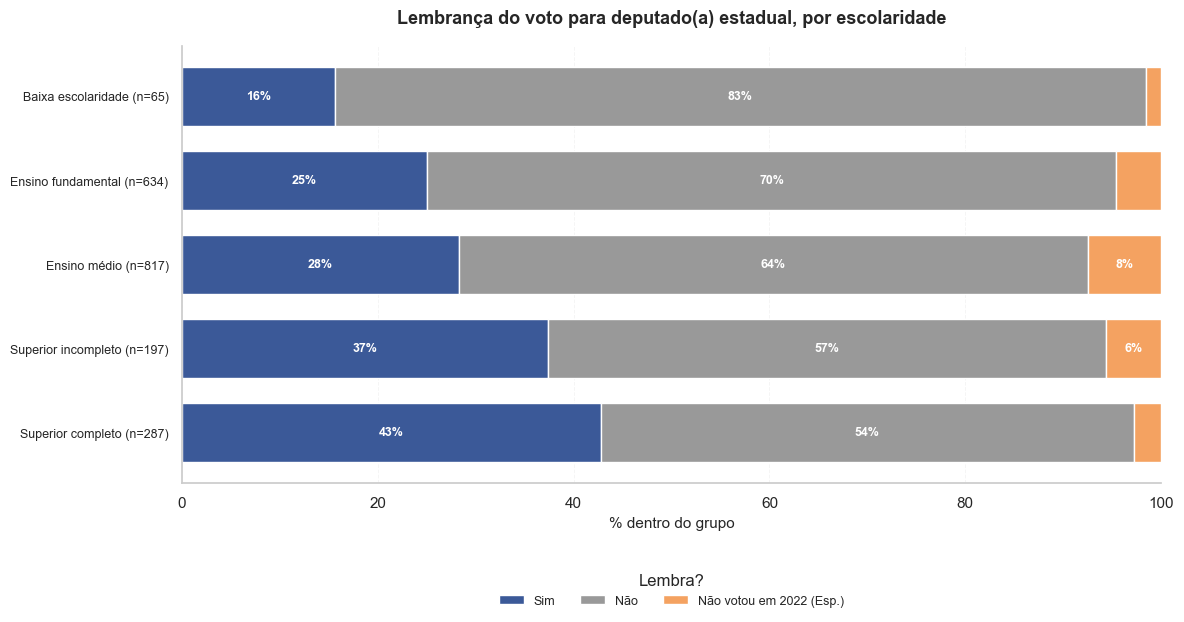

In [7]:
# n= calculado antes de crosstab para refletir o total de respondentes por grupo.
counts_escol = df_cesop["ESCOL_GRUPO"].value_counts()

ct_escol_raw = pd.crosstab(df_cesop["ESCOL_GRUPO"], df_cesop["P_01A"], normalize="index") * 100
ct_escol, colunas_e = _cols_lemb(ct_escol_raw)
ct_escol = ct_escol.reindex([c for c in ORDEM_ESCOL_LEMB if c in ct_escol.index])

cores_e = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_e]

labels_y_escol = [
    f"{cat} (n={int(counts_escol.get(cat, 0)):,})"
    for cat in ct_escol.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_escol[colunas_e].plot.barh(stacked=True, ax=ax, color=cores_e, width=0.7)

# Define ticks explicitamente antes de invert para garantir correspondência correta.
ax.set_yticks(range(len(ct_escol.index)))
ax.set_yticklabels(labels_y_escol, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) estadual, por escolaridade",
             "% dentro do grupo")
_rotulos_empilhados(ax, colunas_e)
_legenda_lemb(ax, colunas_e)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_estadual_escolaridade.png", dpi=120, bbox_inches="tight")
plt.show()

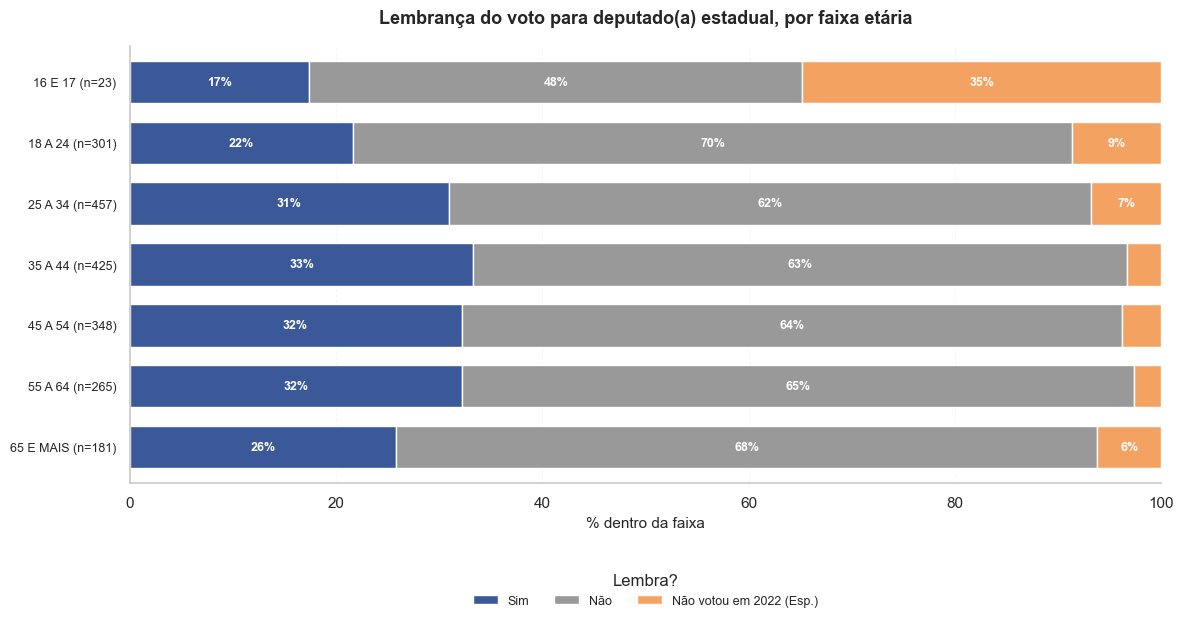

In [8]:
# Distribuição da lembrança de voto DENTRO de cada faixa etária: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada faixa etária.
counts_fx = df_cesop["FX_ID"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["FX_ID"], df_cesop["P_01A"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) estadual, por faixa etária",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_estadual_fx_idade.png", dpi=120, bbox_inches="tight")
plt.show()

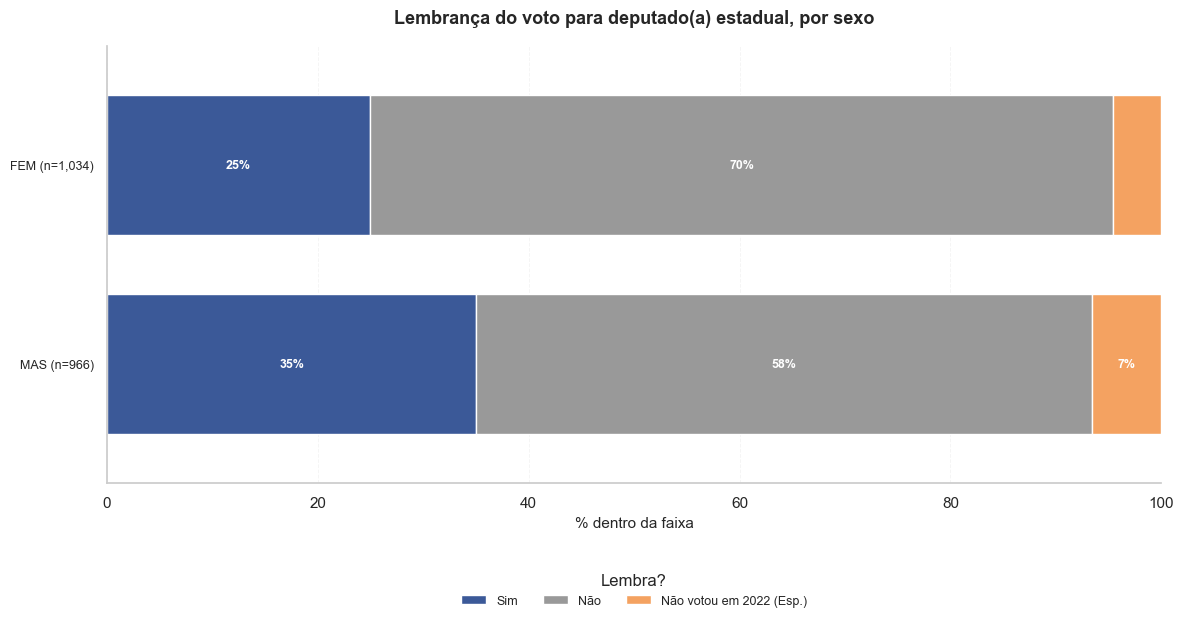

In [9]:
# Distribuição da lembrança de voto DENTRO de cada sexo: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada sexo.
counts_fx = df_cesop["SEXO"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["SEXO"], df_cesop["P_01A"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) estadual, por sexo",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_estadual_sexo.png", dpi=120, bbox_inches="tight")
plt.show()

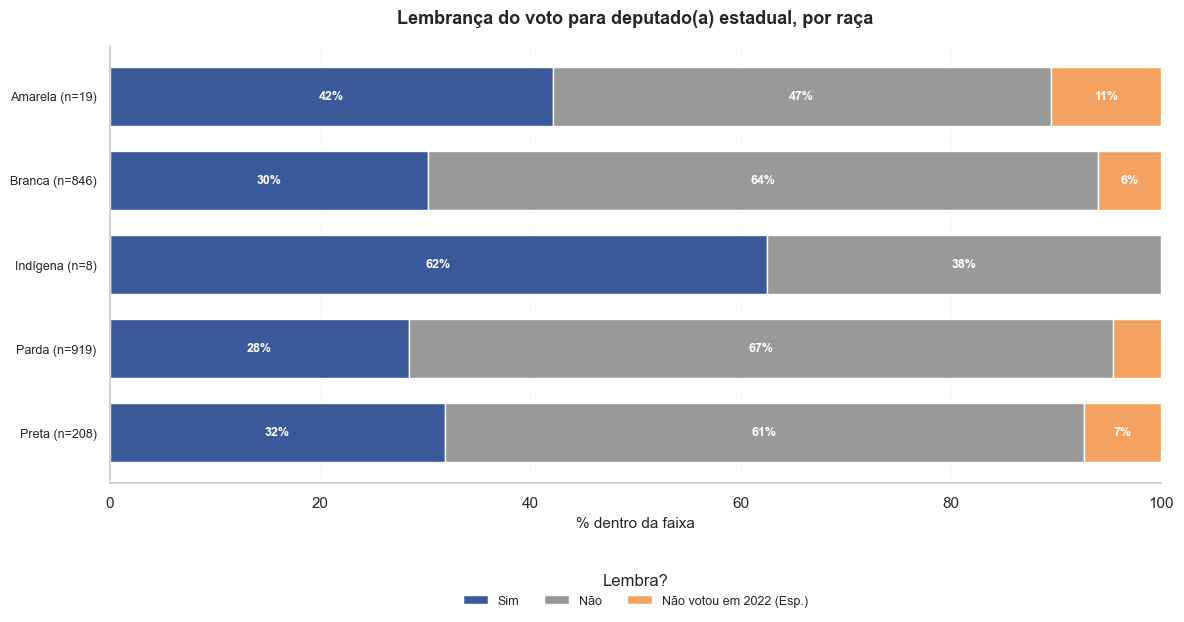

In [10]:
# Distribuição da lembrança de voto DENTRO de cada raça: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada raça.
counts_fx = df_cesop["RACA"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RACA"], df_cesop["P_01A"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) estadual, por raça",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_estadual_raca.png", dpi=120, bbox_inches="tight")
plt.show()

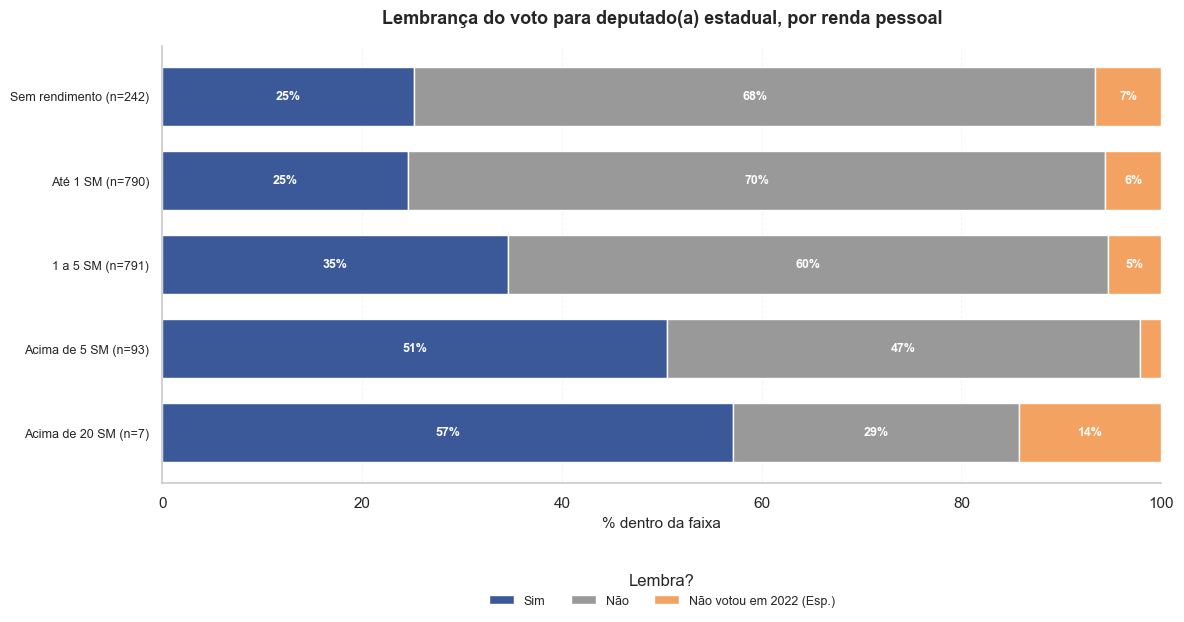

In [11]:
# Distribuição da lembrança de voto DENTRO de cada renda pessoal: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada renda pessoal.
counts_fx = df_cesop["RENDA_PESSOAL"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RENDA_PESSOAL"], df_cesop["P_01A"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) estadual, por renda pessoal",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_estadual_renda_pessoal.png", dpi=120, bbox_inches="tight")
plt.show()

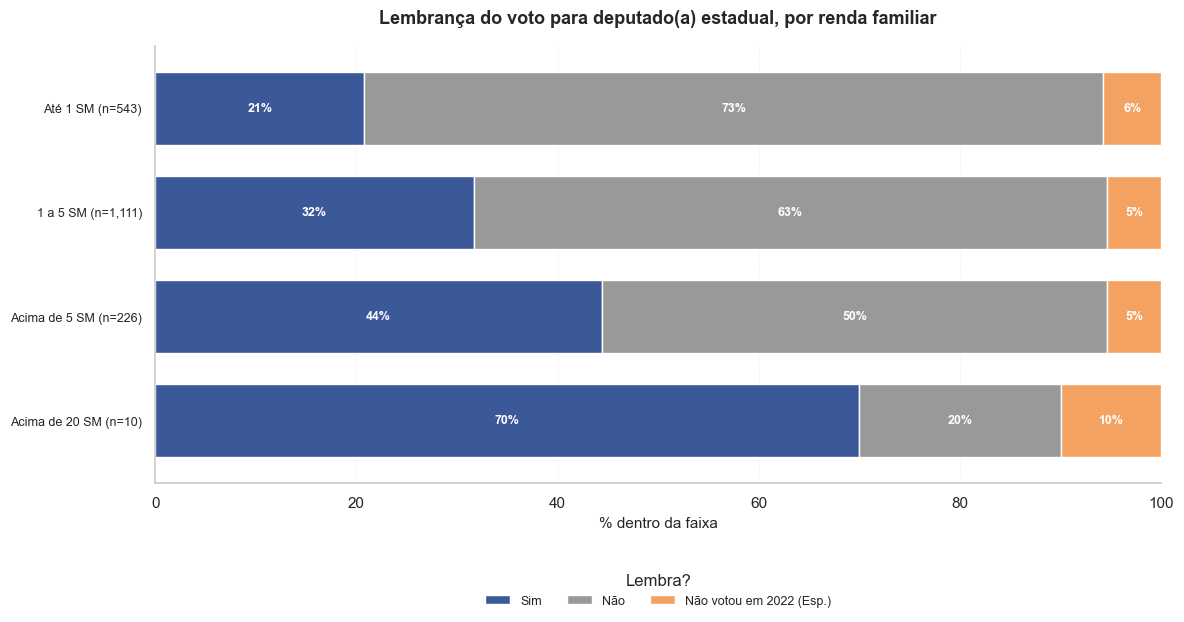

In [12]:
# Distribuição da lembrança de voto DENTRO de cada renda familiar: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada renda familiar.
counts_fx = df_cesop["RENDA_FAMILIAR"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RENDA_FAMILIAR"], df_cesop["P_01A"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) estadual, por renda familiar",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_estadual_renda_familiar.png", dpi=120, bbox_inches="tight")
plt.show()

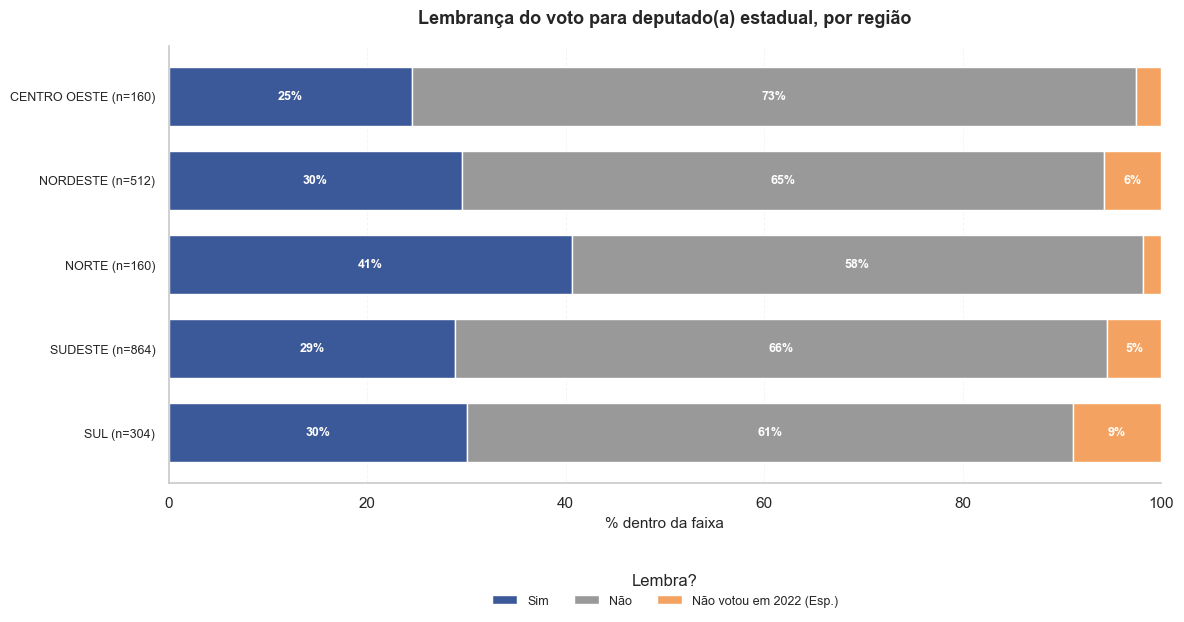

In [13]:
# Distribuição da lembrança de voto DENTRO de cada região: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada região.
counts_fx = df_cesop["REGIAO"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["REGIAO"], df_cesop["P_01A"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) estadual, por região",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_estadual_regiao.png", dpi=120, bbox_inches="tight")
plt.show()

#### Lembrança do voto — Deputado(a) federal

Os mesmos recortes para o cargo federal, permitindo comparar se os padrões se mantêm.

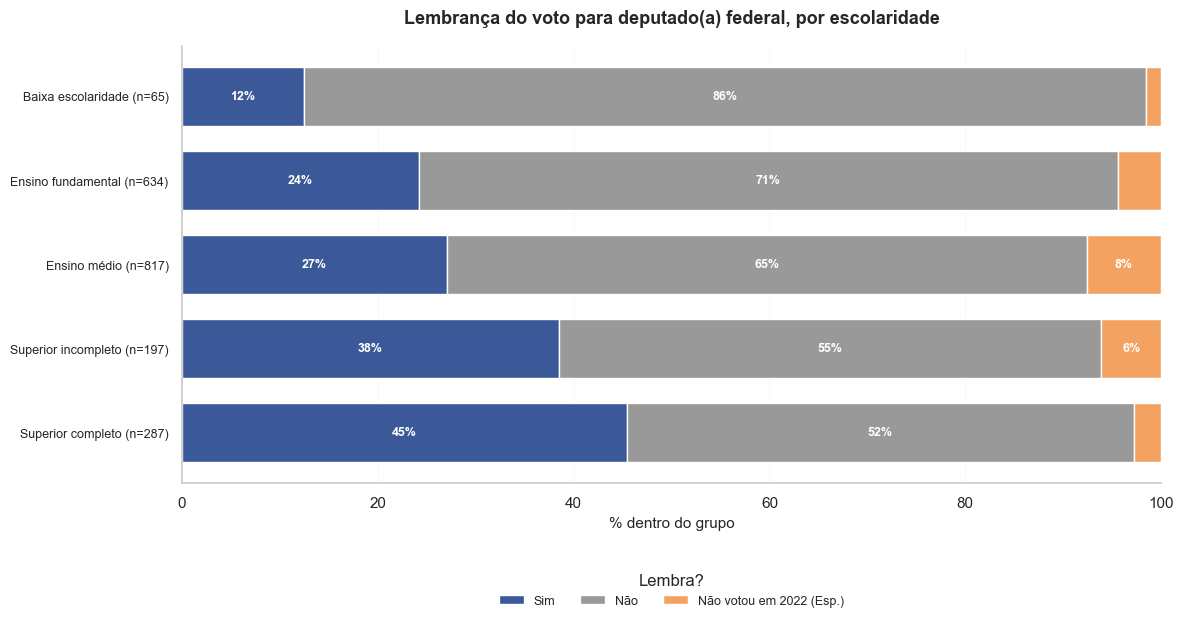

In [14]:
# Distribuição da lembrança de voto DENTRO de cada escolaridade: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada escolaridade.
counts_fx = df_cesop["ESCOL_GRUPO"].value_counts()

ct_escol_raw = pd.crosstab(df_cesop["ESCOL_GRUPO"], df_cesop["P_01B"], normalize="index") * 100
ct_escol, colunas_e = _cols_lemb(ct_escol_raw)
ct_escol = ct_escol.reindex([c for c in ORDEM_ESCOL_LEMB if c in ct_escol.index])

cores_e = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_e]

labels_y_escol = [
    f"{cat} (n={int(counts_escol.get(cat, 0)):,})"
    for cat in ct_escol.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_escol[colunas_e].plot.barh(stacked=True, ax=ax, color=cores_e, width=0.7)

# Define ticks explicitamente antes de invert para garantir correspondência correta.
ax.set_yticks(range(len(ct_escol.index)))
ax.set_yticklabels(labels_y_escol, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) federal, por escolaridade",
             "% dentro do grupo")
_rotulos_empilhados(ax, colunas_e)
_legenda_lemb(ax, colunas_e)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_federal_escolaridade.png", dpi=120, bbox_inches="tight")
plt.show()

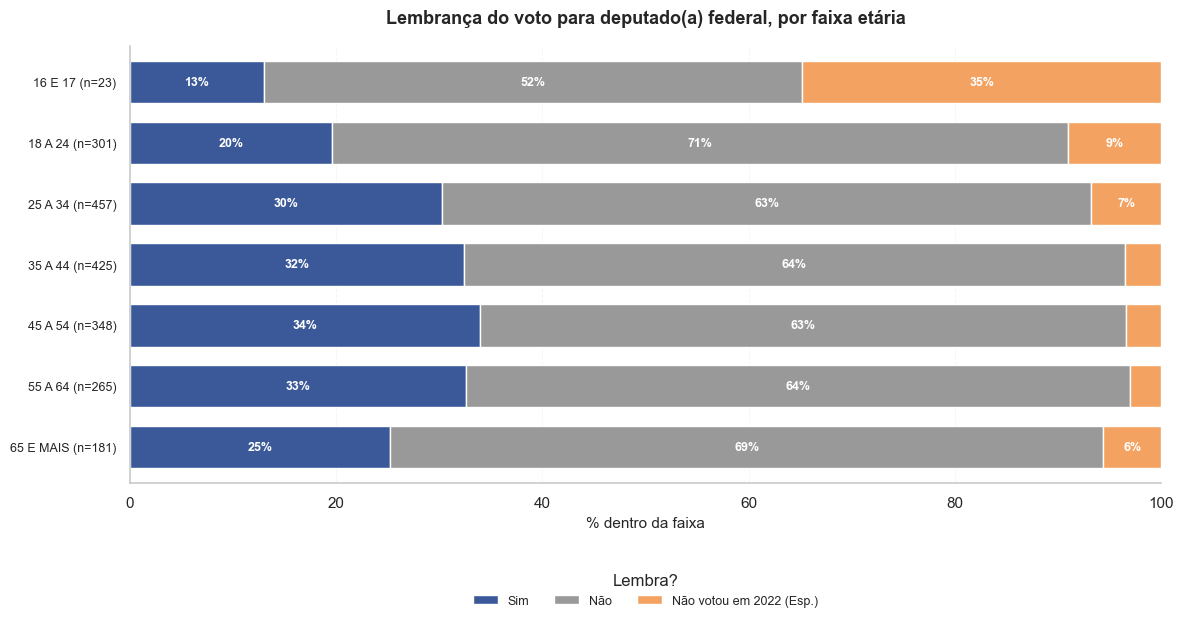

In [15]:
# Distribuição da lembrança de voto DENTRO de cada faixa etária: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada faixa etária.
counts_fx = df_cesop["FX_ID"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["FX_ID"], df_cesop["P_01B"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) federal, por faixa etária",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_federal_fx_idade.png", dpi=120, bbox_inches="tight")
plt.show()

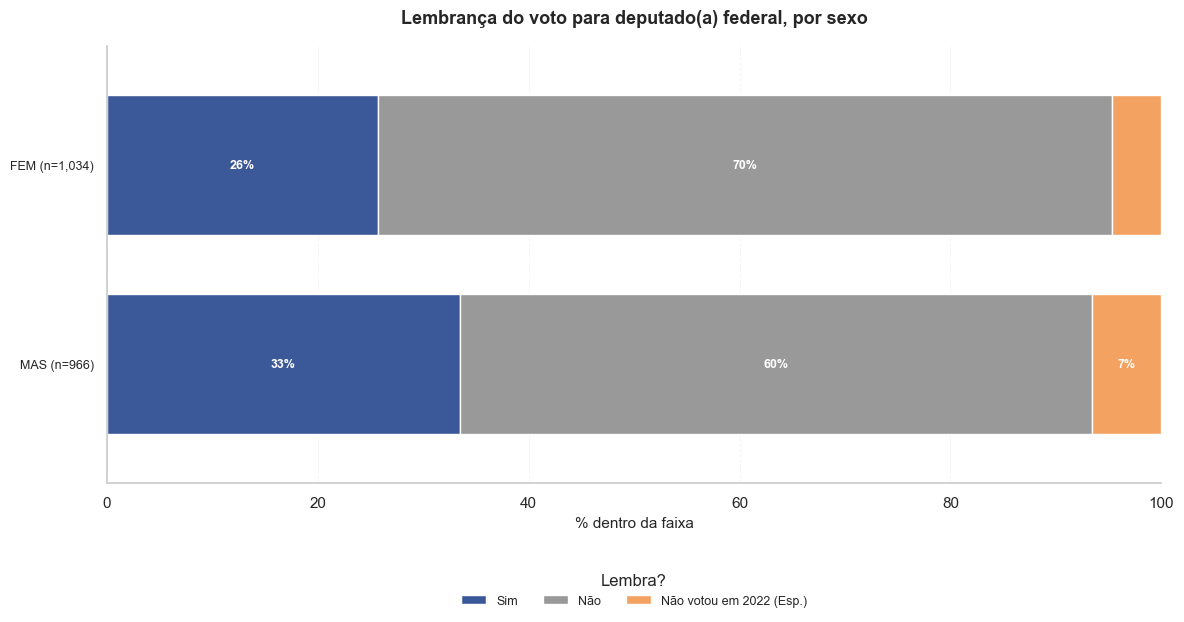

In [16]:
# Distribuição da lembrança de voto DENTRO de cada sexo: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada sexo.
counts_fx = df_cesop["SEXO"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["SEXO"], df_cesop["P_01B"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) federal, por sexo",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_federal_sexo.png", dpi=120, bbox_inches="tight")
plt.show()

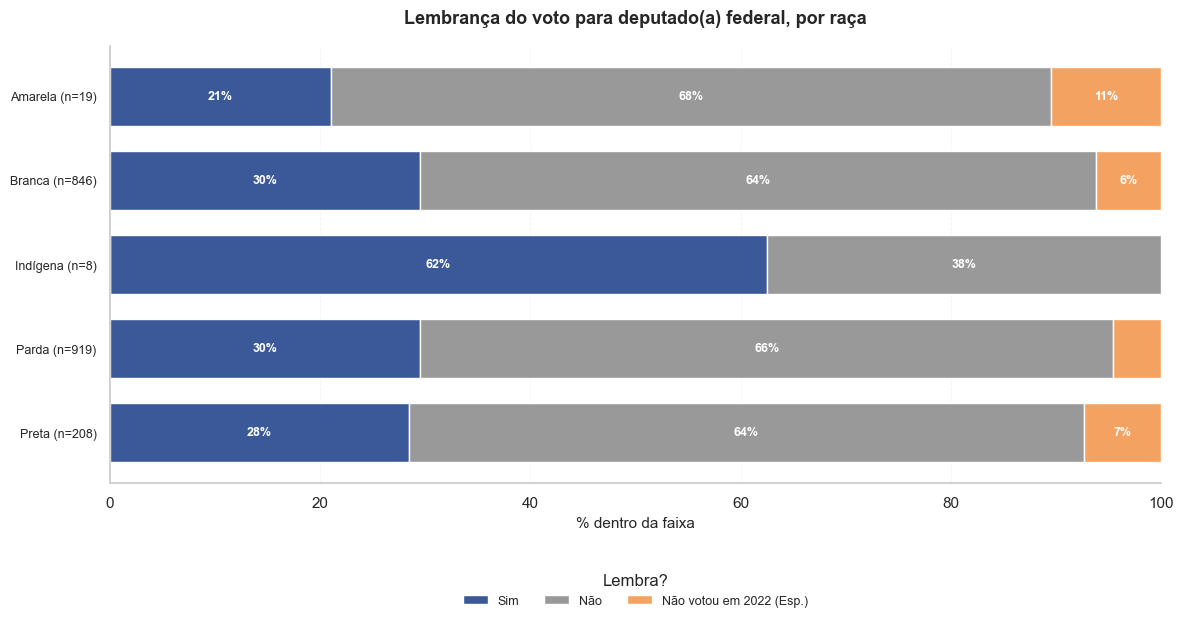

In [17]:
# Distribuição da lembrança de voto DENTRO de cada raça: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada raça.
counts_fx = df_cesop["RACA"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RACA"], df_cesop["P_01B"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) federal, por raça",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_federal_raca.png", dpi=120, bbox_inches="tight")
plt.show()

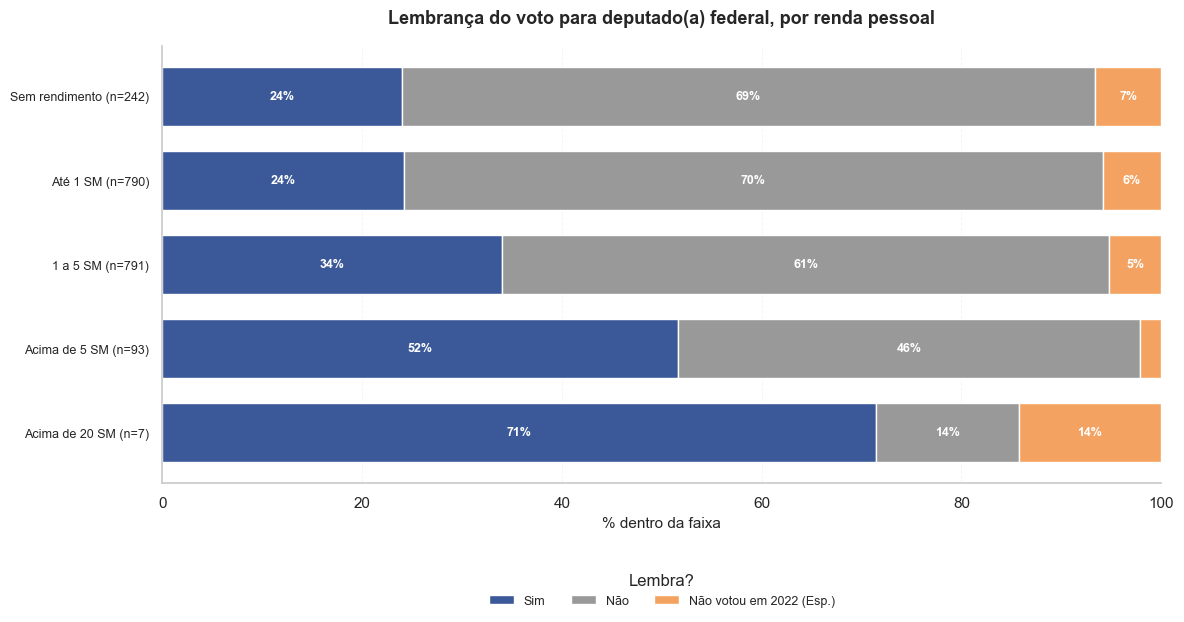

In [18]:
# Distribuição da lembrança de voto DENTRO de cada renda pessoal: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada renda pessoal.
counts_fx = df_cesop["RENDA_PESSOAL"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RENDA_PESSOAL"], df_cesop["P_01B"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) federal, por renda pessoal",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_federal_renda_pessoal.png", dpi=120, bbox_inches="tight")
plt.show()

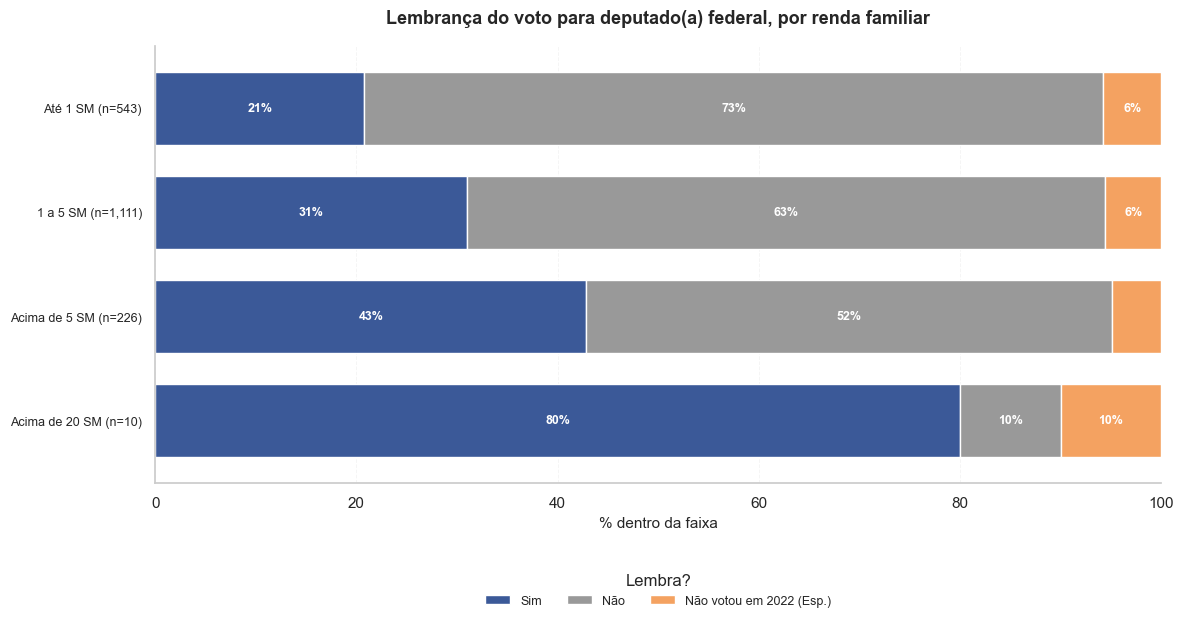

In [19]:
# Distribuição da lembrança de voto DENTRO de cada renda familiar: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada renda familiar.
counts_fx = df_cesop["RENDA_FAMILIAR"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RENDA_FAMILIAR"], df_cesop["P_01B"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) federal, por renda familiar",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_federal_renda_familiar.png", dpi=120, bbox_inches="tight")
plt.show()

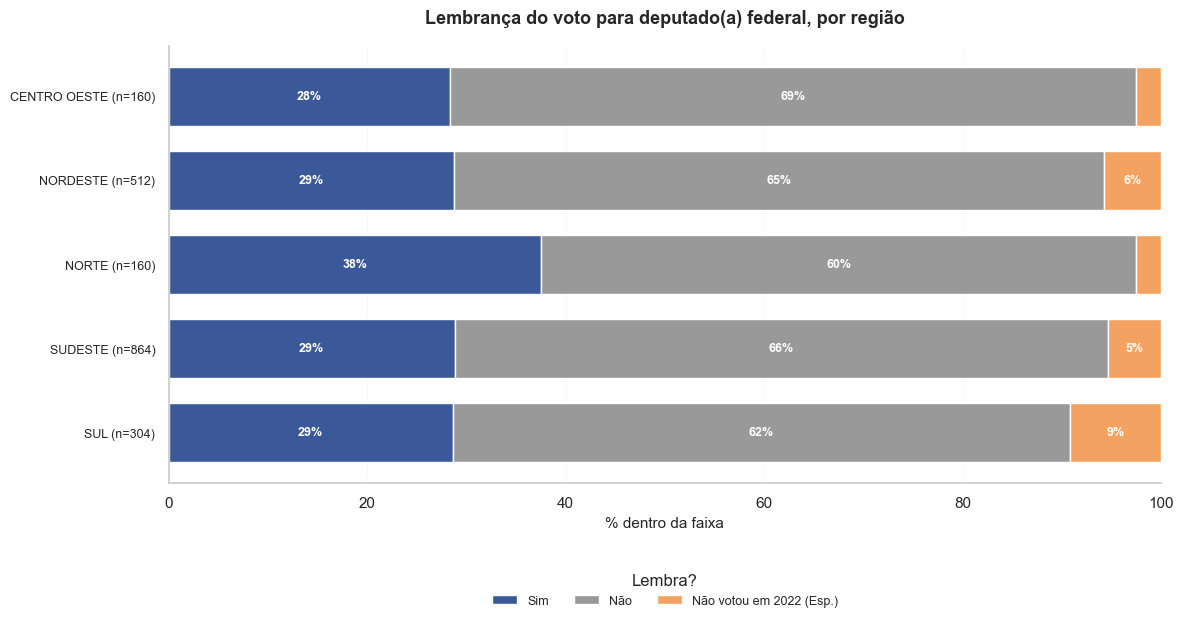

In [20]:
# Distribuição da lembrança de voto DENTRO de cada região: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada região.
counts_fx = df_cesop["REGIAO"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["REGIAO"], df_cesop["P_01B"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) federal, por região",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_federal_regiao.png", dpi=120, bbox_inches="tight")
plt.show()

#### Lembrança do voto — Senador(a)

Os mesmos recortes para o senador, fechando a comparação entre os três cargos legislativos.

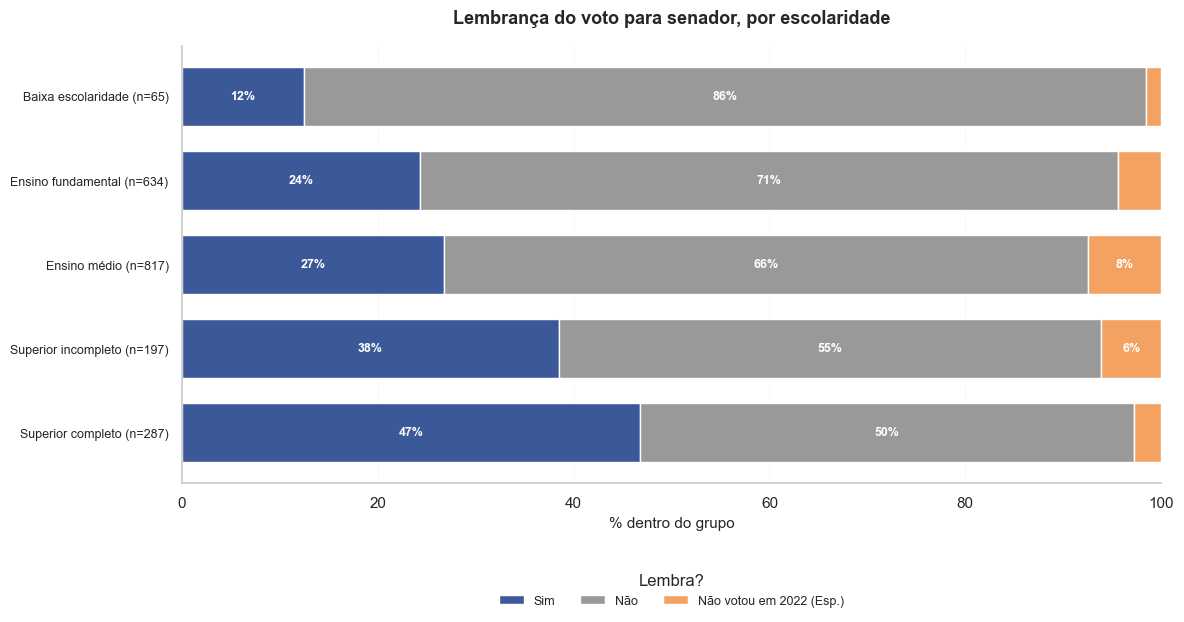

In [21]:
# Recalcula a contagem da própria dimensão (escolaridade) para os rótulos n=.
counts_escol = df_cesop["ESCOL_GRUPO"].value_counts()

ct_escol_raw = pd.crosstab(df_cesop["ESCOL_GRUPO"], df_cesop["P_01C"], normalize="index") * 100
ct_escol, colunas_e = _cols_lemb(ct_escol_raw)
ct_escol = ct_escol.reindex([c for c in ORDEM_ESCOL_LEMB if c in ct_escol.index])

cores_e = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_e]

labels_y_escol = [
    f"{cat} (n={int(counts_escol.get(cat, 0)):,})"
    for cat in ct_escol.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_escol[colunas_e].plot.barh(stacked=True, ax=ax, color=cores_e, width=0.7)

# Define ticks explicitamente antes de invert para garantir correspondência correta.
ax.set_yticks(range(len(ct_escol.index)))
ax.set_yticklabels(labels_y_escol, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para senador, por escolaridade",
             "% dentro do grupo")
_rotulos_empilhados(ax, colunas_e)
_legenda_lemb(ax, colunas_e)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02f_lembranca_voto_senador_escolaridade.png", dpi=120, bbox_inches="tight")
plt.show()

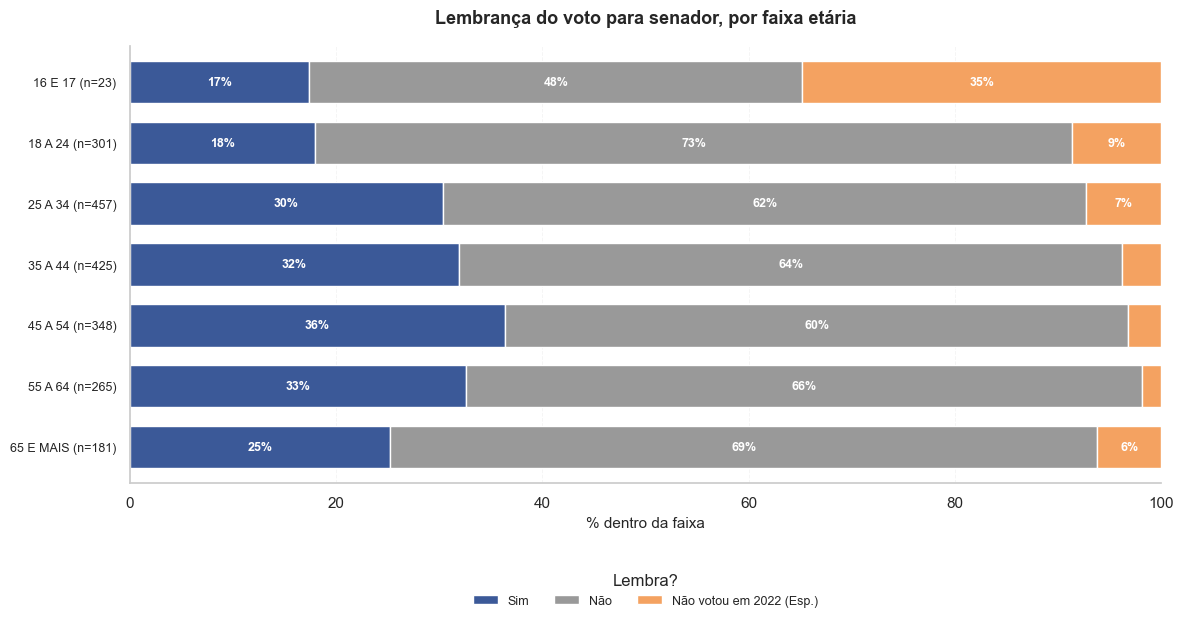

In [22]:
# Recalcula a contagem da PRÓPRIA dimensão (faixa etária). Sem esta linha, os
# rótulos n= herdariam o counts_fx de uma célula anterior (bug de estado).
counts_fx = df_cesop["FX_ID"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["FX_ID"], df_cesop["P_01C"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para senador, por faixa etária",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02g_lembranca_voto_senador_fx_idade.png", dpi=120, bbox_inches="tight")
plt.show()

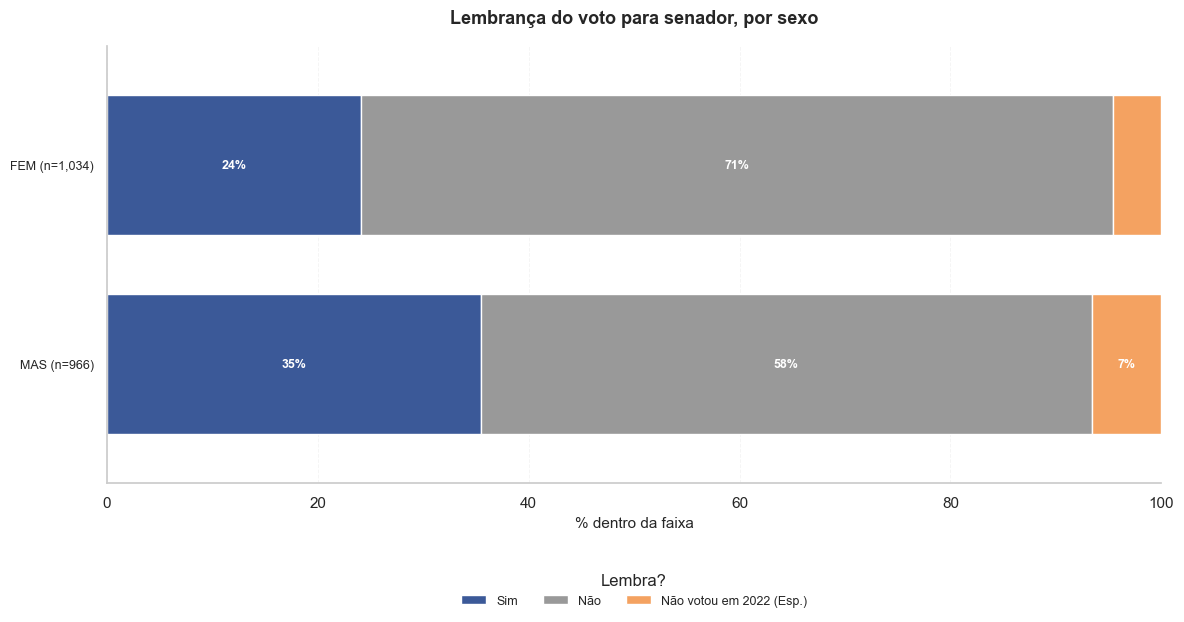

In [23]:
# Distribuição da lembrança de voto DENTRO de cada sexo: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada sexo.
counts_fx = df_cesop["SEXO"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["SEXO"], df_cesop["P_01C"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para senador, por sexo",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_senador_sexo.png", dpi=120, bbox_inches="tight")
plt.show()

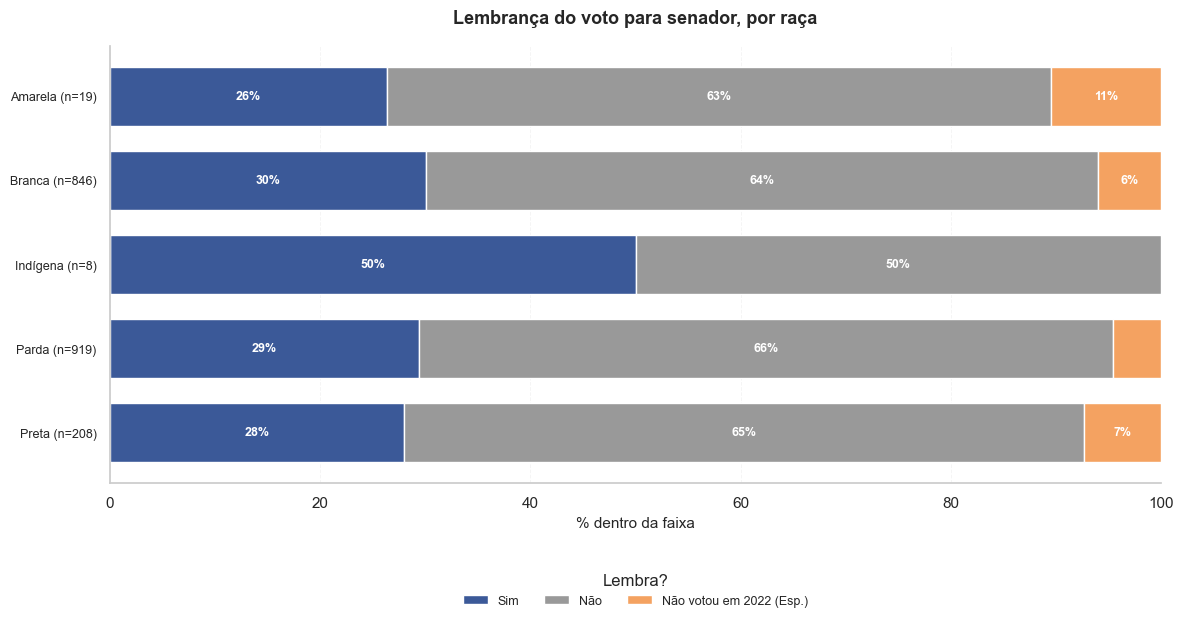

In [24]:
# Distribuição da lembrança de voto DENTRO de cada raça: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada raça.
counts_fx = df_cesop["RACA"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RACA"], df_cesop["P_01C"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para senador, por raça",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_senador_raca.png", dpi=120, bbox_inches="tight")
plt.show()

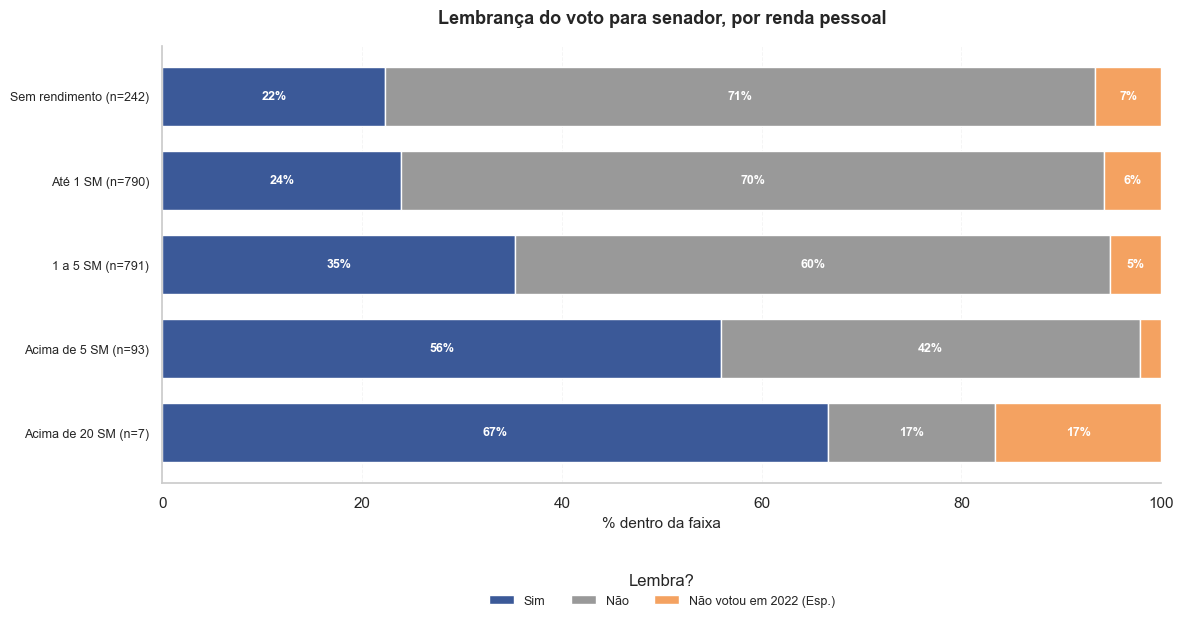

In [25]:
# Distribuição da lembrança de voto DENTRO de cada renda pessoal: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada renda pessoal.
counts_fx = df_cesop["RENDA_PESSOAL"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RENDA_PESSOAL"], df_cesop["P_01C"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para senador, por renda pessoal",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_senador_renda_pessoal.png", dpi=120, bbox_inches="tight")
plt.show()

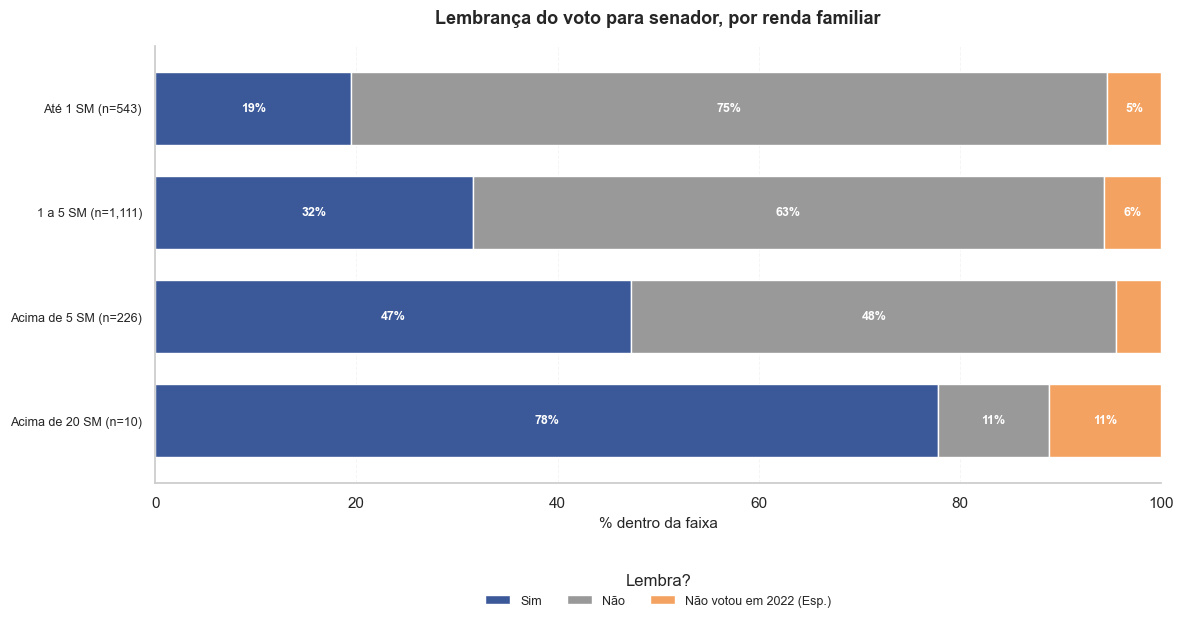

In [26]:
# Distribuição da lembrança de voto DENTRO de cada renda familiar: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada renda familiar.
counts_fx = df_cesop["RENDA_FAMILIAR"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RENDA_FAMILIAR"], df_cesop["P_01C"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para senador, por renda familiar",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_senador_renda_familiar.png", dpi=120, bbox_inches="tight")
plt.show()

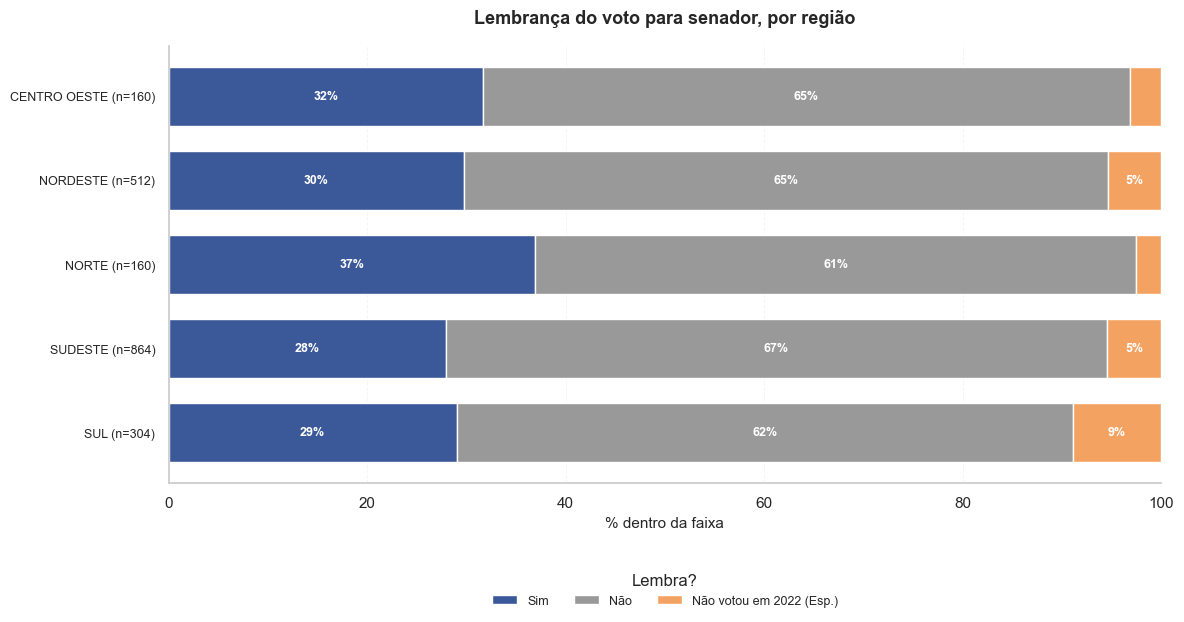

In [27]:
# Distribuição da lembrança de voto DENTRO de cada região: a crosstab é
# normalizada por linha (cada grupo soma 100%) e as barras empilhadas
# permitem comparar a composição Sim/Não/Não votou entre os grupos.
# O n= no rótulo indica quantos respondentes há em cada região.
counts_fx = df_cesop["REGIAO"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["REGIAO"], df_cesop["P_01C"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para senador, por região",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_senador_regiao.png", dpi=120, bbox_inches="tight")
plt.show()

**Síntese — lembrança de voto.** Ao contrário do que se poderia supor, a lembrança é **praticamente idêntica entre os três cargos**: ~**30% lembram** em quem votaram (29,8% estadual, 29,4% federal, 29,6% senador) e cerca de **65% não lembram** (mais ~5,5% que não votaram). Ou seja, **a maioria não recorda o voto legislativo de 2022**, qualquer que seja o cargo — um indício de baixo vínculo com a representação legislativa. Nos recortes, a lembrança tende a ser **maior entre os mais escolarizados e nas faixas adultas**, e menor entre os jovens: primeiro sinal de que escolaridade e engajamento caminham juntos, hipótese retomada no cruzamento com o TSE (seção 7).

## 3. Prioridades políticas

Quais temas os respondentes consideram prioritários para a atuação política? A análise é organizada em três perspectivas:

1. **Primeira escolha** — tema considerado mais importante por cada respondente.
2. **Até três escolhas** — temas mais recorrentes considerando todas as menções.
3. **Variação regional** — como as primeiras escolhas diferem entre as regiões do Brasil.

> Os rótulos das prioridades foram abreviados para melhorar a legibilidade dos gráficos.

In [28]:
counts_fx = df_cesop["P_02_1"].value_counts()
counts_fx

P_02_1
Melhorar a qualidade da saúde                                                    400
Incentivar a geração de empregos                                                 294
Reduzir as desigualdades sociais                                                 286
Reduzir a violência                                                              250
Combater o preconceito (racismo, homofobia, diferença de classe social, etc.)    233
Melhorar a qualidade da educação                                                 222
Preservar os valores ligados à família                                           103
Aumentar os impostos de grandes fortunas (ou dos mais ricos)                      45
Ampliar os espaços de participação política da população                          40
Defender a igualdade entre homens e mulheres                                      38
Ampliar o uso de energias renováveis                                              25
Combater as mudanças climáticas/desmatamento              

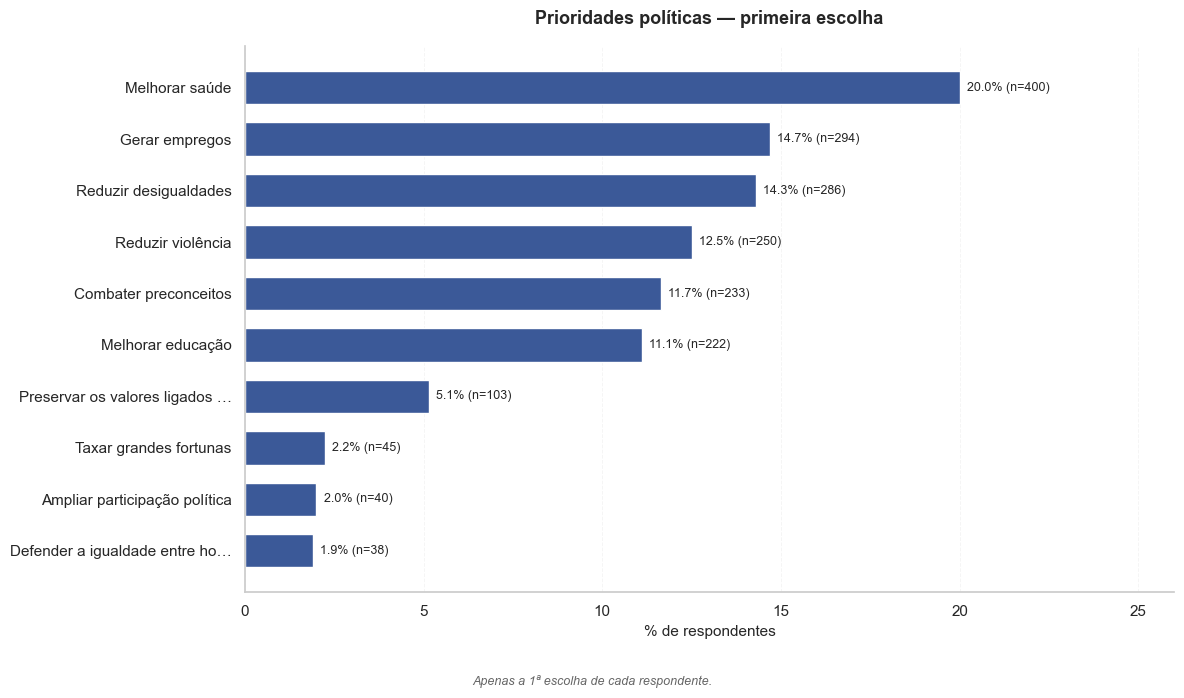

In [29]:
def _abrev_prio(nome):
    """Retorna versão abreviada da prioridade; fallback: trunca em 32 chars."""
    tabela = [
        ("preconceito",           "Combater preconceitos"),
        ("grandes fortunas",      "Taxar grandes fortunas"),
        ("impostos",              "Taxar grandes fortunas"),
        ("violência",             "Reduzir violência"),
        ("desigualdade",          "Reduzir desigualdades"),
        ("empregos",              "Gerar empregos"),
        ("saúde",                 "Melhorar saúde"),
        ("educação",              "Melhorar educação"),
        ("valores familiares",    "Preservar valores familiares"),
        ("participação política", "Ampliar participação política"),
        ("igualdade de gênero",   "Defender igualdade de gênero"),
        ("mudanças climáticas",   "Combater mudanças climáticas"),
        ("energia renovável",     "Incentivar energia renovável"),
    ]
    nome_lower = str(nome).lower()
    for chave, abrev in tabela:
        if chave in nome_lower:
            return abrev
    s = str(nome)
    return s if len(s) <= 32 else s[:29] + "…"


# === Gráfico 1: Primeira escolha ===
top1_raw = df_cesop["P_02_1"].value_counts().head(10)
df_top1 = pd.DataFrame({"pct": top1_raw / len(df_cesop) * 100, "n": top1_raw})
df_top1.index = [_abrev_prio(i) for i in df_top1.index]
df_top1 = df_top1.sort_values("pct")  # ascending → maior fica no topo com barh

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(df_top1.index, df_top1["pct"], color=COR_PRINCIPAL, height=0.65)

ax.set_title("Prioridades políticas — primeira escolha", pad=16)
ax.set_xlabel("% de respondentes")
ax.set_xlim(0, df_top1["pct"].max() * 1.30)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, pct, n in zip(bars, df_top1["pct"], df_top1["n"]):
    ax.text(pct + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={int(n):,})", va="center", fontsize=9)

fig.text(0.5, 0.01, "Apenas a 1ª escolha de cada respondente.",
         ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(PATH_FIGURAS / "03_prioridade_politica_primeira_escolha.png", dpi=120, bbox_inches="tight")
plt.show()

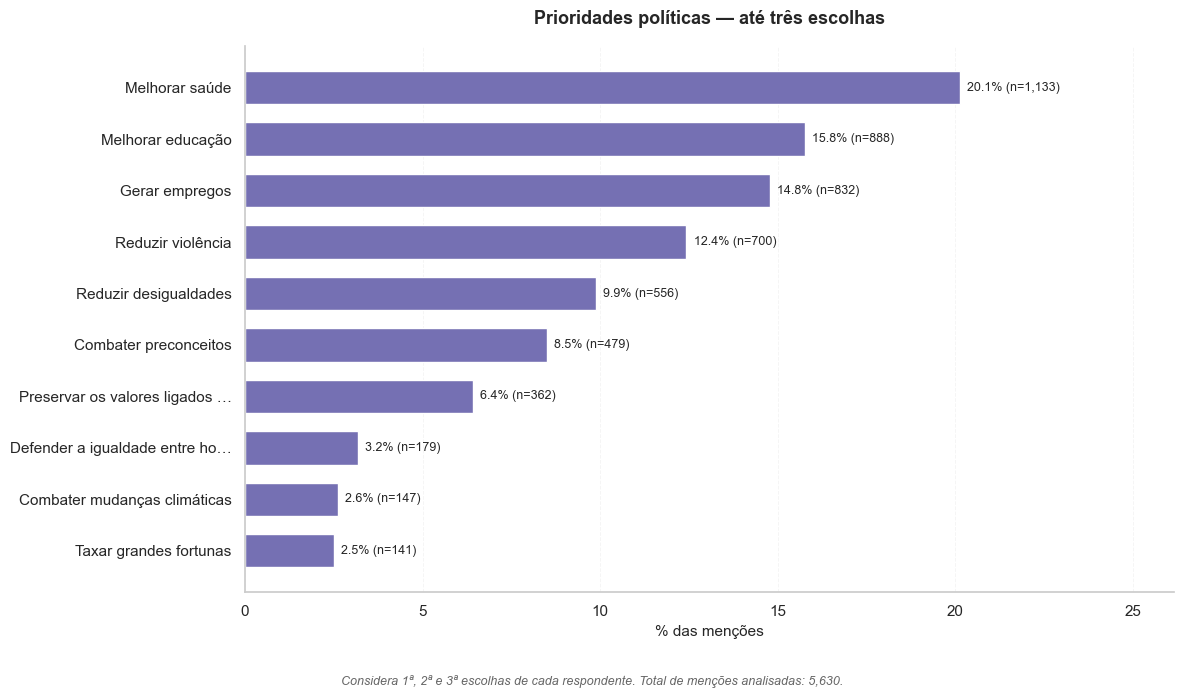

In [30]:
# === Gráfico 2: Até três escolhas ===
# Denominador = total de menções (não respondentes), pois cada respondente pode citar até 3.
cols_p2 = ["P_02_1", "P_02_2", "P_02_3"]
todas_prio = pd.concat([df_cesop[c] for c in cols_p2], ignore_index=True).dropna()
total_mencoes = len(todas_prio)

acum_raw = todas_prio.value_counts().head(10)
df_acum = pd.DataFrame({"pct": acum_raw / total_mencoes * 100, "n": acum_raw})
df_acum.index = [_abrev_prio(i) for i in df_acum.index]
df_acum = df_acum.sort_values("pct")  # maior fica no topo

COR_ACUM = "#7570b3"  # roxo — diferencia visualmente do gráfico de 1ª escolha

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(df_acum.index, df_acum["pct"], color=COR_ACUM, height=0.65)

ax.set_title("Prioridades políticas — até três escolhas", pad=16)
ax.set_xlabel("% das menções")
ax.set_xlim(0, df_acum["pct"].max() * 1.30)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, pct, n in zip(bars, df_acum["pct"], df_acum["n"]):
    ax.text(pct + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={int(n):,})", va="center", fontsize=9)

fig.text(0.5, 0.01,
         f"Considera 1ª, 2ª e 3ª escolhas de cada respondente. "
         f"Total de menções analisadas: {total_mencoes:,}.",
         ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(PATH_FIGURAS / "03_prioridade_politica_mais_escolhas.png", dpi=120, bbox_inches="tight")
plt.show()

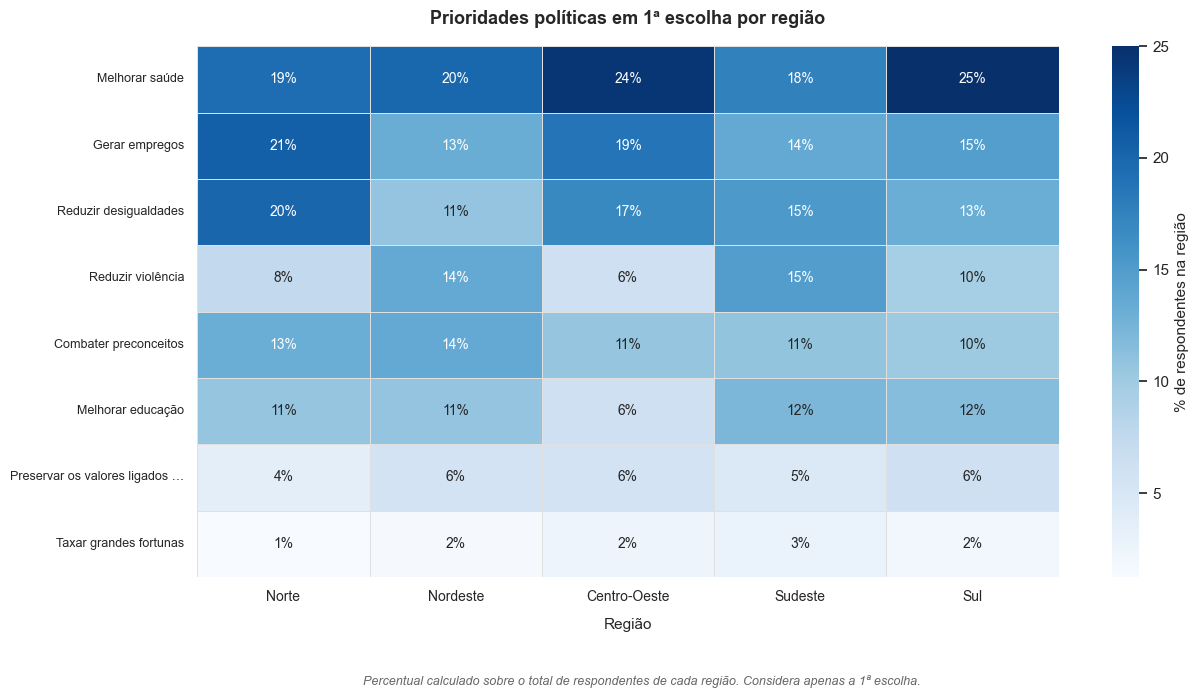

In [31]:
# === Gráfico 3: Heatmap — prioridades em 1ª escolha por região ===
# Denominador: total de respondentes de cada região (independente de responder P_02_1).
REGIAO_DISPLAY_HM = {
    "NORTE": "Norte", "NORDESTE": "Nordeste", "SUL": "Sul",
    "SUDESTE": "Sudeste", "CENTRO OESTE": "Centro-Oeste",
}
ORDEM_REGIOES_HM = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]

# Top 8 prioridades em 1ª escolha para evitar heatmap poluído.
top8_orig  = df_cesop["P_02_1"].value_counts().head(8).index.tolist()
top8_abrev = [_abrev_prio(p) for p in top8_orig]

df_hm = df_cesop.assign(
    P_ABREV     = df_cesop["P_02_1"].map(_abrev_prio),
    REGIAO_DISP = df_cesop["REGIAO"].map(REGIAO_DISPLAY_HM),
)

# Total de respondentes por região (inclui quem não respondeu P_02_1).
regiao_totals = df_hm.dropna(subset=["REGIAO_DISP"])["REGIAO_DISP"].value_counts()

# Contagem bruta de escolhas por prioridade × região.
ct_abs = pd.crosstab(
    df_hm.dropna(subset=["P_ABREV", "REGIAO_DISP"])["P_ABREV"],
    df_hm.dropna(subset=["P_ABREV", "REGIAO_DISP"])["REGIAO_DISP"],
)
ct_pr = ct_abs.div(regiao_totals, axis=1) * 100
ct_pr = ct_pr.fillna(0)

# Reordena linhas (por frequência geral) e colunas (ordem geográfica padrão).
ct_pr = ct_pr.reindex(
    index   = [p for p in top8_abrev if p in ct_pr.index],
    columns = [r for r in ORDEM_REGIOES_HM if r in ct_pr.columns],
)

# Anotações com sufixo % — clareza do tipo de valor sem sobrecarregar o título.
annot = ct_pr.round(0).astype(int).astype(str) + "%"

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(
    ct_pr,
    annot=annot, fmt="",
    cmap="Blues",
    ax=ax,
    linewidths=0.5, linecolor="#e0e0e0",
    cbar_kws={"label": "% de respondentes na região"},
    annot_kws={"size": 10},
)
ax.set_title("Prioridades políticas em 1ª escolha por região", pad=16)
ax.set_xlabel("Região", labelpad=10)
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=9)

fig.text(
    0.5, 0.01,
    "Percentual calculado sobre o total de respondentes de cada região. Considera apenas a 1ª escolha.",
    ha="center", fontsize=9, color="#666666", style="italic",
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(PATH_FIGURAS / "03_prioridade_politica_primeira_escolha_regiao.png", dpi=120, bbox_inches="tight")
plt.show()

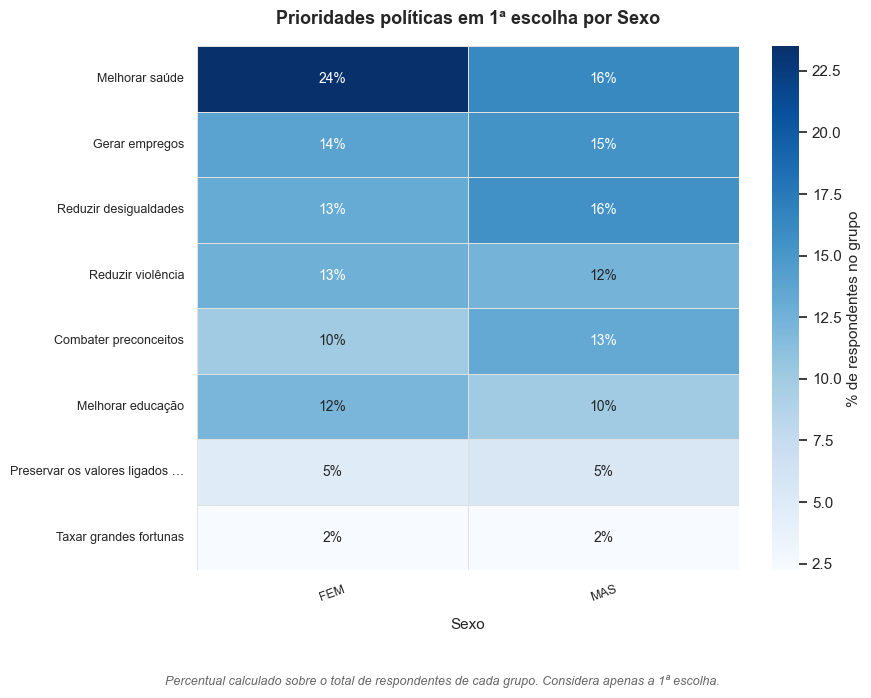

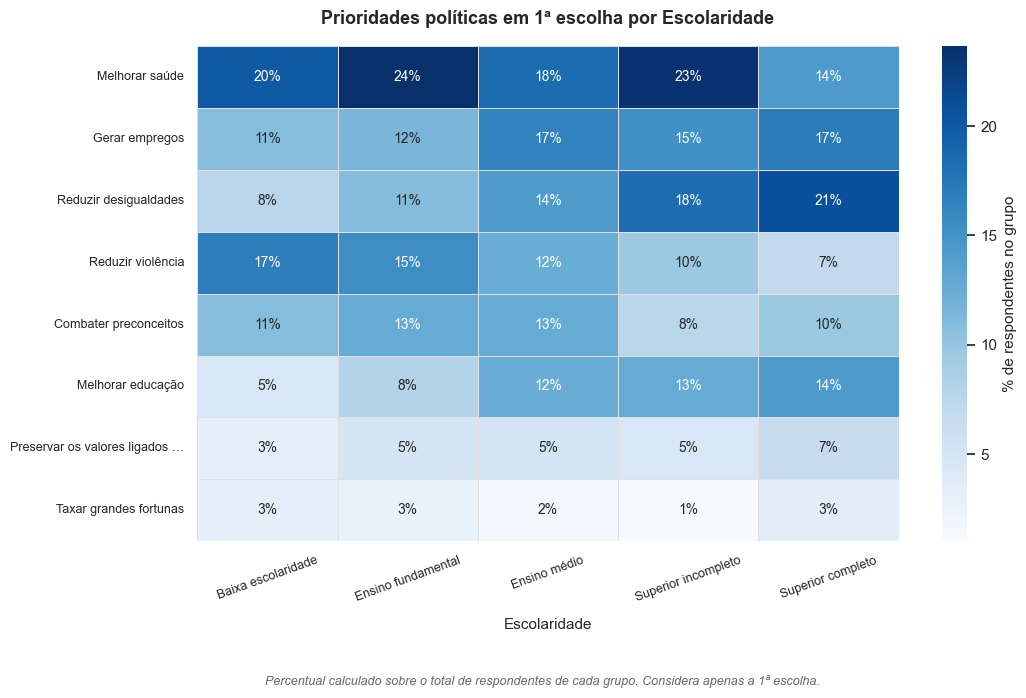

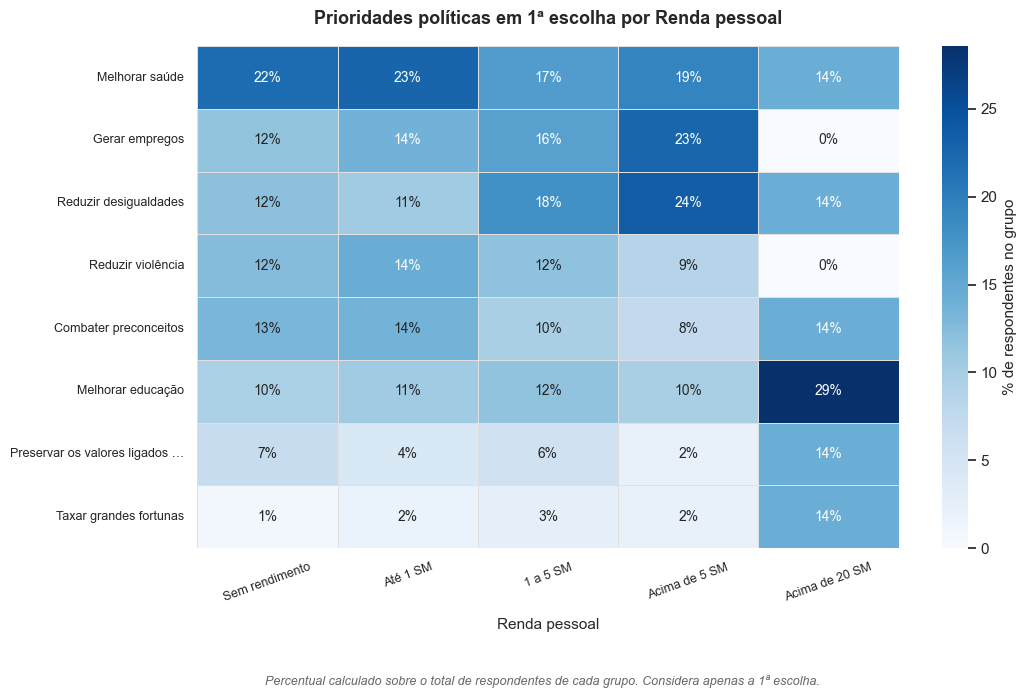

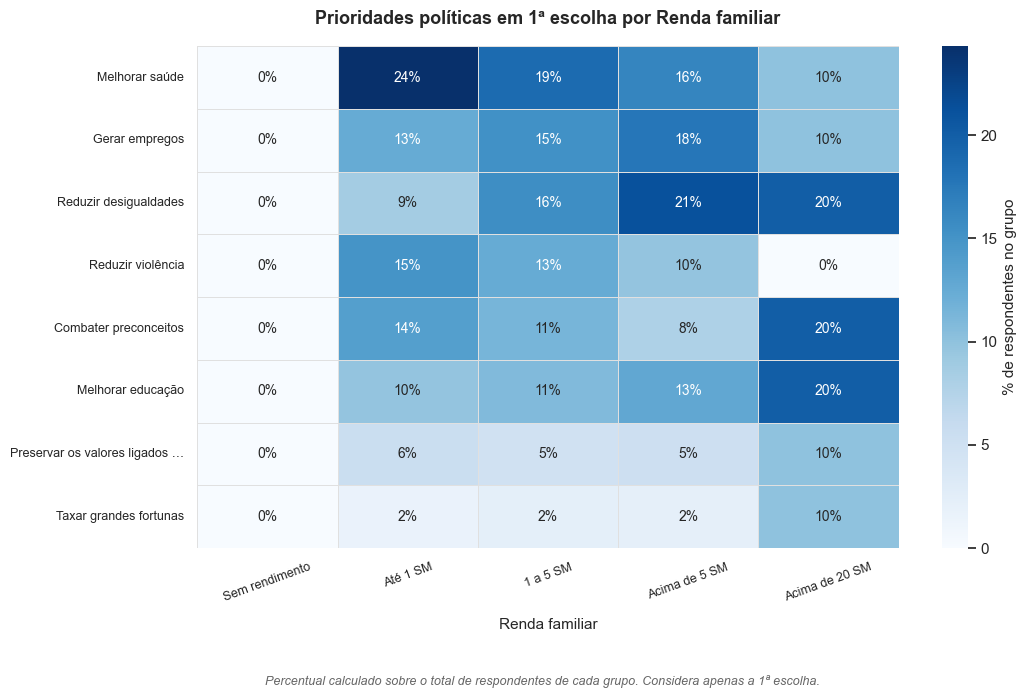

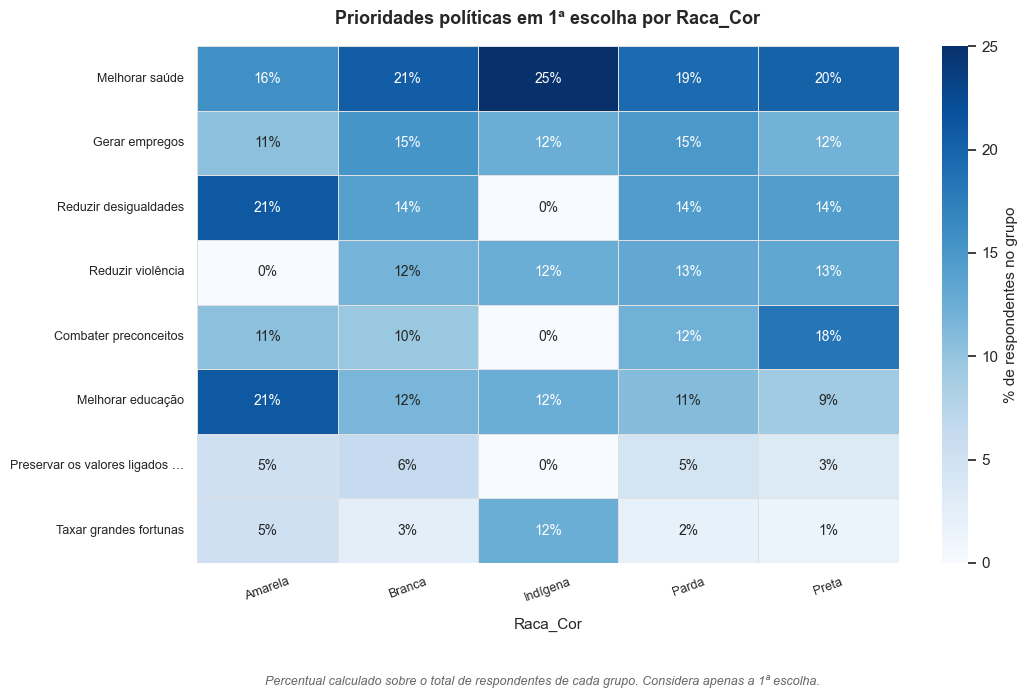

In [32]:
# === Heatmaps de prioridades em 1ª escolha × dimensões sociodemográficas ===
# Replica o padrão do heatmap por região para: sexo, escolaridade, renda e raça/cor.
# Denominador: total de respondentes por grupo (independente de responder P_02_1).

def _heatmap_prio_dim(col_name, titulo_eixo, ordem_cols=None):
    """Plota heatmap de prioridades em 1ª escolha × dimensão sociodemográfica."""
    df_aux = df_cesop.assign(P_ABREV=df_cesop["P_02_1"].map(_abrev_prio))

    col_totals = df_aux.dropna(subset=[col_name])[col_name].value_counts()

    ct_abs = pd.crosstab(
        df_aux.dropna(subset=["P_ABREV", col_name])["P_ABREV"],
        df_aux.dropna(subset=["P_ABREV", col_name])[col_name],
    )
    ct_pct = ct_abs.div(col_totals, axis=1).fillna(0) * 100

    # Reordena linhas (prioridades por frequência geral) e colunas (ordem lógica se fornecida).
    ct_pct = ct_pct.reindex(index=[p for p in top8_abrev if p in ct_pct.index])
    if ordem_cols:
        ct_pct = ct_pct.reindex(columns=[c for c in ordem_cols if c in ct_pct.columns])

    # Figsize adaptado ao número de colunas.
    n_cols = len(ct_pct.columns)
    figsize = (max(9, n_cols * 2.2), 7)

    annot = ct_pct.round(0).astype(int).astype(str) + "%"

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        ct_pct,
        annot=annot, fmt="",
        cmap="Blues",
        ax=ax,
        linewidths=0.5, linecolor="#e0e0e0",
        cbar_kws={"label": "% de respondentes no grupo"},
        annot_kws={"size": 10},
    )
    ax.set_title(f"Prioridades políticas em 1ª escolha por {titulo_eixo}", pad=16)
    ax.set_xlabel(titulo_eixo, labelpad=10)
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=20, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)

    fig.text(
        0.5, 0.01,
        "Percentual calculado sobre o total de respondentes de cada grupo. "
        "Considera apenas a 1ª escolha.",
        ha="center", fontsize=9, color="#666666", style="italic",
    )
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    # Sanitiza o nome do arquivo (sem espaços/acentos) para portabilidade em Git/web.
    _slug = titulo_eixo.lower().replace(" ", "_").replace("ç", "c").replace("ã", "a")
    plt.savefig(PATH_FIGURAS / f"03_prioridade_primeira_escolha_{_slug}.png", dpi=120, bbox_inches="tight")
    plt.show()


# Ordens semânticas para variáveis com sequência lógica.
ORDEM_RENDA_HM  = ['Sem rendimento', 'Até 1 SM', '1 a 5 SM', 'Acima de 5 SM', 'Acima de 20 SM']
ORDEM_ESCOL_HM  = ['Baixa escolaridade', 'Ensino fundamental', 'Ensino médio', 'Superior incompleto', 'Superior completo' ]

_heatmap_prio_dim("SEXO",           "Sexo")
_heatmap_prio_dim("ESCOL_GRUPO",    "Escolaridade",   ordem_cols=ORDEM_ESCOL_HM)
_heatmap_prio_dim("RENDA_PESSOAL",  "Renda pessoal",  ordem_cols=ORDEM_RENDA_HM)
_heatmap_prio_dim("RENDA_FAMILIAR", "Renda familiar", ordem_cols=ORDEM_RENDA_HM)
_heatmap_prio_dim("RACA",           "Raca_Cor")


**O que as prioridades revelam.** Na 1ª escolha, **saúde lidera** (20,0%), seguida de **emprego** (14,7%) e **redução das desigualdades** (14,3%); os seis temas de serviços e bem-estar (incluindo ainda violência, preconceitos e educação) concentram ~84% das respostas. Em contraste, **'ampliar a participação política' é a penúltima prioridade (2,0%)**. Esse dado conversa diretamente com a seção 5: o brasileiro prioriza **resultados concretos**, não o **processo participativo** — primeiro indício do desengajamento que as próximas seções confirmam.

## 4. Combate às fake news

A pergunta P.03 listou diferentes medidas que poderiam combater a divulgação de fake news. Cada respondente podia citar **de 1 a 6 medidas** (múltipla escolha).

A seção está organizada em quatro partes:

1. **Ranking das medidas** — quais aparecem com maior frequência no total de menções.
2. **Quantidade por respondente** — o respondente tende a citar poucas ou muitas medidas?
3. **Por tipo de ação** — regulamentação versus punição / responsabilização.
4. **Por ator responsabilizado** — usuários, plataformas ou políticos.

Como cada respondente pôde citar mais de uma medida, **os percentuais se referem ao total de menções, não ao total de respondentes**. Esse ponto é essencial para a interpretação correta dos dados.

> Rótulos das medidas foram abreviados para fins de visualização.

[OK] Todas as respostas foram mapeadas com sucesso!


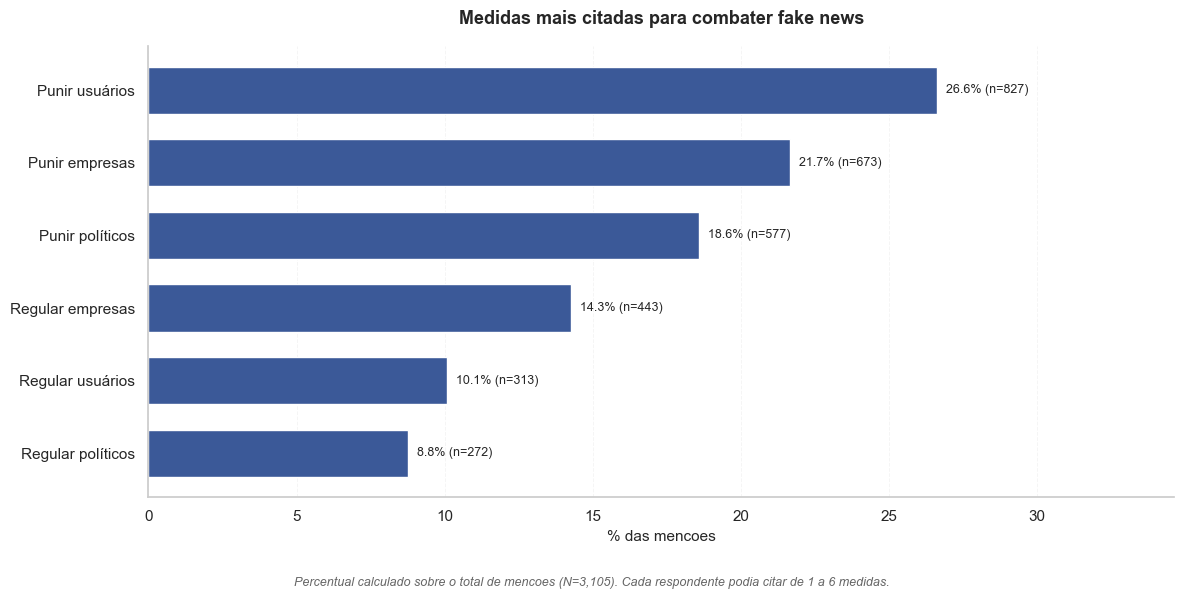

Tabela 1 — Medidas mais citadas (total de mencoes = 3,105)


,Mencoes,% das mencoes
Punir usuários,827,26.6%
Punir empresas,673,21.7%
Punir políticos,577,18.6%
Regular empresas,443,14.3%
Regular usuários,313,10.1%
Regular políticos,272,8.8%


In [33]:
from IPython.display import display

# === Dados e helpers compartilhados — seção 4 (Combate às fake news) ===
cols_p3 = [f"P_03_{i}" for i in range(1, 7)]
todas_medidas_raw = pd.concat([df_cesop[c] for c in cols_p3], ignore_index=True).dropna()
TOTAL_MENC_P3 = len(todas_medidas_raw)


# === MAPEAMENTO_P03: DE/PARA fixo (correspondência exata, sem regex) ===
MAPEAMENTO_P03 = {
    "Ampliar a regulamentação para políticos que divulgam fake news, criadas por eles próprios ou por terceiros": {
        "rótulo": "Regular políticos",
        "tipo": "Regulamentação",
        "ator": "Políticos"
    },
    "Ampliar a regulamentação para usuários que divulgam fake news, criadas por eles próprios ou por terceiros": {
        "rótulo": "Regular usuários",
        "tipo": "Regulamentação",
        "ator": "Usuários"
    },
    "Ampliar a regulamentação, as regras a serem cumpridas pelas plataformas digitais (Facebook, Youtube, WhatsApp, etc.)": {
        "rótulo": "Regular empresas",
        "tipo": "Regulamentação",
        "ator": "Empresas / Plataformas"
    },
    "Responsabilizar e punir as empresas de tecnologia/comunicação que não removerem postagens com conteúdos falsos": {
        "rótulo": "Punir empresas",
        "tipo": "Punição / Responsabilização",
        "ator": "Empresas / Plataformas"
    },
    "Responsabilizar e punir os usuários que divulgam ou compartilham postagens com notícias ou conteúdos falsos": {
        "rótulo": "Punir usuários",
        "tipo": "Punição / Responsabilização",
        "ator": "Usuários"
    },
    "Responsabilizar, punir ou caçar políticos que divulgam ou compartilham postagens com notícias ou conteúdos falsos": {
        "rótulo": "Punir políticos",
        "tipo": "Punição / Responsabilização",
        "ator": "Políticos"
    }
}


def _classifica_p03(resposta_original):
    """Retorna (rótulo, tipo, ator) ou (None, None, None) se não mapeado."""
    if resposta_original in MAPEAMENTO_P03:
        m = MAPEAMENTO_P03[resposta_original]
        return m["rótulo"], m["tipo"], m["ator"]
    return None, None, None


# Aplica o mapeamento a todas as respostas.
todas_medidas_abrev = todas_medidas_raw.map(lambda x: _classifica_p03(x)[0])
todas_medidas_tipo = todas_medidas_raw.map(lambda x: _classifica_p03(x)[1])
todas_medidas_ator = todas_medidas_raw.map(lambda x: _classifica_p03(x)[2])

# Auditoria: valores não mapeados
nao_mapeados = todas_medidas_raw[todas_medidas_abrev.isna()].value_counts()
if len(nao_mapeados) > 0:
    print("" + "="*100)
    print("AUDITORIA: Respostas NAO mapeadas em MAPEAMENTO_P03")
    print("="*100)
    for resposta, count in nao_mapeados.items():
        print(f"  [{count}x] {resposta[:90]}")
    print("="*100 + "")
else:
    print("[OK] Todas as respostas foram mapeadas com sucesso!")


# === Gráfico 1: Ranking das medidas ===
freq_med = todas_medidas_abrev.value_counts()
df_med = pd.DataFrame({"n": freq_med, "pct": freq_med / TOTAL_MENC_P3 * 100})
df_med = df_med.sort_values("pct")

fig, ax = plt.subplots(figsize=(12, max(6, len(df_med) * 0.65)))
bars = ax.barh(df_med.index, df_med["pct"], color=COR_PRINCIPAL, height=0.65)

ax.set_title("Medidas mais citadas para combater fake news", pad=16)
ax.set_xlabel("% das mencoes")
ax.set_xlim(0, df_med["pct"].max() * 1.30)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, pct, n in zip(bars, df_med["pct"], df_med["n"]):
    ax.text(pct + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={int(n):,})", va="center", fontsize=9)

fig.text(
    0.5, 0.01,
    f"Percentual calculado sobre o total de mencoes (N={TOTAL_MENC_P3:,}). "
    "Cada respondente podia citar de 1 a 6 medidas.",
    ha="center", fontsize=9, color="#666666", style="italic",
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print(f"Tabela 1 — Medidas mais citadas (total de mencoes = {TOTAL_MENC_P3:,})")
tab_med = df_med[["n", "pct"]].sort_values("pct", ascending=False).copy()
tab_med.columns = ["Mencoes", "% das mencoes"]
tab_med["% das mencoes"] = tab_med["% das mencoes"].map("{:.1f}%".format)
display(tab_med)

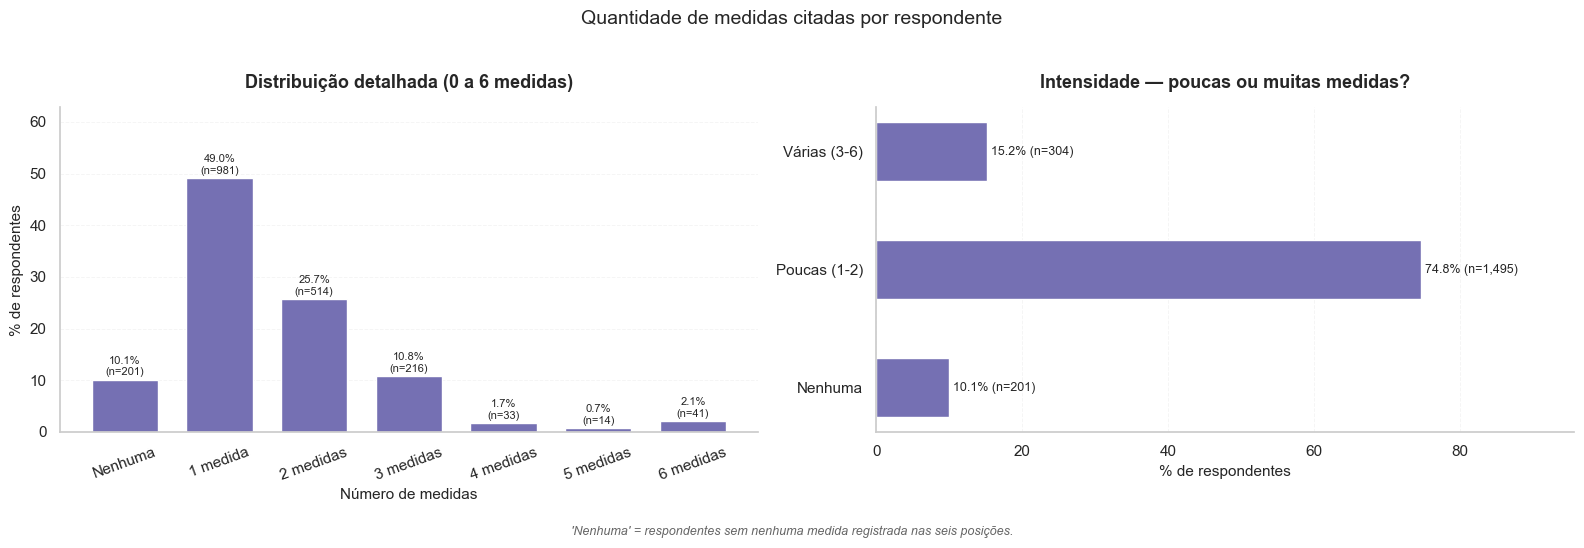


Tabela 2 — Distribuição de medidas por respondente (n=2,000)


,Respondentes,% de respondentes
Nenhuma,201,10.1%
1 medida,981,49.0%
2 medidas,514,25.7%
3 medidas,216,10.8%
4 medidas,33,1.7%
5 medidas,14,0.7%
6 medidas,41,2.1%


In [34]:
# === Gráfico 2: Quantidade de medidas citadas por respondente + Intensidade ===
COR_DIST = "#7570b3"

n_medidas = df_cesop[cols_p3].notna().sum(axis=1)
dist_n   = n_medidas.value_counts().sort_index()
dist_pct = dist_n / len(df_cesop) * 100

x_full_labels = {
    0: "Nenhuma", 1: "1 medida", 2: "2 medidas", 3: "3 medidas",
    4: "4 medidas", 5: "5 medidas", 6: "6 medidas",
}

# --- Agrupamento de intensidade ---
def _grupo_intens(n):
    if n == 0:  return "Nenhuma"
    if n <= 2:  return "Poucas (1-2)"
    return "Várias (3-6)"

grupos_intens = n_medidas.map(_grupo_intens).value_counts()
ordem_g = ["Nenhuma", "Poucas (1-2)", "Várias (3-6)"]
df_g = pd.DataFrame({"n": grupos_intens, "pct": grupos_intens / len(df_cesop) * 100})
df_g = df_g.reindex([g for g in ordem_g if g in df_g.index])

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Quantidade de medidas citadas por respondente", fontsize=14, y=1.02)

# --- Painel A: distribuição detalhada (barras verticais — eixo tem ordem natural 0-6) ---
bars_a = ax_a.bar(
    [x_full_labels.get(i, str(i)) for i in dist_pct.index],
    dist_pct.values,
    color=COR_DIST, width=0.7,
)
ax_a.set_title("Distribuição detalhada (0 a 6 medidas)", pad=14)
ax_a.set_xlabel("Número de medidas")
ax_a.set_ylabel("% de respondentes")
ax_a.set_ylim(0, dist_pct.max() * 1.28)
ax_a.grid(axis="x", visible=False)
ax_a.grid(axis="y", alpha=0.2, linestyle="--", linewidth=0.7)
ax_a.spines["top"].set_visible(False)
ax_a.spines["right"].set_visible(False)
ax_a.tick_params(axis="x", rotation=20)

for bar, pct, n in zip(bars_a, dist_pct.values, dist_n.values):
    ax_a.text(bar.get_x() + bar.get_width() / 2, pct + 0.5,
              f"{pct:.1f}%\n(n={int(n):,})", ha="center", va="bottom", fontsize=8)

# --- Painel B: intensidade (barras horizontais) ---
bars_b = ax_b.barh(df_g.index, df_g["pct"], color=COR_DIST, height=0.5)
ax_b.set_title("Intensidade — poucas ou muitas medidas?", pad=14)
ax_b.set_xlabel("% de respondentes")
ax_b.set_xlim(0, df_g["pct"].max() * 1.28)
ax_b.set_ylabel("")
ax_b.grid(axis="y", visible=False)
ax_b.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
ax_b.spines["top"].set_visible(False)
ax_b.spines["right"].set_visible(False)

for bar, pct, n in zip(bars_b, df_g["pct"], df_g["n"]):
    ax_b.text(pct + 0.5, bar.get_y() + bar.get_height() / 2,
              f"{pct:.1f}% (n={int(n):,})", va="center", fontsize=9)

fig.text(0.5, -0.03,
         "'Nenhuma' = respondentes sem nenhuma medida registrada nas seis posições.",
         ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout()
plt.savefig(PATH_FIGURAS / f"04_qtd_medidas_citadas_por_respondente.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nTabela 2 — Distribuição de medidas por respondente (n={len(df_cesop):,})")
tab_dist = pd.DataFrame({"n": dist_n, "pct": dist_pct})
tab_dist.index = [x_full_labels.get(i, str(i)) for i in tab_dist.index]
tab_dist.columns = ["Respondentes", "% de respondentes"]
tab_dist["% de respondentes"] = tab_dist["% de respondentes"].map("{:.1f}%".format)
display(tab_dist)

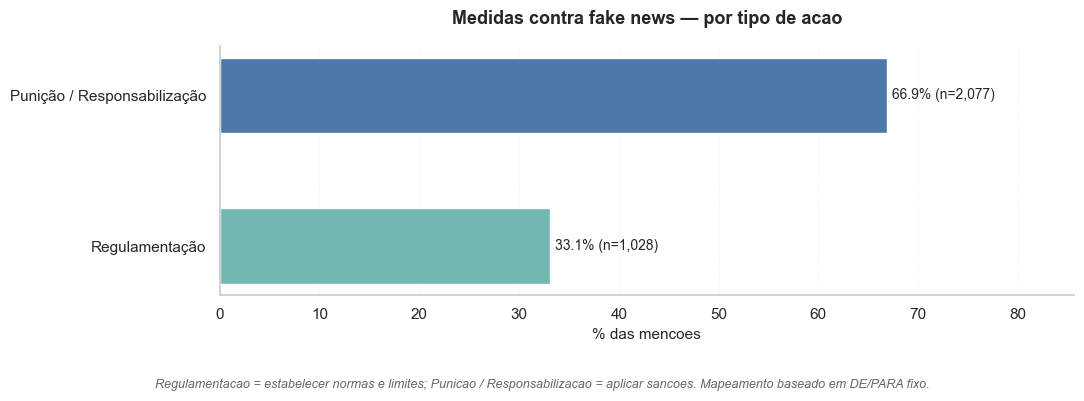

Tabela 3 — Mencoes por tipo de acao (total = 3,105)


,Mencoes,% das mencoes
Punição / Responsabilização,2077,66.9%
Regulamentação,1028,33.1%


In [35]:
# === Gráfico 3: Por tipo de acao ===
CORES_TIPO = {
    "Regulamentação":              "#72B7B2",
    "Punição / Responsabilização": "#4C78A8",
}

tipo_counts = todas_medidas_tipo.dropna().value_counts()
df_tipo = pd.DataFrame({"n": tipo_counts, "pct": tipo_counts / TOTAL_MENC_P3 * 100})
df_tipo = df_tipo.sort_values("pct")
cores_tipo = [CORES_TIPO.get(c, "#aaaaaa") for c in df_tipo.index]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(df_tipo.index, df_tipo["pct"], color=cores_tipo, height=0.5)

ax.set_title("Medidas contra fake news — por tipo de acao", pad=16)
ax.set_xlabel("% das mencoes")
ax.set_xlim(0, df_tipo["pct"].max() * 1.28)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, pct, n in zip(bars, df_tipo["pct"], df_tipo["n"]):
    ax.text(pct + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={int(n):,})", va="center", fontsize=10)

fig.text(0.5, 0.01,
         "Regulamentacao = estabelecer normas e limites; "
         "Punicao / Responsabilizacao = aplicar sancoes. "
         "Mapeamento baseado em DE/PARA fixo.",
         ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(PATH_FIGURAS / f"04_medidas_contra_fake_news_tipo_acao.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Tabela 3 — Mencoes por tipo de acao (total = {TOTAL_MENC_P3:,})")
tab_tipo = df_tipo[["n", "pct"]].sort_values("pct", ascending=False).copy()
tab_tipo.columns = ["Mencoes", "% das mencoes"]
tab_tipo["% das mencoes"] = tab_tipo["% das mencoes"].map("{:.1f}%".format)
display(tab_tipo)


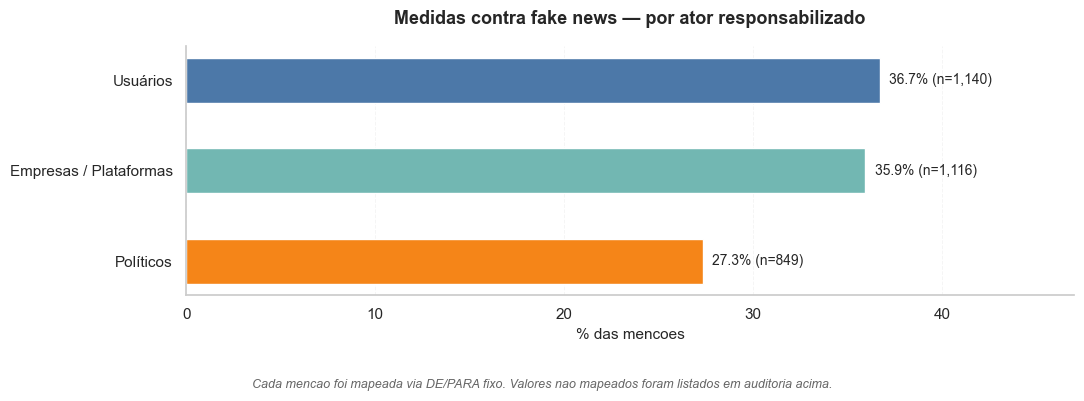

Tabela 4 — Mencoes por ator responsabilizado (total = 3,105)


,Mencoes,% das mencoes
Usuários,1140,36.7%
Empresas / Plataformas,1116,35.9%
Políticos,849,27.3%


In [36]:
# === Gráfico 4: Por ator responsabilizado ===
CORES_ATOR = {
    "Políticos":              "#F58518",
    "Empresas / Plataformas": "#72B7B2",
    "Usuários":               "#4C78A8",
}

ator_counts = todas_medidas_ator.dropna().value_counts()
df_ator = pd.DataFrame({"n": ator_counts, "pct": ator_counts / TOTAL_MENC_P3 * 100})
df_ator = df_ator.sort_values("pct")
cores_ator = [CORES_ATOR.get(c, "#aaaaaa") for c in df_ator.index]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(df_ator.index, df_ator["pct"], color=cores_ator, height=0.5)

ax.set_title("Medidas contra fake news — por ator responsabilizado", pad=16)
ax.set_xlabel("% das mencoes")
ax.set_xlim(0, df_ator["pct"].max() * 1.28)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, pct, n in zip(bars, df_ator["pct"], df_ator["n"]):
    ax.text(pct + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={int(n):,})", va="center", fontsize=10)

fig.text(0.5, 0.01,
         "Cada mencao foi mapeada via DE/PARA fixo. "
         "Valores nao mapeados foram listados em auditoria acima.",
         ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(PATH_FIGURAS / f"04_medidas_contra_fake_news_ator_responsabilizado.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Tabela 4 — Mencoes por ator responsabilizado (total = {TOTAL_MENC_P3:,})")
tab_ator = df_ator[["n", "pct"]].sort_values("pct", ascending=False).copy()
tab_ator.columns = ["Mencoes", "% das mencoes"]
tab_ator["% das mencoes"] = tab_ator["% das mencoes"].map("{:.1f}%".format)
display(tab_ator)


**O que as fake news revelam.** Entre as medidas citadas, **dois terços (66,9%) são de punição/responsabilização** e apenas 33,1% de regulamentação: predomina a preferência por **sancionar** em vez de **normatizar**. (Como a pergunta é de múltipla escolha, os percentuais referem-se ao **total de menções**, não de respondentes.) Vale notar o paralelo com o restante do estudo — uma inclinação por **respostas diretas/punitivas** em vez de soluções processuais.

## 5. Vontade de participar da vida política local

A pergunta P.04 investigou a disposição declarada dos respondentes para participar da vida política em sua cidade, com três níveis de intensidade: *Muita vontade*, *Alguma vontade* e *Nenhuma vontade*.

A análise é organizada em três partes:

1. **Distribuição geral** — qual é o nível predominante na amostra.
2. **Perfil demográfico** — variação por faixa etária, escolaridade, sexo e raça/cor.
3. **Perfil socioeconômico e territorial** — variação por renda e região.

A análise é descritiva — observa padrões na amostra sem inferir causalidade. Grupos com baixo n devem ser interpretados com cautela.

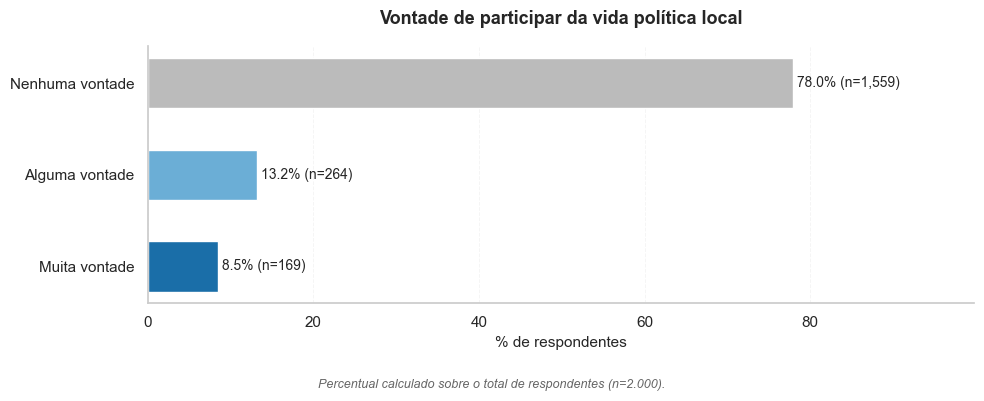


Tabela: Distribuição geral de vontade de participação política


,n,% de respondentes
P_04,,
Muita vontade,169,8.5%
Alguma vontade,264,13.2%
Nenhuma vontade,1559,78.0%


In [37]:
from IPython.display import display

# === Constantes e helpers compartilhados — seção 5 (Vontade de participar) ===

REGIAO_MAP_P4  = {"NORTE": "Norte", "NORDESTE": "Nordeste", "SUL": "Sul",
                   "SUDESTE": "Sudeste", "CENTRO OESTE": "Centro-Oeste"}
ORDEM_REGIAO_P4 = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
ORDEM_FX_P4     = ["16 E 17", "18 A 24", "25 A 34", "35 A 44", "45 A 54", "55 A 64", "65 E MAIS"]
ORDEM_ESCOL_P4  = ['Baixa escolaridade', 'Ensino fundamental', 'Ensino médio', 'Superior incompleto', 'Superior completo']
ORDEM_RENDA_P4  = ['Sem rendimento', 'Até 1 SM', '1 a 5 SM', 'Acima de 5 SM', 'Acima de 20 SM']

LIMIAR_P4 = 5.0  # segmentos < 5% não recebem rótulo interno


def _cor_p4(cat):
    """Paleta neutra e acadêmica para os três níveis de vontade."""
    c = str(cat).lower()
    if "muita" in c:   return "#1a6ea8"  # azul escuro
    if "alguma" in c:  return "#6baed6"  # azul claro
    if "nenhuma" in c: return "#bbbbbb"  # cinza médio
    return "#cccccc"


def _txt_p4(cat):
    c = str(cat).lower()
    return "#333333" if "nenhuma" in c else "white"


def _rotulos_p4(ax, colunas):
    """Rótulos inteiros no centro de cada segmento; omite segmentos < LIMIAR_P4."""
    for i, container in enumerate(ax.containers):
        cat = colunas[i]
        cor_txt = _txt_p4(cat)
        for bar in container:
            val = bar.get_width()
            if pd.isna(val) or val < LIMIAR_P4:
                continue
            x = bar.get_x() + val / 2
            y = bar.get_y() + bar.get_height() / 2
            ax.text(x, y, f"{int(round(val))}%", ha="center", va="center",
                    fontsize=9, color=cor_txt, fontweight="bold")


# Descobre valores e ordem (Muita → Alguma → Nenhuma) dinamicamente.
vals_p4   = df_cesop["P_04"].dropna().unique().tolist()
ordem_p4_s5 = sorted(vals_p4,
                      key=lambda v: {"muita": 0, "alguma": 1, "nenhuma": 2}
                      .get(str(v).lower().split()[0], 99))

contagem_p4 = df_cesop["P_04"].value_counts().reindex(ordem_p4_s5)
pct_p4_ser  = contagem_p4 / len(df_cesop) * 100
cores_p4    = [_cor_p4(c) for c in ordem_p4_s5]


# === Gráfico geral: barras horizontais ===
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(ordem_p4_s5, pct_p4_ser.values, color=cores_p4, height=0.55)

ax.set_title("Vontade de participar da vida política local", pad=16)
ax.set_xlabel("% de respondentes")
ax.set_xlim(0, pct_p4_ser.max() * 1.28)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, pct, n in zip(bars, pct_p4_ser.values, contagem_p4.values):
    ax.text(pct + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={int(n):,})", va="center", fontsize=10)

fig.text(0.5, 0.01,
         "Percentual calculado sobre o total de respondentes (n=2.000).",
         ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(PATH_FIGURAS / f"05_vontade_participar_politica.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nTabela: Distribuição geral de vontade de participação política")
tab_p4 = pd.DataFrame({
    "n": contagem_p4,
    "% de respondentes": pct_p4_ser.map("{:.1f}%".format),
})
display(tab_p4)

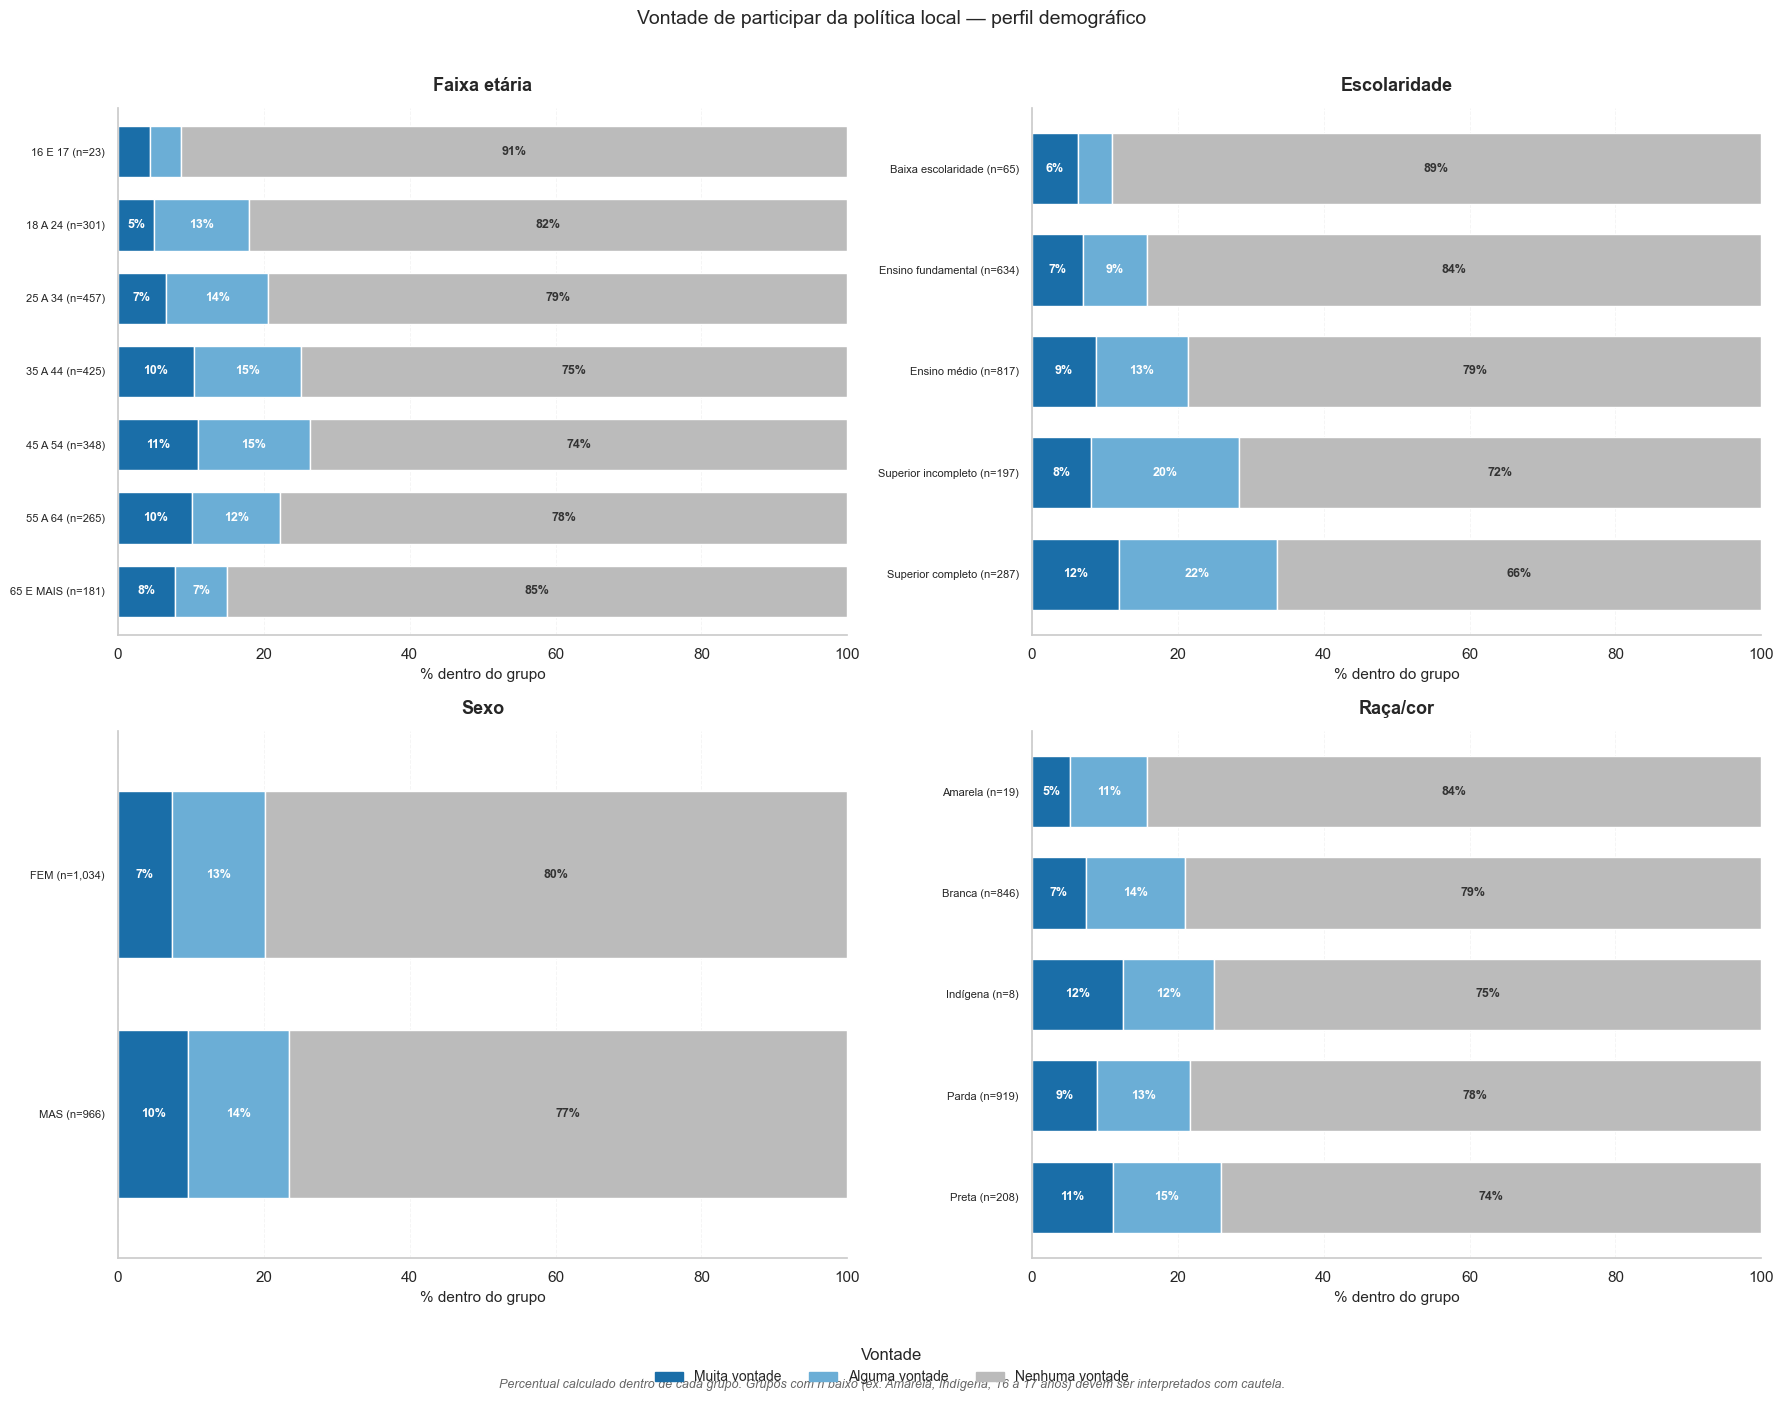

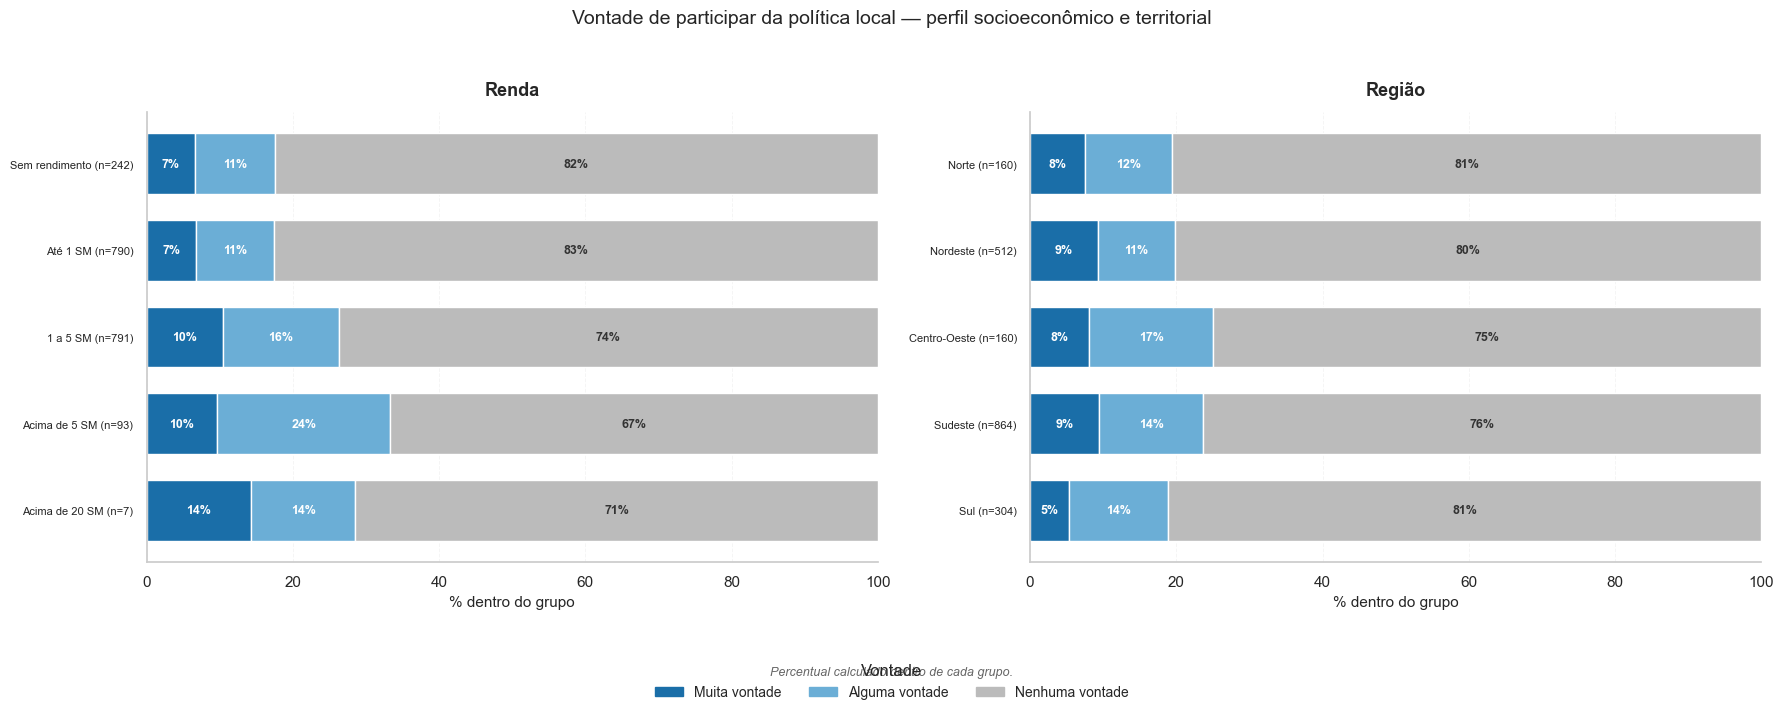

In [38]:
# === Cruzamentos: vontade de participar × perfil sociodemográfico ===
# df_p4w adiciona REGIAO_DISP com nomes em caixa mista para exibição.
df_p4w = df_cesop.assign(
    REGIAO_DISP = df_cesop["REGIAO"].map(REGIAO_MAP_P4).fillna(df_cesop["REGIAO"].astype(str))
)

# Detecta coluna de renda disponível.
col_renda = next((c for c in ["RENDA_PESSOAL", "RENDA_GRUPO"] if c in df_p4w.columns), None)


def _cross_p4(col, ax, title, ordem_col=None):
    """
    Barras horizontais 100% empilhadas de P_04 × col.
    Labels do eixo Y incluem n= de cada grupo.
    """
    ct = pd.crosstab(df_p4w[col], df_p4w["P_04"], normalize="index") * 100
    cols_used = [c for c in ordem_p4_s5 if c in ct.columns]
    ct = ct[cols_used]

    if ordem_col:
        ct = ct.reindex([c for c in ordem_col if c in ct.index])

    n_grp = df_p4w[col].value_counts()
    labels_y = [f"{cat} (n={int(n_grp.get(cat, 0)):,})" for cat in ct.index]
    cores_used = [_cor_p4(c) for c in cols_used]

    ct.plot.barh(stacked=True, ax=ax, color=cores_used, width=0.7, legend=False)
    ax.set_yticks(range(len(ct.index)))
    ax.set_yticklabels(labels_y, fontsize=8)
    ax.invert_yaxis()

    ax.set_title(title, pad=12)
    ax.set_xlabel("% dentro do grupo")
    ax.set_ylabel("")
    ax.set_xlim(0, 100)
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    _rotulos_p4(ax, cols_used)


# Handles de legenda compartilhada.
leg_handles = [plt.Rectangle((0, 0), 1, 1, color=_cor_p4(c)) for c in ordem_p4_s5]

# ── Painel 1: Perfil demográfico (2 × 2) ─────────────────────────────────────
fig1, axes1 = plt.subplots(2, 2, figsize=(18, 13))
fig1.suptitle("Vontade de participar da política local — perfil demográfico",
              fontsize=14, y=1.01)

_cross_p4("FX_ID",      axes1[0, 0], "Faixa etária",  ordem_col=ORDEM_FX_P4)
_cross_p4("ESCOL_GRUPO", axes1[0, 1], "Escolaridade",  ordem_col=ORDEM_ESCOL_P4)
_cross_p4("SEXO",        axes1[1, 0], "Sexo")
_cross_p4("RACA",        axes1[1, 1], "Raça/cor")

fig1.legend(leg_handles, ordem_p4_s5, title="Vontade", loc="upper center",
            bbox_to_anchor=(0.5, -0.01), ncol=len(ordem_p4_s5), frameon=False, fontsize=10)
fig1.text(0.5, -0.05,
          "Percentual calculado dentro de cada grupo. "
          "Grupos com n baixo (ex: Amarela, Indígena, 16 a 17 anos) devem ser interpretados com cautela.",
          ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout()
plt.savefig(PATH_FIGURAS / "05_vontade_demografico.png", dpi=120, bbox_inches="tight")
plt.show()


# ── Painel 2: Perfil socioeconômico e territorial (1 × 2) ────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 6))
fig2.suptitle("Vontade de participar da política local — perfil socioeconômico e territorial",
              fontsize=14, y=1.03)

if col_renda:
    _cross_p4(col_renda, axes2[0], "Renda", ordem_col=ORDEM_RENDA_P4)
else:
    axes2[0].text(0.5, 0.5, "Coluna de renda não encontrada", ha="center", va="center")

_cross_p4("REGIAO_DISP", axes2[1], "Região", ordem_col=ORDEM_REGIAO_P4)

fig2.legend(leg_handles, ordem_p4_s5, title="Vontade", loc="upper center",
            bbox_to_anchor=(0.5, -0.04), ncol=len(ordem_p4_s5), frameon=False, fontsize=10)
fig2.text(0.5, -0.08,
          "Percentual calculado dentro de cada grupo.",
          ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout()
plt.savefig(PATH_FIGURAS / "05_vontade_socioeconomico.png", dpi=120, bbox_inches="tight")
plt.show()

**O que a disposição revela.** O desengajamento é expressivo: **78,0% declaram nenhuma vontade** de participar da política local (n=1.559), contra 13,2% de *alguma* e apenas **8,5% de muita** vontade — disposição total de ~21,7%. O resultado ecoa a baixa prioridade dada à 'participação política' (seção 3) e antecipa o forte **gradiente por escolaridade** detalhado em 7.3.

## 6. Panorama eleitoral TSE 2022

Análise descritiva do TSE: ranking de comparecimento por UF, taxa por região e gradiente por idade, escolaridade e gênero. As taxas são calculadas como `QT_COMPARECIMENTO / QT_APTOS`.


In [39]:
# === VISAO GERAL DA BASE TSE 2022 ===
# Resumo das metricas principais para contextualizar a analise

total_aptos = df_tse_uf[df_tse_uf["SG_UF"] != "ZZ"]["QT_APTOS"].sum()
total_comparecimento = df_tse_uf[df_tse_uf["SG_UF"] != "ZZ"]["QT_COMPARECIMENTO"].sum()
total_abstencao = df_tse_uf[df_tse_uf["SG_UF"] != "ZZ"]["QT_ABSTENCAO"].sum()
taxa_nacional = (total_comparecimento / total_aptos) * 100
taxa_abstencao_nacional = (total_abstencao / total_aptos) * 100
num_ufs = df_tse_uf[df_tse_uf["SG_UF"] != "ZZ"]["SG_UF"].nunique()


resumo_data = {
    "Metrica": [
        "Eleitores aptos",
        "Comparecimento total",
        "Abstencao total",
        "Taxa de comparecimento",
        "Taxa de abstencao",
        "Unidades da Federacao",
    ],
    "Valor": [
        f"{total_aptos:,.0f}",
        f"{total_comparecimento:,.0f}",
        f"{total_abstencao:,.0f}",
        f"{taxa_nacional:.2f}%",
        f"{taxa_abstencao_nacional:.2f}%",
        f"{num_ufs}",
    ]
}

df_resumo = pd.DataFrame(resumo_data)
print("" + "="*70)
print("RESUMO GERAL — Base TSE 2022 (Brasil, sem Exterior)")
print("="*70)
display(df_resumo.to_string(index=False))
print("="*70 + "")


RESUMO GERAL — Base TSE 2022 (Brasil, sem Exterior)


'               Metrica       Valor\n       Eleitores aptos 311,513,866\n  Comparecimento total 247,332,217\n       Abstencao total  64,181,649\nTaxa de comparecimento      79.40%\n     Taxa de abstencao      20.60%\n Unidades da Federacao          27'

### Comparecimento e abstenção

Os gráficos a seguir descrevem o comparecimento eleitoral de 2022: o panorama nacional, a variação por região, por idade (com destaque para o voto facultativo) e por escolaridade.

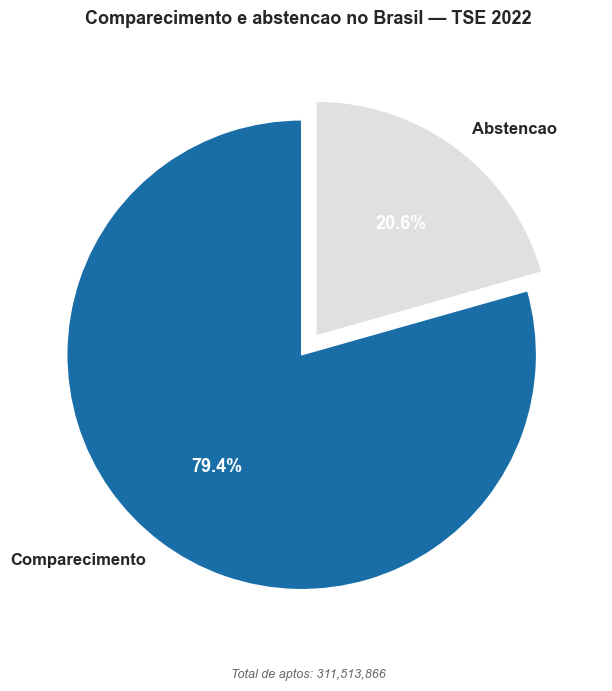

In [40]:
# === Comparecimento e abstencao no Brasil ===
# Pizza com rotulos percentuais dentro

df_br_total = df_tse_uf[df_tse_uf["SG_UF"] != "ZZ"][["QT_COMPARECIMENTO", "QT_ABSTENCAO"]].sum()
total_aptos = df_tse_uf[df_tse_uf["SG_UF"] != "ZZ"]["QT_APTOS"].sum()
comp_pct = (df_br_total["QT_COMPARECIMENTO"] / total_aptos) * 100
abst_pct = (df_br_total["QT_ABSTENCAO"] / total_aptos) * 100
fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie([comp_pct, abst_pct], labels=["Comparecimento", "Abstencao"],
                                    colors=["#1a6ea8", "#e0e0e0"], autopct="%1.1f%%",
                                    startangle=90, explode=(0.05, 0.05),
                                    textprops={"fontsize": 12, "weight": "bold"})
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(13)
    autotext.set_weight("bold")
ax.set_title("Comparecimento e abstencao no Brasil — TSE 2022", pad=20, fontsize=13, weight="bold")
fig.text(0.5, 0.02, f"Total de aptos: {total_aptos:,.0f}", ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(PATH_FIGURAS / "06_comparecimento_abstencao_Brasil.png", dpi=120, bbox_inches="tight")
plt.show()


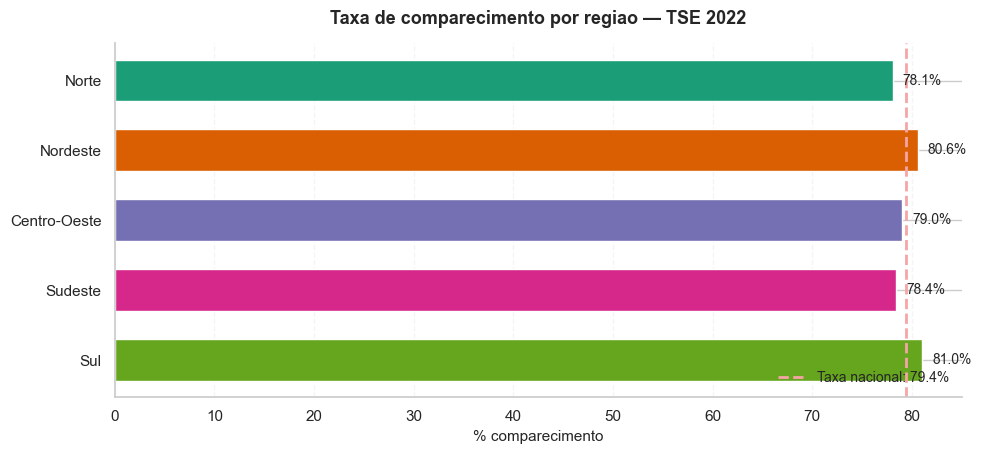

In [41]:
# === Taxa de comparecimento por regiao ===
# Barras com apenas %, linha taxa nacional, cores por regiao

ORDEM_REGIOES = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
CORES = {
    "Norte": "#1b9e77",
    "Nordeste": "#d95f02",
    "Centro-Oeste": "#7570b3",
    "Sudeste": "#d6278b",
    "Sul": "#66a61e",
}

df_reg = df_tse_uf[df_tse_uf["REGIAO"] != "Exterior"].copy()
df_r = df_reg.groupby("REGIAO").agg(QT_APTOS=("QT_APTOS", "sum"), QT_COMPARECIMENTO=("QT_COMPARECIMENTO", "sum")).reset_index()
df_r["TAXA"] = df_r["QT_COMPARECIMENTO"] / df_r["QT_APTOS"] * 100
df_r["REGIAO"] = pd.Categorical(df_r["REGIAO"], categories=ORDEM_REGIOES, ordered=True)
df_r = df_r.sort_values("REGIAO")
df_reg_tse = df_r.copy()  # Manter compatibilidade com seção 7

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_r["REGIAO"], df_r["TAXA"], color=[CORES[r] for r in df_r["REGIAO"]], height=0.6)

# Linha com taxa nacional
ax.axvline(comp_pct, color="#F5A5A5", linestyle="--", linewidth=2, label=f"Taxa nacional: {comp_pct:.1f}%")

ax.set_title("Taxa de comparecimento por regiao — TSE 2022", pad=14)
ax.set_xlabel("% comparecimento")
ax.set_ylabel("")
ax.set_xlim(0, 85)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.2, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="lower right", fontsize=10, frameon=False)

# Rotulos: APENAS porcentagem (sem n=)
for bar, pct in zip(bars, df_r["TAXA"]):
    ax.text(pct + 1, bar.get_y() + bar.get_height() / 2, f"{pct:.1f}%", va="center", fontsize=10)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(PATH_FIGURAS / "06_taxa_comparecimento_regiao.png", dpi=120, bbox_inches="tight")
plt.show()


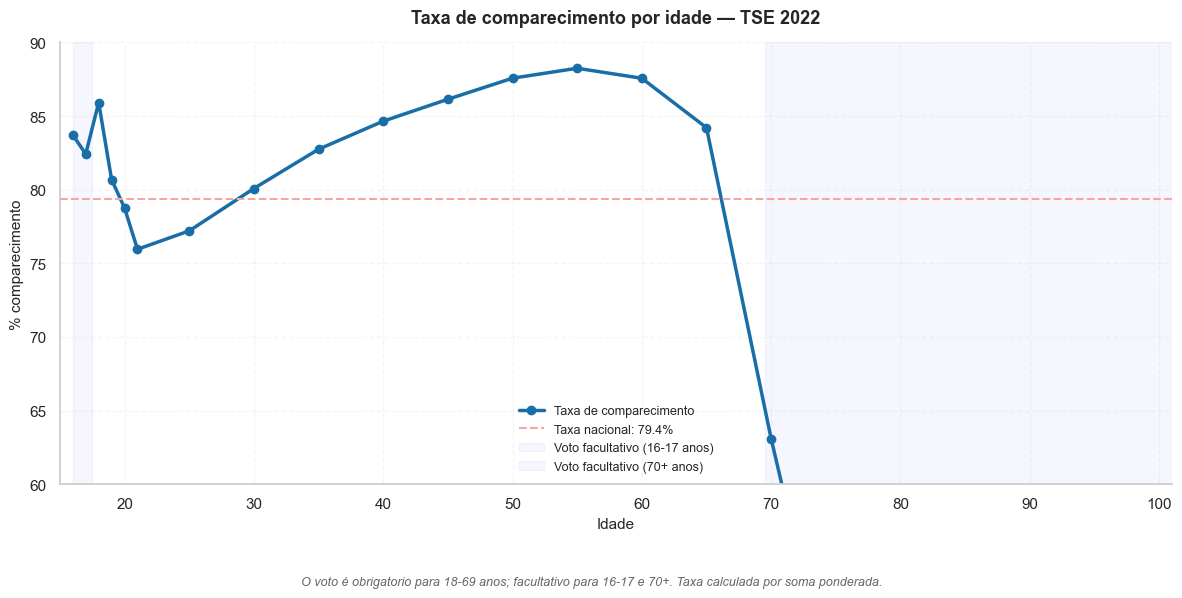

Tabela — Taxa de comparecimento por idade (selecionadas)


,Idade,Aptos,Comparecimento,Taxa %
0,16.0,"1,630,126","1,364,719",83.7%
1,17.0,"2,603,436","2,145,869",82.4%
2,18.0,"4,121,692","3,541,351",85.9%
3,30.0,"31,109,998","24,913,580",80.1%
4,50.0,"25,274,154","22,133,231",87.6%
5,60.0,"19,991,410","17,505,639",87.6%
6,70.0,"11,770,716","7,425,713",63.1%
7,80.0,"4,849,146","1,420,905",29.3%


In [42]:
# === Taxa de comparecimento por idade ===
# Linha com destaque para idades de voto facultativo (16-17 e 70+)

def _extract_age(s):
    m = re.search(r"(\d+)", str(s))
    return int(m.group(1)) if m else np.nan

df_tse_idade = (df_tse_perfil
    .assign(IDADE=lambda d: d["DS_FAIXA_ETARIA"].map(_extract_age))
    .dropna(subset=["IDADE"])
    .groupby("IDADE")
    .agg(QT_APTOS=("QT_APTOS", "sum"),
         QT_COMPARECIMENTO=("QT_COMPARECIMENTO", "sum"))
    .reset_index()
)
df_tse_idade["TAXA"] = df_tse_idade["QT_COMPARECIMENTO"] / df_tse_idade["QT_APTOS"] * 100
df_tse_idade = df_tse_idade.sort_values("IDADE")

# Taxa nacional ponderada
# taxa_nacional_idade = (df_tse_idade["QT_COMPARECIMENTO"].sum() / df_tse_idade["QT_APTOS"].sum()) * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_tse_idade["IDADE"], df_tse_idade["TAXA"], marker="o", linewidth=2.5,
        markersize=6, color="#1a6ea8", label="Taxa de comparecimento")

# Linha com taxa nacional
ax.axhline(comp_pct, color="#F5A5A5", linestyle="--", linewidth=1.5,
          label=f"Taxa nacional: {comp_pct:.1f}%")

# Destaque para idades de voto facultativo
ax.axvspan(16, 17.5, alpha=0.1, color="#a6a8fc06", label="Voto facultativo (16-17 anos)")
ax.axvspan(69.5, max(df_tse_idade["IDADE"]) + 1, alpha=0.1, color="#a6a8fc06", label="Voto facultativo (70+ anos)")

ax.set_title("Taxa de comparecimento por idade — TSE 2022", pad=14)
ax.set_xlabel("Idade")
ax.set_ylabel("% comparecimento")
ax.set_ylim(60, 90)
ax.set_xlim(15, max(df_tse_idade["IDADE"]) + 1)
ax.grid(True, alpha=0.2, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="best", fontsize=9, frameon=False)

fig.text(0.5, 0.01,
         "O voto é obrigatorio para 18-69 anos; facultativo para 16-17 e 70+. "
         "Taxa calculada por soma ponderada.",
         ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig(PATH_FIGURAS / "06_taxa_comparecimento_idade.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Tabela — Taxa de comparecimento por idade (selecionadas)")
tab_idade = df_tse_idade[["IDADE", "QT_APTOS", "QT_COMPARECIMENTO", "TAXA"]].copy()
tab_idade = tab_idade[tab_idade["IDADE"].isin([16, 17, 18, 30, 50, 60, 70, 80])]
tab_idade.columns = ["Idade", "Aptos", "Comparecimento", "Taxa %"]
tab_idade["Aptos"] = tab_idade["Aptos"].astype(int).apply(lambda x: f"{x:,}")
tab_idade["Comparecimento"] = tab_idade["Comparecimento"].astype(int).apply(lambda x: f"{x:,}")
tab_idade["Taxa %"] = tab_idade["Taxa %"].apply(lambda x: f"{x:.1f}%")
display(tab_idade.reset_index(drop=True))


C:\Users\edfeh\AppData\Local\Temp\ipykernel_29672\3501006006.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_e = df_tse_perfil.groupby("DS_GRAU_ESCOLARIDADE").agg(QT_APTOS=("QT_APTOS", "sum"), QT_COMPARECIMENTO=("QT_COMPARECIMENTO", "sum"))


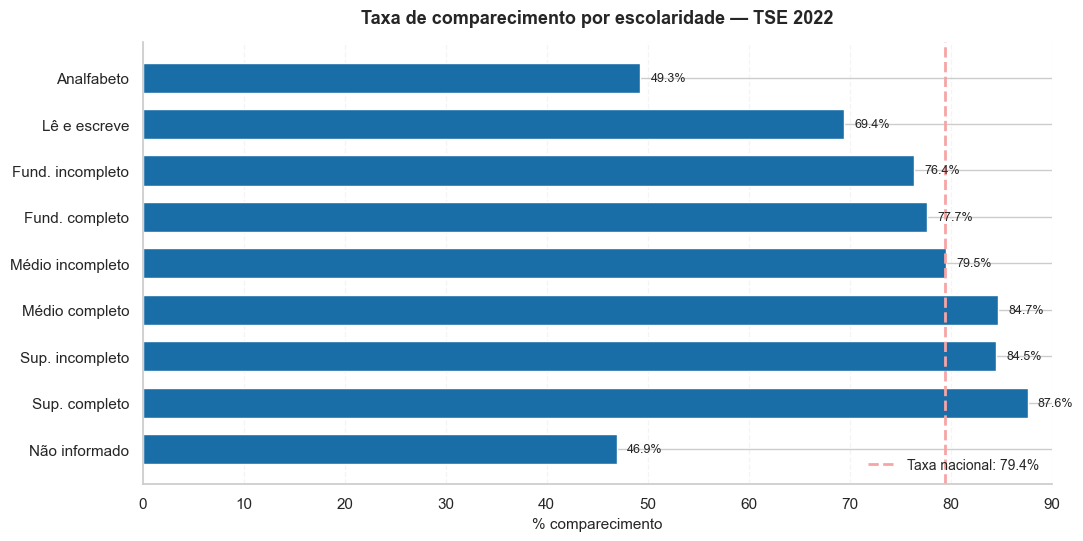

In [43]:
# === Taxa de comparecimento por escolaridade ===
# Ordem lógica de escolaridade
ordem = [
    "ANALFABETO",
    "LÊ E ESCREVE",
    "ENSINO FUNDAMENTAL INCOMPLETO",
    "ENSINO FUNDAMENTAL COMPLETO",
    "ENSINO MÉDIO INCOMPLETO",
    "ENSINO MÉDIO COMPLETO",
    "SUPERIOR INCOMPLETO",
    "SUPERIOR COMPLETO",
    "NÃO INFORMADO"
]

df_e = df_tse_perfil.groupby("DS_GRAU_ESCOLARIDADE").agg(QT_APTOS=("QT_APTOS", "sum"), QT_COMPARECIMENTO=("QT_COMPARECIMENTO", "sum"))
df_e["TAXA"] = df_e["QT_COMPARECIMENTO"] / df_e["QT_APTOS"] * 100
# Usar TODAS as categorias presentes no dataframe, mantendo ordem lógica
categorias_presentes = [e for e in ordem if e in df_e.index]
categorias_faltantes = [e for e in df_e.index if e not in ordem]
df_e = df_e.reindex(categorias_presentes + categorias_faltantes).reset_index()

labels = {
    "ANALFABETO": "Analfabeto",
    "LÊ E ESCREVE": "Lê e escreve",
    "ENSINO FUNDAMENTAL INCOMPLETO": "Fund. incompleto",
    "ENSINO FUNDAMENTAL COMPLETO": "Fund. completo",
    "ENSINO MÉDIO INCOMPLETO": "Médio incompleto",
    "ENSINO MÉDIO COMPLETO": "Médio completo",
    "SUPERIOR INCOMPLETO": "Sup. incompleto",
    "SUPERIOR COMPLETO": "Sup. completo",
    "NÃO INFORMADO": "Não informado"
}

# Para categorias não listadas, usar abreviação automática
df_e["LABEL"] = df_e["DS_GRAU_ESCOLARIDADE"].apply(lambda x: labels.get(x, x[:30]))
# taxa_nat_e = (df_e["QT_COMPARECIMENTO"].sum() / df_e["QT_APTOS"].sum()) * 100
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(df_e["LABEL"], df_e["TAXA"], color="#1a6ea8", height=0.65)
ax.axvline(comp_pct, color="#F5A5A5", linestyle="--", linewidth=2, label=f"Taxa nacional: {comp_pct:.1f}%")
ax.set_title("Taxa de comparecimento por escolaridade — TSE 2022", pad=14)
ax.set_xlabel("% comparecimento")
ax.set_xlim(0, 90)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.2, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="lower right", fontsize=10, frameon=False)
for bar, pct in zip(bars, df_e["TAXA"]):
    ax.text(pct + 1, bar.get_y() + bar.get_height() / 2, f"{pct:.1f}%", va="center", fontsize=9)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig(PATH_FIGURAS / "06_taxa_comparecimento_escolaridade.png", dpi=120, bbox_inches="tight")
plt.show()

### Distribuição do eleitorado

Complementarmente às taxas, observamos como os eleitores aptos se distribuem por idade — contexto importante para entender o peso de cada faixa no resultado.

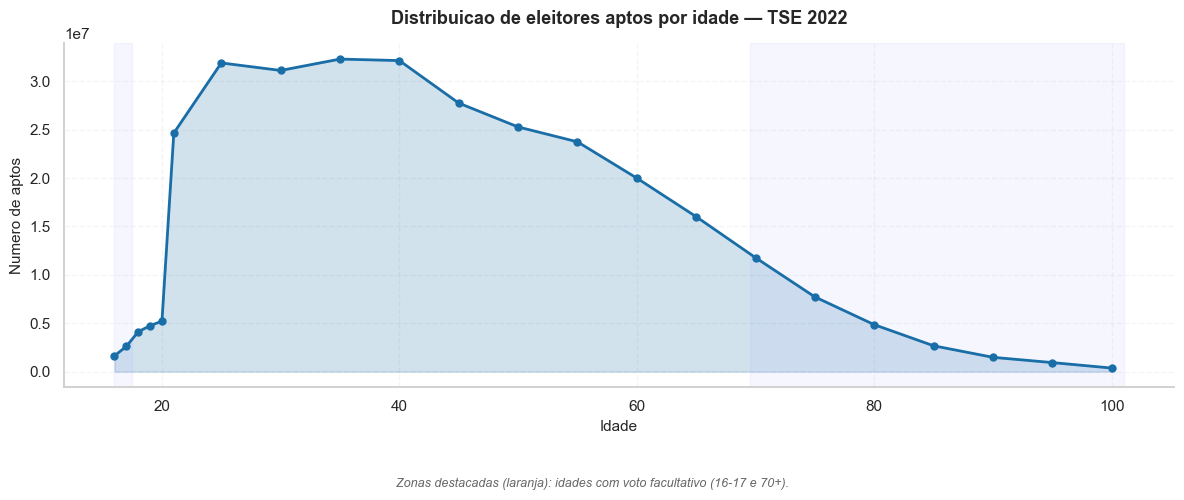

In [44]:
# === Distribuicao dos eleitores aptos por idade ===

def _extract_age(s):
    m = re.search(r"(\d+)", str(s))
    return int(m.group(1)) if m else np.nan

df_dist_idade = (df_tse_perfil
    .assign(IDADE=lambda d: d["DS_FAIXA_ETARIA"].map(_extract_age))
    .dropna(subset=["IDADE"])
    .groupby("IDADE")
    ["QT_APTOS"].sum()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_dist_idade.index, df_dist_idade.values, marker="o", linewidth=2, markersize=5, color="#1a6ea8", label="Aptos")
ax.fill_between(df_dist_idade.index, 0, df_dist_idade.values, alpha=0.2, color="#1a6ea8")

# Destaques para voto facultativo
ax.axvspan(16, 17.5, alpha=0.1, color="#a6a8fc06")
ax.axvspan(69.5, max(df_dist_idade.index) + 1, alpha=0.1, color="#a6a8fc06")

ax.set_title("Distribuicao de eleitores aptos por idade — TSE 2022", pad=14)
ax.set_xlabel("Idade")
ax.set_ylabel("Numero de aptos")
ax.grid(True, alpha=0.2, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(0.5, 0.01,
         "Zonas destacadas (laranja): idades com voto facultativo (16-17 e 70+).",
         ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(PATH_FIGURAS / "06_eleitores_aptos_idade.png", dpi=120, bbox_inches="tight")
plt.show()


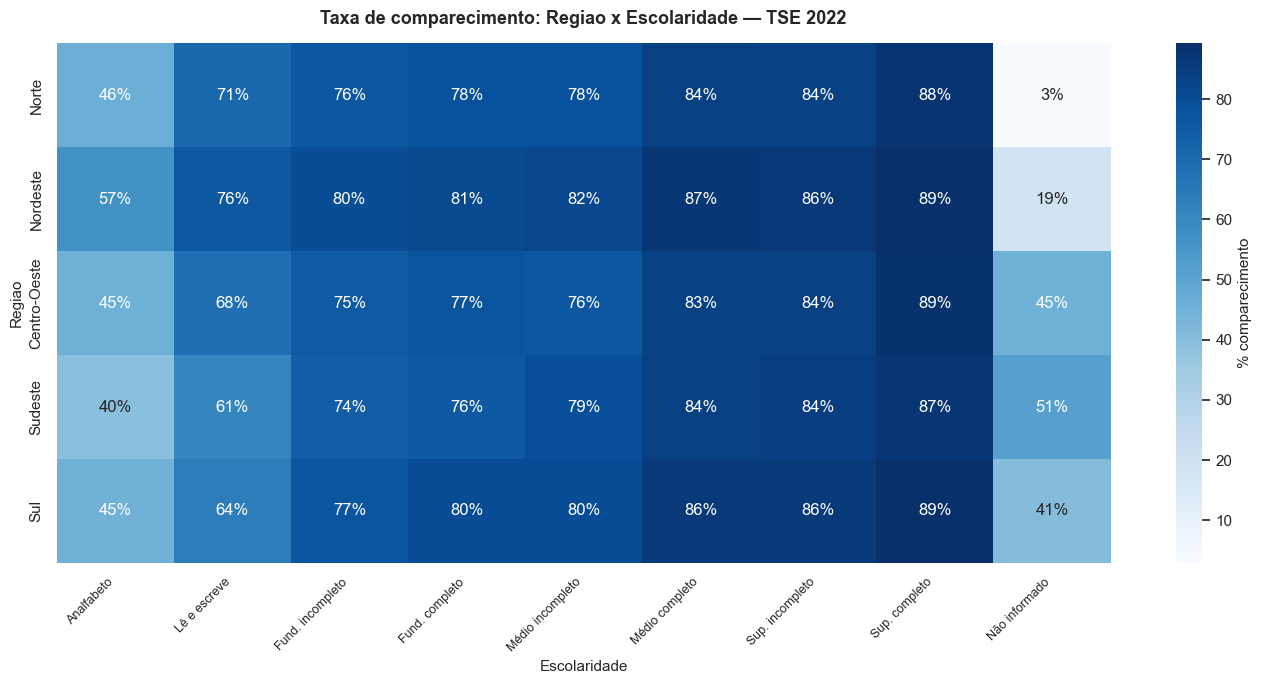

In [45]:
# === Heatmap: Taxa de comparecimento por regiao e escolaridade ===
# Usando df_tse (base completa com SG_UF) ao invés de df_tse_perfil

ORDEM_REGIOES = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
ordem_escol = [
    "ANALFABETO",
    "LÊ E ESCREVE",
    "ENSINO FUNDAMENTAL INCOMPLETO",
    "ENSINO FUNDAMENTAL COMPLETO",
    "ENSINO MÉDIO INCOMPLETO",
    "ENSINO MÉDIO COMPLETO",
    "SUPERIOR INCOMPLETO",
    "SUPERIOR COMPLETO",
    "NÃO INFORMADO"
]
# Carrega df_tse se ainda nao estiver em memoria
if "df_tse" not in dir():
    df_tse = pd.read_parquet(PATH_PROCESSED / "tse.parquet")

# Verifica se coluna necessaria existe
if "SG_UF" not in df_tse.columns or "DS_GRAU_ESCOLARIDADE" not in df_tse.columns:
    print("Aviso: colunas SG_UF ou escolaridade nao encontradas em df_tse. Pulando heatmap.")
else:
    # Mapeia UF para região
    UF_TO_REGIAO = {
        "AC": "Norte", "AM": "Norte", "AP": "Norte", "PA": "Norte", "RO": "Norte", "RR": "Norte", "TO": "Norte",
        "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste", "PB": "Nordeste", "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
        "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MS": "Centro-Oeste", "MT": "Centro-Oeste",
        "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
        "PR": "Sul", "RS": "Sul", "SC": "Sul",
    }
    
    df_tse_hm = df_tse[df_tse["SG_UF"] != "ZZ"].copy()
    df_tse_hm["REGIAO"] = df_tse_hm["SG_UF"].map(UF_TO_REGIAO)
    df_tse_hm = df_tse_hm.dropna(subset=["REGIAO"])
    
    # Crosstab agregado
    ct_re = pd.crosstab(
        df_tse_hm["REGIAO"],
        df_tse_hm["DS_GRAU_ESCOLARIDADE"],
        values=df_tse_hm["QT_COMPARECIMENTO"],
        aggfunc="sum"
    )
    ct_aptos_re = pd.crosstab(
        df_tse_hm["REGIAO"],
        df_tse_hm["DS_GRAU_ESCOLARIDADE"],
        values=df_tse_hm["QT_APTOS"],
        aggfunc="sum"
    )
    
    # Calcula taxa
    ct_taxa_re = (ct_re.fillna(0) / ct_aptos_re.fillna(1) * 100).fillna(0)
    
    # Reordena
    ct_taxa_re = ct_taxa_re.reindex([r for r in ORDEM_REGIOES if r in ct_taxa_re.index])
    ct_taxa_re = ct_taxa_re[[e for e in ordem_escol if e in ct_taxa_re.columns]]
    
    if ct_taxa_re.empty or (ct_taxa_re == 0).all().all():
        print("Heatmap vazio ou sem dados. Pulando.")
    else:
        # Abreviaturas
        label_abrev = {
            "ANALFABETO": "Analfabeto",
            "LÊ E ESCREVE": "Lê e escreve",
            "ENSINO FUNDAMENTAL INCOMPLETO": "Fund. incompleto",
            "ENSINO FUNDAMENTAL COMPLETO": "Fund. completo",
            "ENSINO MÉDIO INCOMPLETO": "Médio incompleto",
            "ENSINO MÉDIO COMPLETO": "Médio completo",
            "SUPERIOR INCOMPLETO": "Sup. incompleto",
            "SUPERIOR COMPLETO": "Sup. completo",
            "NÃO INFORMADO": "Não informado"
        }
        
        fig, ax = plt.subplots(figsize=(14, 7))
        annot = ct_taxa_re.round(0).astype(int).astype(str) + "%"
        sns.heatmap(ct_taxa_re, annot=annot, fmt="", cmap="Blues", ax=ax, cbar_kws={"label": "% comparecimento"})
        ax.set_xticklabels([label_abrev.get(c, c) for c in ct_taxa_re.columns], rotation=45, ha="right", fontsize=9)
        ax.set_title("Taxa de comparecimento: Regiao x Escolaridade — TSE 2022", pad=14)
        ax.set_ylabel("Regiao")
        ax.set_xlabel("Escolaridade")
        plt.tight_layout()
        plt.savefig(PATH_FIGURAS / "06_taxa_comparecimento_regiao_escolaridade.png", dpi=120, bbox_inches="tight")
        plt.show()


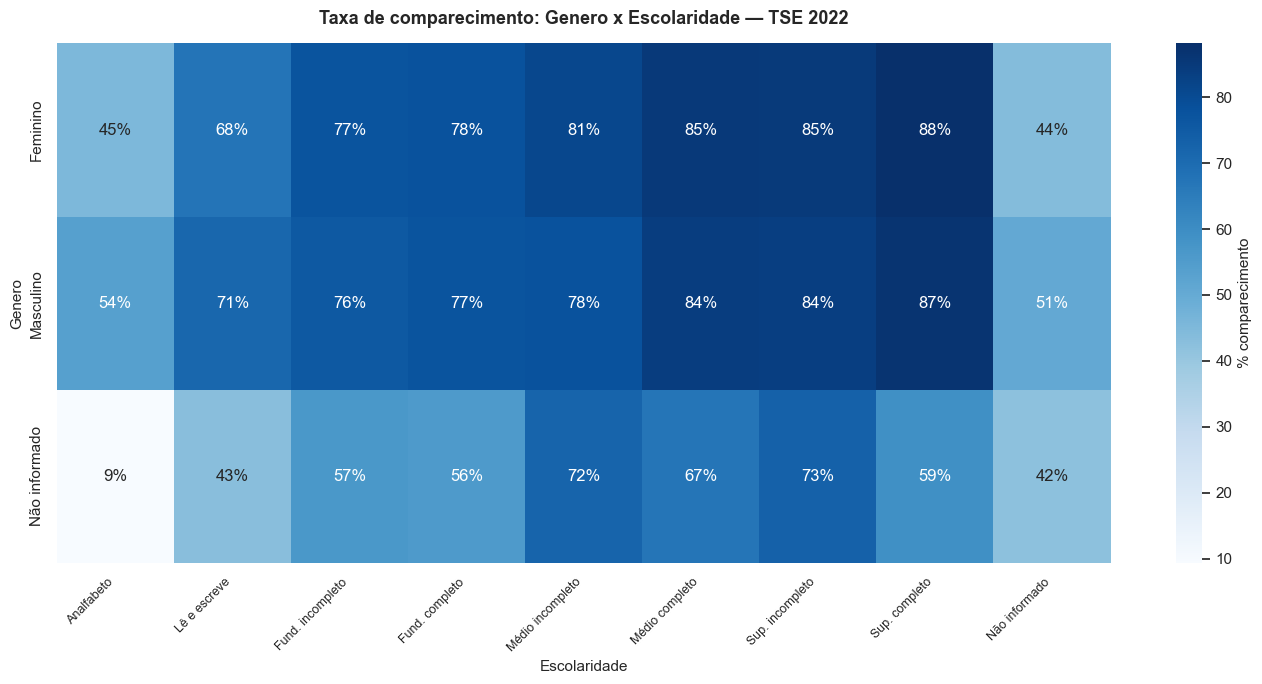

In [46]:
# === Heatmap: Taxa de comparecimento por genero e escolaridade ===

ordem_escol = [
    "ANALFABETO",
    "LÊ E ESCREVE",
    "ENSINO FUNDAMENTAL INCOMPLETO",
    "ENSINO FUNDAMENTAL COMPLETO",
    "ENSINO MÉDIO INCOMPLETO",
    "ENSINO MÉDIO COMPLETO",
    "SUPERIOR INCOMPLETO",
    "SUPERIOR COMPLETO",
    "NÃO INFORMADO"
]

df_tse_hm_ge = df_tse_perfil[df_tse_perfil["DS_GENERO"] != "NAO INFORMADO"].copy()

if df_tse_hm_ge.empty:
    print("Nao ha dados de genero informado em tse_perfil.")
else:
    ct_ge = pd.crosstab(
        df_tse_hm_ge["DS_GENERO"],
        df_tse_hm_ge["DS_GRAU_ESCOLARIDADE"],
        values=df_tse_hm_ge["QT_COMPARECIMENTO"],
        aggfunc="sum"
    )
    ct_aptos_ge = pd.crosstab(
        df_tse_hm_ge["DS_GENERO"],
        df_tse_hm_ge["DS_GRAU_ESCOLARIDADE"],
        values=df_tse_hm_ge["QT_APTOS"],
        aggfunc="sum"
    )
    
    ct_taxa_ge = (ct_ge.fillna(0) / ct_aptos_ge.fillna(1) * 100).fillna(0)
    ct_taxa_ge = ct_taxa_ge[[e for e in ordem_escol if e in ct_taxa_ge.columns]]
    ct_taxa_ge.index = [l.replace("FEMININO", "Feminino").replace("MASCULINO", "Masculino").replace("NÃO INFORMADO", "Não informado") for l in ct_taxa_ge.index]
    

    label_abrev = {
        "ANALFABETO": "Analfabeto",
        "LÊ E ESCREVE": "Lê e escreve",
        "ENSINO FUNDAMENTAL INCOMPLETO": "Fund. incompleto",
        "ENSINO FUNDAMENTAL COMPLETO": "Fund. completo",
        "ENSINO MÉDIO INCOMPLETO": "Médio incompleto",
        "ENSINO MÉDIO COMPLETO": "Médio completo",
        "SUPERIOR INCOMPLETO": "Sup. incompleto",
        "SUPERIOR COMPLETO": "Sup. completo",
        "NÃO INFORMADO": "Não informado"
    }
    
    fig, ax = plt.subplots(figsize=(14, 7))
    annot = ct_taxa_ge.round(0).astype(int).astype(str) + "%"
    sns.heatmap(ct_taxa_ge, annot=annot, fmt="", cmap="Blues", ax=ax, cbar_kws={"label": "% comparecimento"})
    ax.set_xticklabels([label_abrev.get(c, c) for c in ct_taxa_ge.columns], rotation=45, ha="right", fontsize=9)
    ax.set_title("Taxa de comparecimento: Genero x Escolaridade — TSE 2022", pad=14)
    ax.set_ylabel("Genero")
    ax.set_xlabel("Escolaridade")
    plt.tight_layout()
    plt.savefig(PATH_FIGURAS / "06_taxa_comparecimento_genero_escolaridade.png", dpi=120, bbox_inches="tight")
    plt.show()


**O que o panorama TSE revela.** O comparecimento nacional em 2022 foi de **79,40%** (abstenção 20,60%; 311,5 milhões de aptos). Há um **gradiente nítido por escolaridade** — de ~62% (baixa escolaridade) a ~87% (superior completo), **25 pontos** de diferença — e o efeito do **voto facultativo** nas pontas etárias: os 65+ comparecem ~57% e os jovens de 16–17 (facultativo) ~83%. Crucial: a variação por **escolaridade (~25 p.p.) é muito maior que por região (~3 p.p.)** — pista de que **escolaridade, não geografia**, é o que mais separa quem comparece.

## 7. Cruzamento CESOP × TSE

**Núcleo do projeto.** A base CESOP mede percepção e disposição declarada; o TSE mede comportamento eleitoral real. Aqui investigamos se essas duas dimensões andam juntas.

Antes de cruzar, precisamos harmonizar nomenclaturas (região, escolaridade, faixa etária) entre as duas bases.


In [47]:
# Funções de harmonização entre CESOP e TSE.
# As duas bases foram tratadas separadamente e usam convenções diferentes:
#   - REGIAO: CESOP 'NORDESTE' vs. TSE 'Nordeste'
#   - ESCOLARIDADE: CESOP em 5 grupos, TSE em 8 níveis
#   - FAIXA ETÁRIA: CESOP em faixas, TSE em idades individuais

REGIAO_CESOP_TO_TSE = {
    "NORTE": "Norte", "NORDESTE": "Nordeste",
    "SUDESTE": "Sudeste", "SUL": "Sul",
    "CENTRO OESTE": "Centro-Oeste",
}

ESCOL_TSE_TO_GRUPO = {
    "ANALFABETO": "Baixa escolaridade",
    "LÊ E ESCREVE": "Baixa escolaridade",
    "ENSINO FUNDAMENTAL INCOMPLETO": "Ensino fundamental",
    "ENSINO FUNDAMENTAL COMPLETO": "Ensino fundamental",
    "ENSINO MÉDIO INCOMPLETO": "Ensino médio",
    "ENSINO MÉDIO COMPLETO": "Ensino médio",
    "SUPERIOR INCOMPLETO": "Superior incompleto",
    "SUPERIOR COMPLETO": "Superior completo",
}

def _fx_id_from_age(idade):
    """Bucketiza idade individual nas mesmas faixas do CESOP."""
    if pd.isna(idade):
        return np.nan
    if idade <= 17: return "16 E 17"
    if idade <= 24: return "18 A 24"
    if idade <= 34: return "25 A 34"
    if idade <= 44: return "35 A 44"
    if idade <= 54: return "45 A 54"
    if idade <= 64: return "55 A 64"
    return "65 E MAIS"

# Aplica as harmonizações em uma cópia da base TSE por perfil.
df_tse_h = df_tse_perfil.copy()
df_tse_h["IDADE_NUM"] = df_tse_h["DS_FAIXA_ETARIA"].map(_extract_age)
df_tse_h["ESCOL_GRUPO"] = df_tse_h["DS_GRAU_ESCOLARIDADE"].map(ESCOL_TSE_TO_GRUPO)
df_tse_h["FX_ID_CESOP"] = df_tse_h["IDADE_NUM"].map(_fx_id_from_age)

print("Harmonização aplicada. Amostra:")
df_tse_h[["DS_FAIXA_ETARIA", "FX_ID_CESOP", "DS_GRAU_ESCOLARIDADE", "ESCOL_GRUPO"]].head()


Harmonização aplicada. Amostra:


,DS_FAIXA_ETARIA,FX_ID_CESOP,DS_GRAU_ESCOLARIDADE,ESCOL_GRUPO
0,100 anos ou mais,65 E MAIS,ANALFABETO,Baixa escolaridade
1,100 anos ou mais,65 E MAIS,ENSINO FUNDAMENTAL COMPLETO,Ensino fundamental
2,100 anos ou mais,65 E MAIS,ENSINO FUNDAMENTAL INCOMPLETO,Ensino fundamental
3,100 anos ou mais,65 E MAIS,ENSINO MÉDIO COMPLETO,Ensino médio
4,100 anos ou mais,65 E MAIS,ENSINO MÉDIO INCOMPLETO,Ensino médio


### 7.1 — Vontade declarada × comparecimento real, por região

Pergunta analítica: *regiões com menor vontade declarada de participar da política também apresentam menor comparecimento eleitoral?*


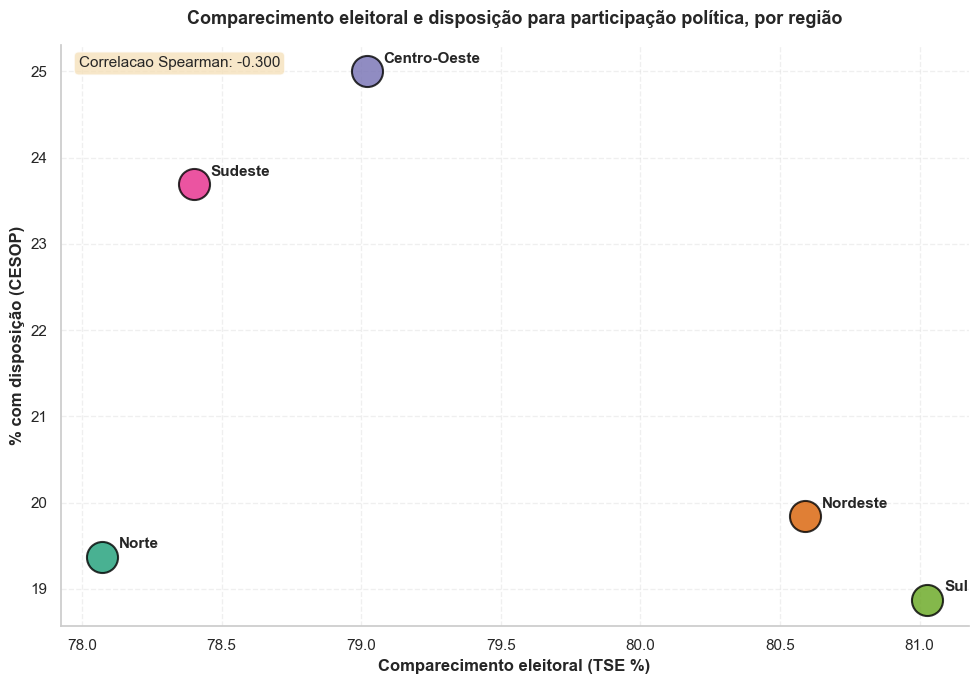

In [48]:
# % de respondentes com "alguma" ou "muita vontade" por regiao (CESOP).
ct_p4_reg = pd.crosstab(df_cesop["REGIAO"], df_cesop["P_04"], normalize="index") * 100
ct_p4_reg.index = ct_p4_reg.index.map(lambda x: REGIAO_CESOP_TO_TSE.get(str(x), str(x)))

# Identificar colunas
col_alguma = [c for c in ct_p4_reg.columns if "alguma" in str(c).lower()]
col_muita = [c for c in ct_p4_reg.columns if "muita" in str(c).lower()]
col_alguma = col_alguma[0] if col_alguma else None
col_muita = col_muita[0] if col_muita else None

# Calcular percentual
if col_alguma and col_muita:
    total_respondentes = pd.crosstab(df_cesop["REGIAO"], df_cesop["P_04"]).sum(axis=1)
    vontade_por_regiao = ((pd.crosstab(df_cesop["REGIAO"], df_cesop["P_04"])[col_alguma] + 
                           pd.crosstab(df_cesop["REGIAO"], df_cesop["P_04"])[col_muita]) / total_respondentes) * 100
    vontade_por_regiao.index = vontade_por_regiao.index.map(lambda x: REGIAO_CESOP_TO_TSE.get(str(x), str(x)))
else:
    vontade_por_regiao = ct_p4_reg.iloc[:, 0]

# Taxa de comparecimento TSE por regiao.
comparecimento_por_regiao = df_reg_tse.set_index("REGIAO")["TAXA"]

df_cruz = pd.DataFrame({
    "Comparecimento TSE": comparecimento_por_regiao,
    "Vontade (alguma ou muita %)": vontade_por_regiao,
}).dropna()

# Correlacao de Spearman
rho = df_cruz.corr(method="spearman").iloc[0, 1]

# Cores por regiao
cores_plot = {"Norte": "#1b9e77", "Nordeste": "#d95f02", "Centro-Oeste": "#7570b3", 
              "Sudeste": "#e7298a", "Sul": "#66a61e"}

# Plotar scatter: Eixo X = Comparecimento TSE, Eixo Y = Vontade CESOP
fig, ax = plt.subplots(figsize=(10, 7))
for regiao in df_cruz.index:
    comparecimento = df_cruz.loc[regiao, "Comparecimento TSE"]
    vontade = df_cruz.loc[regiao, "Vontade (alguma ou muita %)"]
    cor = cores_plot.get(regiao, "#999999")
    
    ax.scatter(comparecimento, vontade, s=500, color=cor, edgecolors="black", 
               linewidth=1.5, zorder=3, alpha=0.8, label=regiao)
    ax.annotate(regiao, (comparecimento, vontade), textcoords="offset points", 
                xytext=(12, 6), fontsize=11, fontweight="bold")

ax.set_xlabel("Comparecimento eleitoral (TSE %)", fontsize=12, fontweight="bold")
ax.set_ylabel("% com disposição (CESOP)", fontsize=12, fontweight="bold")

ax.set_title("Comparecimento eleitoral e disposição para participação política, por região", fontsize=13, fontweight="bold", pad=15)
ax.grid(True, alpha=0.3, linestyle="--")
ax.text(0.02, 0.98, f"Correlacao Spearman: {rho:.3f}", transform=ax.transAxes, fontsize=11,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7))

plt.tight_layout()
plt.savefig(PATH_FIGURAS / "07_cruz_vontade_comparecimento_regiao.png", dpi=120, bbox_inches="tight")
plt.show()

**Leitura do cruzamento 7.1.** Resultado **contra-intuitivo**: a correlação é **negativa (ρ de Spearman = −0,30)**. **Sul (81,0%)** e **Nordeste (80,6%)** têm o **maior comparecimento real**, mas a **menor disposição declarada** (18,9% e 19,8%); já **Centro-Oeste (25,0%)** e **Sudeste (23,7%)**, com comparecimento mediano, declaram **mais** disposição. Ou seja, **por região, percepção declarada e comportamento real não andam juntos — chegam a se opor**. Ressalva essencial: as bases **não medem os mesmos indivíduos**, então a comparação é *ecológica* (entre agregados regionais).

### 7.2 — A amostra CESOP é representativa do eleitorado?

Antes de cruzar percepção e comportamento, é prudente checar **o quanto a amostra CESOP se parece com o eleitorado real (TSE)** em escolaridade e faixa etária. *Pergunta:* a composição da amostra acompanha a do eleitorado, ou há sub/sobre-representação de algum grupo que exija cautela na leitura?

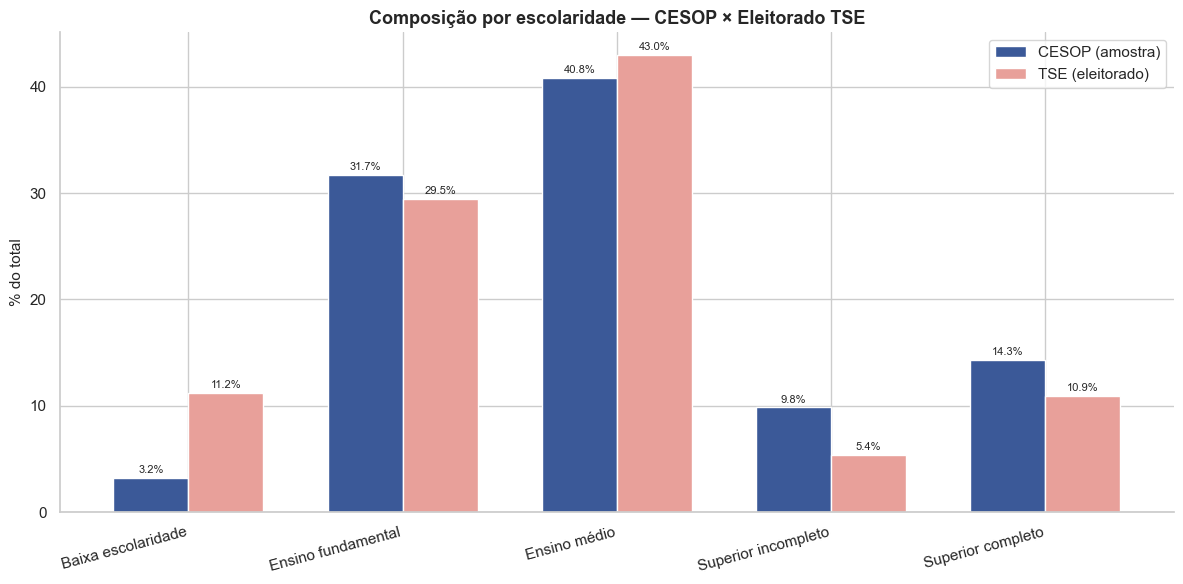

In [49]:
# Composição por escolaridade (5 grupos consolidados).
comp_cesop_e = df_cesop["ESCOL_GRUPO"].value_counts(normalize=True) * 100

tse_escol = (df_tse_h
    .dropna(subset=["ESCOL_GRUPO"])
    .groupby("ESCOL_GRUPO", observed=True)
    .agg(QT_APTOS=("QT_APTOS", "sum"))
)
tse_escol["pct"] = tse_escol["QT_APTOS"] / tse_escol["QT_APTOS"].sum() * 100
comp_tse_e = tse_escol["pct"]


ordem_e = ["Baixa escolaridade", "Ensino fundamental", "Ensino médio", "Superior incompleto", "Superior completo"]
df_comp_e = pd.DataFrame({"CESOP (amostra)": comp_cesop_e, "TSE (eleitorado)": comp_tse_e})
df_comp_e = df_comp_e.reindex(ordem_e).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
df_comp_e.plot.bar(ax=ax, color=[COR_PRINCIPAL, COR_SECUNDARIA], width=0.7)
ax.set_title("Composição por escolaridade — CESOP × Eleitorado TSE")
ax.set_ylabel("% do total")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
ax.set_xticklabels([t.get_text()[:25] for t in ax.get_xticklabels()], ha="right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=2, fontsize=8)
plt.tight_layout()
plt.savefig(PATH_FIGURAS / "07_composicao_escolaridade.png", dpi=120, bbox_inches="tight")
plt.show()


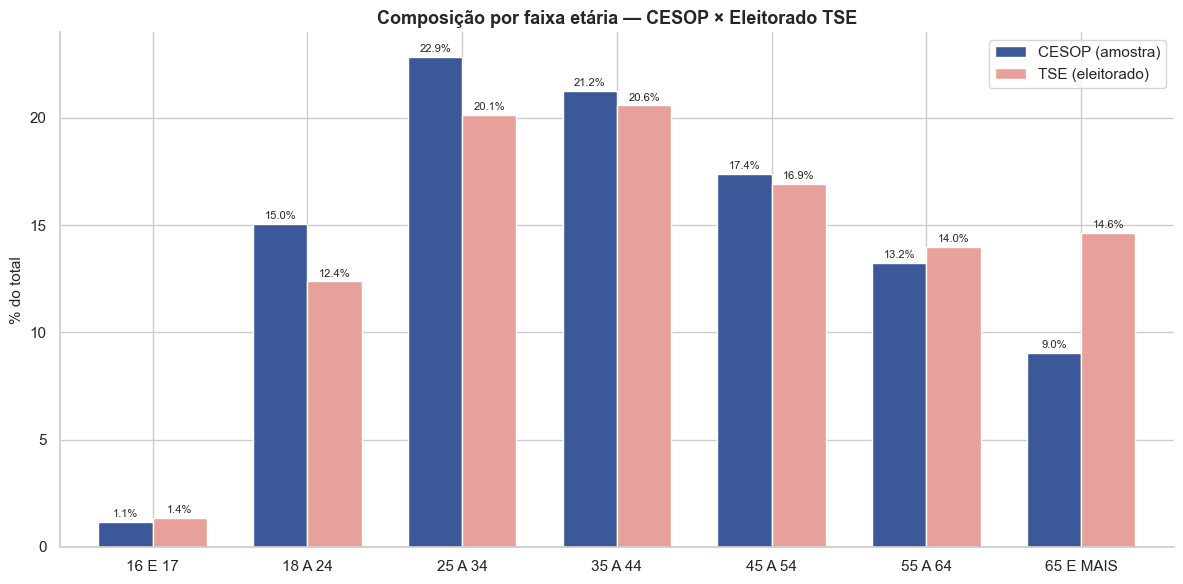

In [50]:
# Composição por faixa etária.
comp_cesop_fx = df_cesop["FX_ID"].value_counts(normalize=True) * 100

tse_fx = (df_tse_h
    .dropna(subset=["FX_ID_CESOP"])
    .groupby("FX_ID_CESOP", observed=True)
    .agg(QT_APTOS=("QT_APTOS", "sum"))
)
tse_fx["pct"] = tse_fx["QT_APTOS"] / tse_fx["QT_APTOS"].sum() * 100
comp_tse_fx = tse_fx["pct"]

ordem_fx = ["16 E 17", "18 A 24", "25 A 34", "35 A 44", "45 A 54", "55 A 64", "65 E MAIS"]
df_comp_fx = pd.DataFrame({"CESOP (amostra)": comp_cesop_fx, "TSE (eleitorado)": comp_tse_fx})
df_comp_fx = df_comp_fx.reindex(ordem_fx).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
df_comp_fx.plot.bar(ax=ax, color=[COR_PRINCIPAL, COR_SECUNDARIA], width=0.7)
ax.set_title("Composição por faixa etária — CESOP × Eleitorado TSE")
ax.set_ylabel("% do total")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=2, fontsize=8)
plt.tight_layout()
plt.savefig(PATH_FIGURAS / "07_composicao_faixa_etaria.png", dpi=120, bbox_inches="tight")
plt.show()


**Leitura da representatividade.** A amostra **acompanha** o eleitorado no ensino fundamental (31,7% vs 29,5%) e médio (40,8% vs 43,0%), mas **sub-representa a baixa escolaridade (3,2% vs 11,2%)** e **sobre-representa o ensino superior** (24,1% vs 16,3% somando incompleto e completo). Isso tem consequência direta: como a disposição cresce com a escolaridade (7.3), a amostra provavelmente **superestima** o engajamento — o desinteresse real da população tende a ser **ainda maior** que os 78% observados.

### 7.3 — Disposição declarada × comparecimento real, por escolaridade

*Pergunta analítica:* grupos de **maior escolaridade**, que tendem a comparecer mais às urnas, também declaram **maior disposição** para participar da política local? Cada ponto é um grupo de escolaridade; a correlação de Spearman resume a associação entre as duas dimensões.

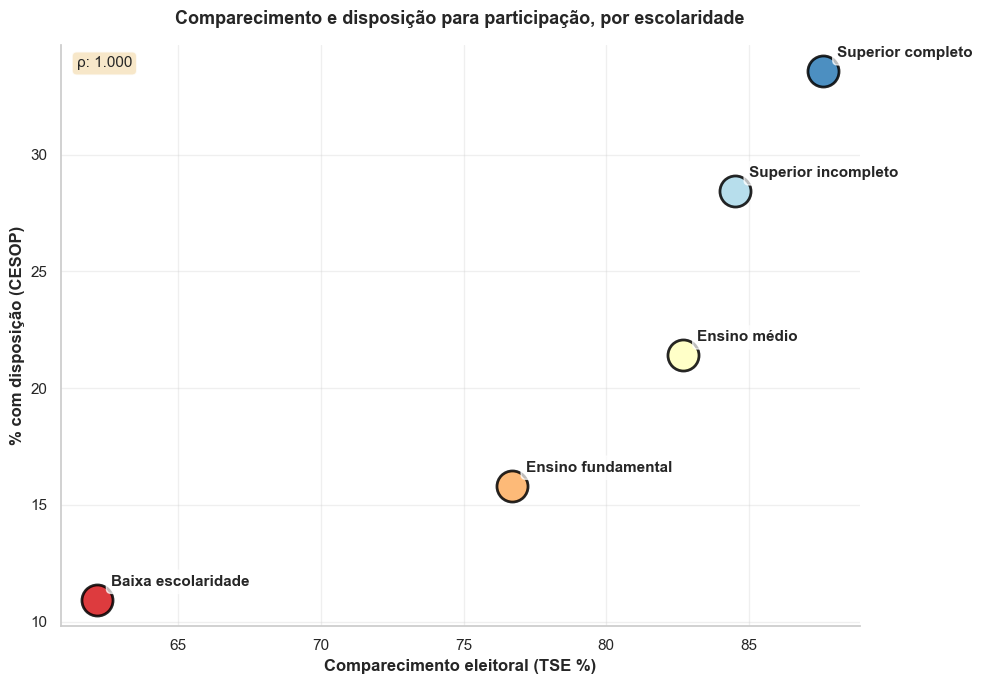

In [51]:
# TSE: comparecimento por escolaridade
tse_escol = (df_tse_h.dropna(subset=["ESCOL_GRUPO"])
    .groupby("ESCOL_GRUPO")
    .agg(QT_APTOS=("QT_APTOS", "sum"), QT_COMPARECIMENTO=("QT_COMPARECIMENTO", "sum")))
tse_escol["TAXA"] = tse_escol["QT_COMPARECIMENTO"] / tse_escol["QT_APTOS"] * 100

# CESOP: % com muita/alguma vontade por escolaridade
ct_escol = pd.crosstab(df_cesop["ESCOL_GRUPO"], df_cesop["P_04"])
col_alguma = [c for c in ct_escol.columns if "alguma" in str(c).lower()][0]
col_muita = [c for c in ct_escol.columns if "muita" in str(c).lower()][0]
cesop_escol_pct = ((ct_escol[col_alguma] + ct_escol[col_muita]) / ct_escol.sum(axis=1)) * 100

# Scatter
df_e = pd.DataFrame({"TSE": tse_escol["TAXA"], "CESOP": cesop_escol_pct}).dropna()
rho = df_e.corr(method="spearman").iloc[0, 1]
cores = {"Baixa escolaridade": "#d7191c", "Ensino fundamental": "#fdae61", "Ensino médio": "#ffffbf", "Superior incompleto": "#abd9e9", "Superior completo": "#2c7bb6"}

fig, ax = plt.subplots(figsize=(10, 7))
for esc in df_e.index:
    cor = cores.get(esc, "#999")
    ax.scatter(df_e.loc[esc, "TSE"], df_e.loc[esc, "CESOP"], s=500, color=cor, edgecolors="black", linewidth=2, zorder=3, alpha=0.85)
    ax.annotate(esc, (df_e.loc[esc, "TSE"], df_e.loc[esc, "CESOP"]), textcoords="offset points", xytext=(10, 10), fontsize=11, fontweight="bold", bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

ax.set_xlabel("Comparecimento eleitoral (TSE %)", fontsize=12, fontweight="bold")
ax.set_ylabel("% com disposição (CESOP)", fontsize=12, fontweight="bold")
ax.set_title("Comparecimento e disposição para participação, por escolaridade", fontsize=13, fontweight="bold", pad=15)
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.98, f"ρ: {rho:.3f}", transform=ax.transAxes, fontsize=11, verticalalignment="top", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7))
plt.tight_layout()
plt.savefig(PATH_FIGURAS / "07_cruz_vontade_comparecimento_escolaridade.png", dpi=120, bbox_inches="tight")
plt.show()

**Leitura do cruzamento 7.3.** Aqui a associação é **perfeita e positiva (ρ = 1,00)**: a cada degrau de escolaridade sobem **juntos** o comparecimento real (de ~62% na baixa escolaridade a ~87% no superior completo) e a disposição declarada (de ~11% a ~34%). Diferentemente da região (7.1), **na escolaridade percepção e comportamento são plenamente alinhados** — o achado central que aponta a **escolaridade como o eixo estruturante do engajamento político**, tanto declarado quanto efetivo.

### 7.4 — Comparecimento e disposição por faixa etária

*Pergunta analítica:* participação eleitoral (TSE) e disposição declarada (CESOP) seguem o **mesmo padrão ao longo da idade**? As duas curvas, em eixos distintos, permitem comparar o formato — especialmente nas idades de voto facultativo (16–17 e 65+).

C:\Users\edfeh\AppData\Local\Temp\ipykernel_29672\3882974543.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tse_fx = (df_tse_h.dropna(subset=["FX_ID_CESOP"]).groupby("FX_ID_CESOP", observed=True).apply(lambda x: (x["QT_COMPARECIMENTO"].sum() / x["QT_APTOS"].sum()) * 100))


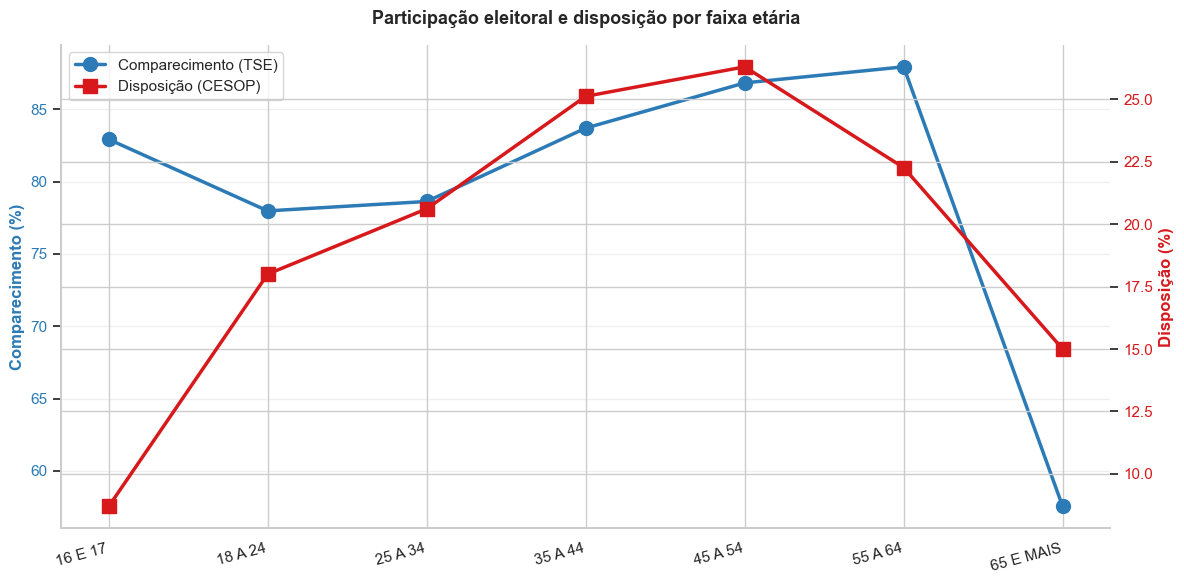

In [52]:
ordem_fx = ["16 E 17", "18 A 24", "25 A 34", "35 A 44", "45 A 54", "55 A 64", "65 E MAIS"]

# TSE
tse_fx = (df_tse_h.dropna(subset=["FX_ID_CESOP"]).groupby("FX_ID_CESOP", observed=True).apply(lambda x: (x["QT_COMPARECIMENTO"].sum() / x["QT_APTOS"].sum()) * 100))
tse_fx = tse_fx.reindex(ordem_fx)

# CESOP
ct_fx = pd.crosstab(df_cesop["FX_ID"], df_cesop["P_04"])
c_a = [c for c in ct_fx.columns if "alguma" in str(c).lower()][0]
c_m = [c for c in ct_fx.columns if "muita" in str(c).lower()][0]
cesop_fx = ((ct_fx[c_a] + ct_fx[c_m]) / ct_fx.sum(axis=1)) * 100
cesop_fx = cesop_fx.reindex(ordem_fx)

# Linhas duplas
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
x = np.arange(len(ordem_fx))

ax1.plot(x, tse_fx.values, marker="o", markersize=10, linewidth=2.5, color="#2c7bb6", label="Comparecimento (TSE)", zorder=3)
ax2.plot(x, cesop_fx.values, marker="s", markersize=10, linewidth=2.5, color="#d7191c", label="Disposição (CESOP)", zorder=3)

ax1.set_xticks(x)
ax1.set_xticklabels(ordem_fx, rotation=15, ha="right")
ax1.set_ylabel("Comparecimento (%)", fontsize=12, fontweight="bold", color="#2c7bb6")
ax2.set_ylabel("Disposição (%)", fontsize=12, fontweight="bold", color="#d7191c")
ax1.set_title("Participação eleitoral e disposição por faixa etária", fontsize=13, fontweight="bold", pad=15)
ax1.tick_params(axis="y", labelcolor="#2c7bb6")
ax2.tick_params(axis="y", labelcolor="#d7191c")
ax1.grid(True, alpha=0.3, axis="y")

lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, ["Comparecimento (TSE)", "Disposição (CESOP)"], loc="upper left", fontsize=11)
plt.tight_layout()
plt.savefig(PATH_FIGURAS / "07_cruz_vontade_comparecimento_faixa_etaria.png", dpi=120, bbox_inches="tight")
plt.show()

**Leitura do cruzamento 7.4.** No **miolo da vida (25–54 anos)** as duas curvas sobem **juntas**, com pico em 45–54. As divergências estão nas **pontas**: os jovens de **16–17 comparecem bastante (~83%) mas declaram disposição mínima (~9%)** — votam (voto facultativo) sem se interessar pela política local; já aos **65+ ambas caem**, com o comparecimento despencando para ~57%. O formato em sino é compartilhado, mas as extremidades revelam o descompasso entre **votar** e **querer participar**.

### 7.5 — Abstenção eleitoral × desinteresse por participação, por região

*Pergunta analítica:* regiões com **maior abstenção** eleitoral também concentram **maior desinteresse declarado** pela política local? É o espelho negativo do cruzamento 7.1.

C:\Users\edfeh\AppData\Local\Temp\ipykernel_29672\3314682288.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tse_abst = (df_tse_uf[df_tse_uf["REGIAO"] != "Exterior"]


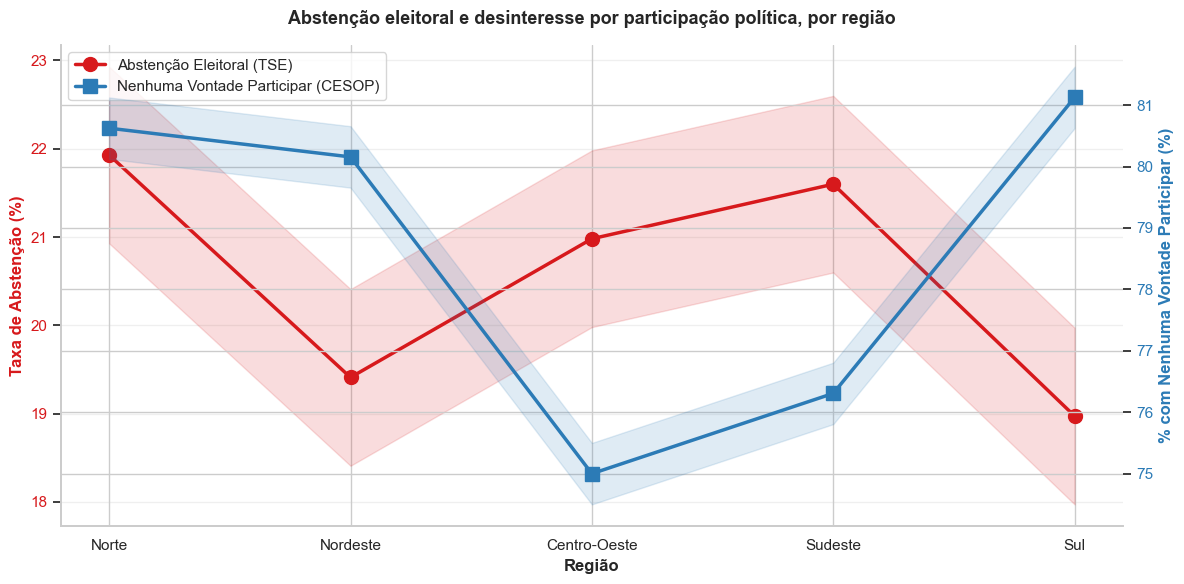

In [53]:
# Linhas duplas: abstenção (TSE) vs nenhuma vontade (CESOP) por região

ordem_reg = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]

# TSE: abstenção por região
tse_abst = (df_tse_uf[df_tse_uf["REGIAO"] != "Exterior"]
    .groupby("REGIAO")
    .apply(lambda x: (x["QT_ABSTENCAO"].sum() / x["QT_APTOS"].sum()) * 100))
tse_abst = tse_abst.reindex(ordem_reg)

# CESOP: nenhuma vontade por região
ct_reg = pd.crosstab(df_cesop["REGIAO"].map(lambda x: REGIAO_CESOP_TO_TSE.get(str(x), str(x))), df_cesop["P_04"])
col_nenhuma = [c for c in ct_reg.columns if "nenhuma" in str(c).lower()][0]
cesop_nenhuma = (ct_reg[col_nenhuma] / ct_reg.sum(axis=1)) * 100
cesop_nenhuma = cesop_nenhuma.reindex(ordem_reg)

# Plot linhas duplas
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

x_pos = np.arange(len(ordem_reg))

# TSE abstenção
line1 = ax1.plot(x_pos, tse_abst.values, marker="o", markersize=10, linewidth=2.5,
                 color="#d7191c", label="Abstenção Eleitoral (TSE)", zorder=3)
ax1.fill_between(x_pos, tse_abst.values - 1, tse_abst.values + 1, alpha=0.15, color="#d7191c")

# CESOP nenhuma vontade
line2 = ax2.plot(x_pos, cesop_nenhuma.values, marker="s", markersize=10, linewidth=2.5,
                 color="#2c7bb6", label="Nenhuma Vontade Participar (CESOP)", zorder=3)
ax2.fill_between(x_pos, cesop_nenhuma.values - 0.5, cesop_nenhuma.values + 0.5, alpha=0.15, color="#2c7bb6")

ax1.set_xticks(x_pos)
ax1.set_xticklabels(ordem_reg)
ax1.set_xlabel("Região", fontsize=12, fontweight="bold")
ax1.set_ylabel("Taxa de Abstenção (%)", fontsize=12, fontweight="bold", color="#d7191c")
ax2.set_ylabel("% com Nenhuma Vontade Participar (%)", fontsize=12, fontweight="bold", color="#2c7bb6")
ax1.set_title("Abstenção eleitoral e desinteresse por participação política, por região",
              fontsize=13, fontweight="bold", pad=15)

ax1.tick_params(axis="y", labelcolor="#d7191c")
ax2.tick_params(axis="y", labelcolor="#2c7bb6")
ax1.grid(True, alpha=0.3, axis="y")

# Legenda combinada
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", fontsize=11)

plt.tight_layout()
plt.savefig(PATH_FIGURAS / "07_cruz_abstencao_desinteresse_regiao.png", dpi=120, bbox_inches="tight")
plt.show()

**Leitura do cruzamento 7.5.** Confirma o padrão da 7.1 pelo lado negativo: o **Sul** tem a **menor abstenção (~19%)** mas o **maior desinteresse declarado (~81,5% de 'nenhuma vontade')**; o **Norte**, a maior abstenção (~21,9%). Não há paralelismo limpo entre abstenção e desinteresse — reforçando que, **regionalmente, comportamento e percepção se dissociam**.

### 7.6 — Comparecimento e percepção sobre fake news, por escolaridade

*Pergunta analítica:* o engajamento eleitoral se associa à **propensão a citar medidas** de combate à desinformação? Leitura exploratória e complementar.

C:\Users\edfeh\AppData\Local\Temp\ipykernel_29672\4290545967.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tse = (df_tse_h.dropna(subset=["ESCOL_GRUPO"]).groupby("ESCOL_GRUPO").apply(lambda x: (x["QT_COMPARECIMENTO"].sum() / x["QT_APTOS"].sum()) * 100))
C:\Users\edfeh\AppData\Local\Temp\ipykernel_29672\4290545967.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cesop_fn = (df_cesop.groupby("ESCOL_GRUPO")["FAKE_NEWS"].mean()) * 100


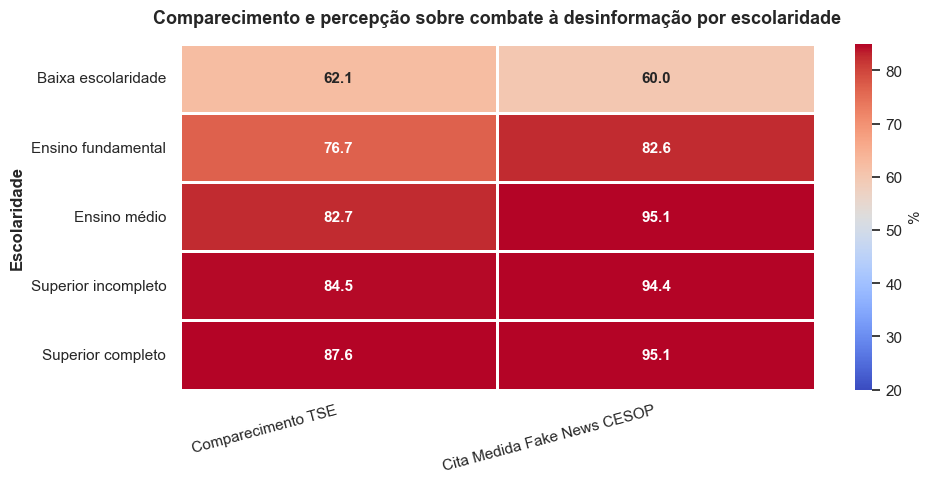

In [54]:
ordem = ["Baixa escolaridade", "Ensino fundamental", "Ensino médio", "Superior incompleto", "Superior completo"]

# TSE
tse = (df_tse_h.dropna(subset=["ESCOL_GRUPO"]).groupby("ESCOL_GRUPO").apply(lambda x: (x["QT_COMPARECIMENTO"].sum() / x["QT_APTOS"].sum()) * 100))

# CESOP fake news - colunas P03
p03_cols = [c for c in df_cesop.columns if c.startswith("P_03")]
df_cesop["FAKE_NEWS"] = df_cesop[p03_cols].apply(lambda x: x.notna().any(), axis=1)
cesop_fn = (df_cesop.groupby("ESCOL_GRUPO")["FAKE_NEWS"].mean()) * 100

# Matriz
matriz = pd.DataFrame({"Comparecimento TSE": tse.reindex(ordem), "Cita Medida Fake News CESOP": cesop_fn.reindex(ordem)}).dropna()
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(matriz, annot=True, fmt=".1f", cmap="coolwarm", vmin=20, vmax=85, cbar_kws={"label": "%"}, linewidths=1, ax=ax, annot_kws={"fontsize": 11, "fontweight": "bold"})
ax.set_title("Comparecimento e percepção sobre combate à desinformação por escolaridade", fontsize=13, fontweight="bold", pad=15)
ax.set_ylabel("Escolaridade", fontsize=12, fontweight="bold")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(PATH_FIGURAS / "07_cruz_comparecimento_fakenews_escolaridade.png", dpi=120, bbox_inches="tight")
plt.show()

**Leitura do cruzamento 7.6.** Indicador **exploratório**: como quase todos os respondentes citam alguma medida, a variância é baixa e o cruzamento é pouco discriminante. Ainda assim, vale reter da seção 4 que a ênfase recai sobre **punição (66,9%)** mais que regulamentação, e que o comparecimento, como em todo o estudo, cresce com a escolaridade.

---
## 8. Síntese e discussão dos resultados

Esta seção fecha o raciocínio, conectando os achados às perguntas do projeto. Todos os
valores abaixo vêm das análises deste notebook.

### Principais achados (com números)
- **Amostra (n=2.000).** 51,7% mulheres; concentrada em 25–44 anos; pardos (46,0%) e
  brancos (42,3%); ensino médio (40,8%) predominante e baixa escolaridade rara (3,2%).
- **Lembrança de voto.** Uniforme entre cargos: **~30% lembram** e **~65% não lembram** o
  voto legislativo de 2022 (estadual/federal/senador praticamente iguais).
- **Prioridades.** Saúde (20,0%), emprego (14,7%) e desigualdades (14,3%) lideram;
  **"ampliar participação política" é penúltima (2,0%)**.
- **Fake news.** **Punição/responsabilização domina (66,9%)** sobre regulamentação (33,1%).
- **Disposição para participar.** **78,0% "nenhuma vontade"**; apenas 8,5% "muita".
- **Comportamento real (TSE).** Comparecimento nacional **79,40%**; gradiente por
  escolaridade de **~62% a ~87%**; voto facultativo derruba as pontas (65+ ~57%).

### Padrões que emergem do cruzamento das análises
1. **Escolaridade é o eixo estruturante — e alinha percepção e comportamento.** No
   cruzamento por escolaridade (7.3) a associação é **perfeita (ρ = 1,00)**: mais
   escolaridade significa, ao mesmo tempo, mais comparecimento *e* mais disposição. A
   amplitude por escolaridade (~25 p.p. de comparecimento) supera de longe a regional
   (~3 p.p.). O mesmo eixo reaparece na lembrança de voto (maior entre escolarizados).
2. **A geografia, ao contrário, dissocia percepção e comportamento.** Por região, a
   correlação é **negativa (ρ = −0,30, seção 7.1)** e o espelho em 7.5 confirma: o **Sul**
   vota mais (abstenção ~19%) mas é o mais desinteressado (~81,5% "nenhuma vontade").
   Comparecer (dever cívico/obrigatório) não é o mesmo que querer participar.
3. **Desengajamento participativo convergente em três perguntas independentes.** 78% sem
   vontade de participar (P04), "ampliar participação" como penúltima prioridade (2%, P02)
   e ~65% sem lembrança do voto legislativo (P01) apontam, juntos, para um vínculo fraco
   com a política processual — o brasileiro quer **resultados** (saúde, emprego), não
   necessariamente **tomar parte**.
4. **O paradoxo dos jovens de 16–17.** Comparecem bastante (~83%) mas têm a menor
   disposição declarada (~9%): exercem o voto facultativo sem engajamento correspondente.

### Discussão e limitações
- **Comparação ecológica.** CESOP e TSE **não medem os mesmos indivíduos**; as associações
  são entre *agregados* e **não autorizam conclusões individuais** (falácia ecológica).
- **Correlação ≠ causalidade.** O ρ de Spearman descreve associação e direção, não causa.
- **Viés amostral pró-escolaridade.** A amostra sobre-representa os mais escolarizados
  (24,1% de superior vs 16,3% no eleitorado) e sub-representa a baixa escolaridade (3,2% vs
  11,2%). Como disposição cresce com escolaridade, **o engajamento real da população tende
  a ser ainda menor** que o observado — uma leitura conservadora dos 21,7% de disposição.

### Conclusão
Os dados sustentam uma tese clara: **escolaridade — e não região — é o que organiza o
engajamento político no Brasil**, sendo o único eixo em que **percepção declarada (CESOP) e
comportamento eleitoral real (TSE) se alinham** (ρ = 1,00). Geograficamente, as duas
dimensões chegam a se opor (ρ = −0,30), mostrando que **alto comparecimento não significa
alta disposição para participar** — caso emblemático do Sul. Soma-se a isso um quadro
consistente de **baixo engajamento participativo declarado**, visível em três perguntas
distintas. O trabalho cumpre o objetivo de **correlacionar uma pesquisa de opinião com uma
base pública** (TSE 2022), respeitando os limites da comparação ecológica.

> *Nota:* percentuais e coeficientes citados foram lidos das figuras geradas neste
> notebook; ao reexecutar, confirmam-se diretamente nas saídas das células.